In [1]:
# ============================================================
# 1. INPUTS AND COLUMN CONVENTIONS
# ============================================================
# Two feeds go into the score: the environmental sensor series and the
# merged SCADA + UPS alarm log produced by alarm_anomalies_fixed.ipynb.
import pandas as pd
import numpy as np
import re

ENV_FILE = "../data/temp_humid_last_synthetic.csv"
COMBINED_LOG_FILE = "../data/msc10_combined_ups_synthetic.csv"
OUTPUT_FILE = "../data/site_health_scores_synthetic.csv"

ENV_TIME_COL = "ts"
TEMP_COL = "temperature"
HUMIDITY_COL = "humidity"
LOG_TIME_COL = "log_time"
LOG_MESSAGE_COL = "message"
LOG_STATE_COL = "state"
CATEGORY_COL = "category"

df_env = pd.read_csv(ENV_FILE)
df_combined = pd.read_csv(COMBINED_LOG_FILE)

print("Environmental data:", df_env.shape)
print("Combined alarm and UPS data:", df_combined.shape)

# The two feeds do not cover the same period, which drives how the master index
# is built further down.
env_ts = pd.to_datetime(df_env[ENV_TIME_COL], errors="coerce")
log_ts = pd.to_datetime(df_combined[LOG_TIME_COL], errors="coerce")

print(f"Environmental range: {env_ts.min()} -> {env_ts.max()}")
print(f"Alarm / UPS range:   {log_ts.min()} -> {log_ts.max()}")

print("\nLog categories:")
print(df_combined[CATEGORY_COL].fillna("").str.strip().str.upper().value_counts())


Environmental data: (107060, 6)
Combined alarm and UPS data: (2569, 7)
Environmental range: 2025-11-02 15:27:34 -> 2026-05-18 19:19:56
Alarm / UPS range:   2026-02-10 10:34:06 -> 2026-05-10 10:30:38

Log categories:
category
UPS       2455
ENERGY      71
CLIM        43
Name: count, dtype: int64


In [2]:
# ============================================================
# 2. SCORING TOOLBOX
# The building blocks every subscore is assembled from. Each one exists
# to fix a specific flaw in the naive version of the same idea.
# ============================================================
def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")


def normalise_p95(series):
    values = safe_numeric(series).fillna(0).clip(lower=0)
    p95 = values.quantile(0.95)

    if pd.isna(p95) or p95 <= 0:
        return pd.Series(0.0, index=series.index)

    return (values / p95).clip(0, 1)


def saturating_ratio(series, scale=None):
    """Smoothly approach 1 as the series grows, instead of the hard clip
    normalise_p95 uses. A single event no longer snaps a term straight to
    its ceiling, and the term keeps easing upward instead of plateauing --
    this is what lets the risk scores degrade progressively.

    If `scale` isn't given, it's derived from the data itself (95th
    percentile), same as normalise_p95, so it still adapts to how busy this
    particular log is.
    """
    values = safe_numeric(series).fillna(0).clip(lower=0)

    if scale is None:
        scale = values.quantile(0.95)

    if pd.isna(scale) or scale <= 0:
        return pd.Series(0.0, index=series.index)

    return 1 - np.exp(-values / scale)


def decayed_sum(series, halflife_hours):
    """Recency-weighted running total. Each event raises the total
    immediately, then it fades smoothly with the given half-life instead of
    vanishing all at once when it falls out of a fixed-width rolling window.
    A rolling 24h sum holds an event's full weight for exactly 24 hours and
    then drops it -- a step function. This is the continuous equivalent.
    """
    decay = 0.5 ** (1 / halflife_hours)
    values = series.fillna(0).to_numpy(dtype=float)
    decayed = np.empty_like(values)
    running = 0.0

    for i, value in enumerate(values):
        running = running * decay + value
        decayed[i] = running

    return pd.Series(decayed, index=series.index)


def consecutive_run_length(binary_series):
    """Length of the current run of consecutive 1s, in rows, resetting to 0
    the moment a 0 appears. Measures how long a problem has been
    continuously active, as opposed to how often it fires.
    """
    reset_groups = (binary_series == 0).cumsum()
    return binary_series.groupby(reset_groups).cumsum()


def pm_risk_from_last_pm(datetime_index, last_pm_date, interval_days):
    """Preventive-maintenance risk: PM Risk = min(days since last PM /
    maintenance interval, 1). Grows linearly from 0 the moment `last_pm_date`
    passes, reaching 1 once `interval_days` have elapsed without another
    service, and holds there.

    `last_pm_date` is the last known maintenance date for that specific
    equipment group -- each subscore supplies its own.
    """
    days_since = (datetime_index - last_pm_date) / pd.Timedelta(days=1)
    days_since = np.clip(days_since, 0, None)

    return pd.Series(
        np.minimum(days_since / interval_days, 1.0),
        index=datetime_index
    )


def keyword_flag(series, keywords):
    # Word boundaries, so a short token like "ats" cannot match inside an
    # unrelated word. On the current log this selects exactly the same rows as
    # plain substring matching.
    pattern = "|".join(
        r"\b" + re.escape(keyword.lower()) + r"\b"
        for keyword in keywords
    )

    return (
        series
        .fillna("")
        .astype(str)
        .str.lower()
        .str.contains(pattern, regex=True, na=False)
        .astype(int)
    )


def active_weights(frame, weights, label):
    """Drop components with no signal, then renormalise the rest to sum to 1.

    A component whose keywords never match contributes 0 for every hour. Left
    in place its weight is dead: the base risk can never reach 100, so the site
    scores systematically healthier than it is.
    """
    active = {
        term: weight
        for term, weight in weights.items()
        if frame[term].max() > 0
    }

    dropped = sorted(set(weights) - set(active))

    if dropped:
        print(f"{label}: no signal in this log, weight redistributed -> {dropped}")

    if not active:
        raise ValueError(f"{label}: no component carries any signal.")

    total = sum(active.values())

    return {term: weight / total for term, weight in active.items()}


def weighted_risk(frame, weights):
    return 100 * sum(
        weight * frame[term]
        for term, weight in weights.items()
    )


def calculate_final_risk(
    base_risk,
    anomaly_burden,
    maintenance_risk,
    anomaly_weight,
    maintenance_weight
):
    anomaly_factor = 1 + anomaly_weight * anomaly_burden.clip(0, 1)
    maintenance_factor = 1 + maintenance_weight * maintenance_risk.clip(0, 1)

    return (
        base_risk
        * anomaly_factor
        * maintenance_factor
    ).clip(0, 100)


## Adjustable Scoring Weights

Central configuration for every base-risk term weight and the overall
subsystem weights. Defaults below match the values already used throughout
this notebook -- editing this dict (or using the interactive section further
down) is the only supported way to change them; the formula cells read from
here instead of hard-coded numbers.

Two things this refactor does **not** touch, per explicit scope:
- The anomaly/PM multipliers passed to `calculate_final_risk` (e.g. the 0.50
  anomaly weight, 0.30/0.35/0.50 maintenance weights per subsystem) stay
  fixed constants at their call sites.
- The energy calibration chain (soft compression + severe/persistent-outage
  floor) is unchanged and is reproduced as-is inside `recalculate_health_scores`
  below.


In [3]:
# ============================================================
# 3. WEIGHT CONFIGURATION AND THE THREE BASE-RISK FORMULAS
# Everything below reads its weights from WEIGHTS, so a weight is only
# ever changed in one place. validate_weights() enforces that each group
# still sums to 1 before any score is computed.
# ============================================================
WEIGHT_VERSION = "v1.0"

WEIGHTS = {
    "environmental": {
        "temperature": 0.40,
        "humidity": 0.25,
        "temperature_variability": 0.20,
        "humidity_variability": 0.15
    },
    "energy": {
        "outage": 0.35,
        "supply_instability": 0.20,
        "generator": 0.15,
        "backup_transfer": 0.15,
        "persistence": 0.15
    },
    "battery": {
        # 6 terms, not 5: persistence_component (how long an alarm has been
        # continuously active) was added after the original 5-term formula
        # and carries the largest weight -- raw alarm counts alone can't
        # tell a fault that clears immediately from one that won't clear.
        "check_battery": 0.20,
        "discharge": 0.20,
        "low_battery": 0.15,
        "chatter": 0.10,
        "recurrence": 0.10,
        "persistence": 0.25
    },
    "overall": {
        "environmental": 0.30,
        "energy": 0.35,
        "battery": 0.35
    }
}

# Maps each WEIGHTS key to the actual feature column already present in the
# corresponding *_hourly DataFrame. This is the single source of truth for
# "which column does this weight apply to" -- nothing downstream should
# hard-code these names again.
ENV_TERM_MAP = {
    "temperature": "temp_term",
    "humidity": "humidity_term",
    "temperature_variability": "temp_change_term",
    "humidity_variability": "humidity_change_term"
}

ENERGY_TERM_MAP = {
    "outage": "outage_term",
    "supply_instability": "supply_term",
    "generator": "generator_term",
    "backup_transfer": "transfer_term",
    "persistence": "persistence_term"
}

BATTERY_TERM_MAP = {
    "check_battery": "check_battery_component",
    "discharge": "discharge_component",
    "low_battery": "low_battery_component",
    "chatter": "chatter_component",
    "recurrence": "recurrence_component",
    "persistence": "persistence_component"
}

REQUIRED_WEIGHT_KEYS = {
    "environmental": set(ENV_TERM_MAP),
    "energy": set(ENERGY_TERM_MAP),
    "battery": set(BATTERY_TERM_MAP),
    "overall": {"environmental", "energy", "battery"}
}


def validate_weights(weights, tolerance=1e-6):
    """Validate a WEIGHTS-shaped configuration dict.

    Checks, per group: the group exists; every required key exists; every
    value is numeric, finite, and non-negative; and the group's weights sum
    to 1 within `tolerance`. Raises ValueError naming the offending group
    and its current total on any failure. Returns True on success.
    """
    for group, required_keys in REQUIRED_WEIGHT_KEYS.items():
        if group not in weights:
            raise ValueError(f"WEIGHTS is missing required group '{group}'.")

        group_weights = weights[group]
        missing_keys = required_keys - set(group_weights.keys())

        if missing_keys:
            raise ValueError(
                f"WEIGHTS['{group}'] is missing required keys: {sorted(missing_keys)}"
            )

        for key in required_keys:
            value = group_weights[key]

            if isinstance(value, bool) or not isinstance(value, (int, float)):
                raise ValueError(
                    f"WEIGHTS['{group}']['{key}'] must be numeric, "
                    f"got {type(value).__name__}."
                )

            if not np.isfinite(value):
                raise ValueError(
                    f"WEIGHTS['{group}']['{key}'] must be finite, got {value}."
                )

            if value < 0:
                raise ValueError(
                    f"WEIGHTS['{group}']['{key}'] must not be negative, got {value}."
                )

        total = sum(group_weights[key] for key in required_keys)

        if abs(total - 1.0) > tolerance:
            raise ValueError(
                f"WEIGHTS['{group}'] must sum to 1.0 (within {tolerance}); "
                f"current total is {total:.6f}."
            )

    return True


def calculate_environmental_base_risk(env_hourly, weights):
    """Weighted combination of environmental risk terms, scaled to 0-100.

    Reads temp_term, humidity_term, temp_change_term, humidity_change_term
    from `env_hourly` via ENV_TERM_MAP. Does not mutate `env_hourly`.
    Returns (base_risk_series, effective_weights_used) -- the latter is the
    weights actually applied after dropping any zero-signal term and
    renormalising the rest (see active_weights).
    """
    frame = env_hourly.copy()
    mapped_weights = {ENV_TERM_MAP[key]: value for key, value in weights.items()}
    effective_weights = active_weights(frame, mapped_weights, "environmental")
    base_risk = weighted_risk(frame, effective_weights).clip(0, 100)
    return base_risk, effective_weights


def calculate_energy_base_risk(energy_hourly, weights):
    """Weighted combination of energy risk terms, scaled to 0-100.

    Reads outage_term, supply_term, generator_term, transfer_term,
    persistence_term from `energy_hourly` via ENERGY_TERM_MAP. Does not
    mutate `energy_hourly`. Returns (base_risk_series, effective_weights_used).
    """
    frame = energy_hourly.copy()
    mapped_weights = {ENERGY_TERM_MAP[key]: value for key, value in weights.items()}
    effective_weights = active_weights(frame, mapped_weights, "energy")
    base_risk = weighted_risk(frame, effective_weights).clip(0, 100)
    return base_risk, effective_weights


def calculate_battery_base_risk(battery_hourly, weights):
    """Weighted combination of battery risk terms, scaled to 0-100.

    Reads check_battery_component, discharge_component, low_battery_component,
    chatter_component, recurrence_component, persistence_component from
    `battery_hourly` via BATTERY_TERM_MAP. Does not mutate `battery_hourly`.
    Returns (base_risk_series, effective_weights_used).
    """
    frame = battery_hourly.copy()
    mapped_weights = {BATTERY_TERM_MAP[key]: value for key, value in weights.items()}
    effective_weights = active_weights(frame, mapped_weights, "battery")
    base_risk = weighted_risk(frame, effective_weights).clip(0, 100)
    return base_risk, effective_weights


def calculate_overall_site_health(risk_scores, weights):
    """Combine subsystem risk scores into overall site risk/health.

    `risk_scores` is a dict with keys 'environmental', 'energy', 'battery'
    mapping to Series aligned on the same index. `weights` is
    WEIGHTS['overall']. Returns (overall_risk, overall_health,
    contributions) where contributions is a dict of the three weighted
    per-subsystem contributions (0-100 each, before summing).
    """
    contributions = {
        group: weights[group] * risk_scores[group]
        for group in ("environmental", "energy", "battery")
    }
    overall_risk = sum(contributions.values()).clip(0, 100)
    overall_health = 100 - overall_risk
    return overall_risk, overall_health, contributions


validate_weights(WEIGHTS)
print("WEIGHTS validated -- every group sums to 1.")


WEIGHTS validated -- every group sums to 1.


In [4]:
# ============================================================
# 4. ENVIRONMENTAL SUBSCORE
# ============================================================
# Clean the sensor feed: parse types, drop unusable timestamps, keep one
# reading per instant, and blank out physically impossible values
# (temperature outside -10..60 C, humidity outside 0..100 %) so they do
# not distort the averages instead of being silently trusted.
df_env[ENV_TIME_COL] = pd.to_datetime(
    df_env[ENV_TIME_COL],
    errors="coerce"
)

df_env[TEMP_COL] = safe_numeric(df_env[TEMP_COL])
df_env[HUMIDITY_COL] = safe_numeric(df_env[HUMIDITY_COL])

df_env = (
    df_env
    .dropna(subset=[ENV_TIME_COL])
    .sort_values(ENV_TIME_COL)
    .drop_duplicates(subset=[ENV_TIME_COL], keep="last")
)

df_env.loc[
    ~df_env[TEMP_COL].between(-10, 60),
    TEMP_COL
] = np.nan

df_env.loc[
    ~df_env[HUMIDITY_COL].between(0, 100),
    HUMIDITY_COL
] = np.nan

df_env = df_env.set_index(ENV_TIME_COL)

In [5]:
# Resample to hourly, the resolution of the whole pipeline.
# The hourly standard deviation is kept as its own feature: it measures
# how unstable the room was within the hour, not just how warm.
# Short holes are interpolated (max 3 hours); a missing std means
# 'no variation observed', hence fillna(0) rather than interpolation.
env_hourly = pd.DataFrame()

env_hourly["temperature"] = (
    df_env[TEMP_COL]
    .resample("1h")
    .mean()
)

env_hourly["humidity"] = (
    df_env[HUMIDITY_COL]
    .resample("1h")
    .mean()
)

env_hourly["temp_std_1h"] = (
    df_env[TEMP_COL]
    .resample("1h")
    .std()
)

env_hourly["humidity_std_1h"] = (
    df_env[HUMIDITY_COL]
    .resample("1h")
    .std()
)

env_hourly["observation_count"] = (
    df_env[TEMP_COL]
    .resample("1h")
    .count()
)

env_hourly[["temperature", "humidity"]] = (
    env_hourly[["temperature", "humidity"]]
    .interpolate(limit=3)
)

env_hourly[["temp_std_1h", "humidity_std_1h"]] = (
    env_hourly[["temp_std_1h", "humidity_std_1h"]]
    .fillna(0)
)

In [6]:
# Convert raw readings into 0-1 risk terms:
#  temp_term            0 below 26 C, rising to 1 at 36 C
#  humidity_term        distance from the 46 % target, with a +/-4 % dead
#                       band, saturating 15 points beyond it
#  *_change_term        instability, normalised against its own p95
# The weighted sum of the four is the environmental base risk.
required_columns = [
    "temperature",
    "humidity",
    "temp_std_1h",
    "humidity_std_1h"
]

missing_columns = [
    column
    for column in required_columns
    if column not in env_hourly.columns
]

if missing_columns:
    raise KeyError(f"Missing columns in env_hourly: {missing_columns}")

env_hourly["temp_term"] = (
   (env_hourly["temperature"] - 26) / 10
).clip(0, 1)

env_hourly["humidity_term"] = (
    ((env_hourly["humidity"] - 46).abs() - 4) / 15
).clip(0, 1)

env_hourly["temp_change_term"] = normalise_p95(
    env_hourly["temp_std_1h"]
)

env_hourly["humidity_change_term"] = normalise_p95(
    env_hourly["humidity_std_1h"]
)

env_hourly["environmental_base_risk"], _environmental_effective_weights = (
    calculate_environmental_base_risk(env_hourly, WEIGHTS["environmental"])
)

print(
    "Effective environmental weights:",
    {k: round(v, 4) for k, v in _environmental_effective_weights.items()}
)

print(env_hourly.columns.tolist())

display(
    env_hourly[
        [
            "temperature",
            "humidity",
            "temp_term",
            "humidity_term",
            "temp_change_term",
            "humidity_change_term",
            "environmental_base_risk"
        ]
    ].head()
)


Effective environmental weights: {'temp_term': 0.4, 'humidity_term': 0.25, 'temp_change_term': 0.2, 'humidity_change_term': 0.15}
['temperature', 'humidity', 'temp_std_1h', 'humidity_std_1h', 'observation_count', 'temp_term', 'humidity_term', 'temp_change_term', 'humidity_change_term', 'environmental_base_risk']


,temperature,humidity,temp_term,humidity_term,temp_change_term,humidity_change_term,environmental_base_risk
ts,,,,,,,
2025-11-02 15:00:00,24.190000,44.390000,0.0,0.0,0.060502,0.101975,2.739665
2025-11-02 16:00:00,24.300000,44.622222,0.0,0.0,0.092805,0.085262,3.135031
2025-11-02 17:00:00,24.360000,44.583333,0.0,0.0,0.095331,0.106317,3.501374
2025-11-02 18:00:00,24.438462,44.561538,0.0,0.0,0.124445,0.089438,3.830475
2025-11-02 19:00:00,24.520000,44.806667,0.0,0.0,0.136678,0.118192,4.506439


In [7]:
# From base risk to final environmental risk, in three steps:
#  1. anomaly burden - how far the last 24 h deviate from their own
#     rolling norm (z-score >= 3), combining how OFTEN it happened
#     (ratio) with how BADLY (severity)
#  2. PM risk - how overdue the cooling equipment is for servicing
#  3. final risk = base risk amplified by both, then health = 100 - risk
temp_mean_24h = (
    env_hourly["temperature"]
    .rolling(24, min_periods=6)
    .mean()
)

temp_std_24h = (
    env_hourly["temperature"]
    .rolling(24, min_periods=6)
    .std()
)

humidity_mean_24h = (
    env_hourly["humidity"]
    .rolling(24, min_periods=6)
    .mean()
)

humidity_std_24h = (
    env_hourly["humidity"]
    .rolling(24, min_periods=6)
    .std()
)

env_hourly["temp_zscore"] = (
    env_hourly["temperature"] - temp_mean_24h
) / temp_std_24h.replace(0, np.nan)

env_hourly["humidity_zscore"] = (
    env_hourly["humidity"] - humidity_mean_24h
) / humidity_std_24h.replace(0, np.nan)

env_hourly[["temp_zscore", "humidity_zscore"]] = (
    env_hourly[["temp_zscore", "humidity_zscore"]]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

env_hourly["environmental_anomaly_flag"] = (
    (env_hourly["temp_zscore"].abs() >= 3)
    | (env_hourly["humidity_zscore"].abs() >= 3)
).astype(int)

env_hourly["environmental_anomaly_ratio"] = (
    env_hourly["environmental_anomaly_flag"]
    .rolling(24, min_periods=1)
    .mean()
)

env_hourly["temp_anomaly_severity"] = (
    (env_hourly["temp_zscore"].abs() - 3) / 3
).clip(0, 1)

env_hourly["humidity_anomaly_severity"] = (
    (env_hourly["humidity_zscore"].abs() - 3) / 3
).clip(0, 1)

env_hourly["environmental_anomaly_severity"] = (
    env_hourly[
        [
            "temp_anomaly_severity",
            "humidity_anomaly_severity"
        ]
    ]
    .max(axis=1)
    .rolling(24, min_periods=1)
    .mean()
)

env_hourly["environmental_anomaly_burden"] = (
    0.60 * env_hourly["environmental_anomaly_ratio"]
    + 0.40 * env_hourly["environmental_anomaly_severity"]
).clip(0, 1)

# Cooling equipment: last preventive maintenance was 1 March 2026.
ENV_LAST_PM_DATE = pd.Timestamp("2026-03-01")
ENV_MAINTENANCE_INTERVAL_DAYS = 90

env_hourly["environmental_pm_risk"] = pm_risk_from_last_pm(
    env_hourly.index,
    ENV_LAST_PM_DATE,
    ENV_MAINTENANCE_INTERVAL_DAYS
)

env_hourly["environmental_risk_score"] = calculate_final_risk(
    env_hourly["environmental_base_risk"],
    env_hourly["environmental_anomaly_burden"],
    env_hourly["environmental_pm_risk"],
    0.50,
    0.30
)

env_hourly["environmental_health_score"] = (
    100 - env_hourly["environmental_risk_score"]
)

print(f"Environmental last PM: {ENV_LAST_PM_DATE}")


Environmental last PM: 2026-03-01 00:00:00


In [8]:
# ============================================================
# 5. ENERGY SUBSCORE
# ============================================================
# Normalise the alarm log before matching keywords against it: messages
# and states are cased and trimmed consistently, unusable timestamps are
# dropped, and exact duplicates removed.
df_combined[LOG_TIME_COL] = pd.to_datetime(
    df_combined[LOG_TIME_COL],
    errors="coerce"
)

df_combined[LOG_MESSAGE_COL] = (
    df_combined[LOG_MESSAGE_COL]
    .fillna("")
    .astype(str)
)

df_combined[LOG_STATE_COL] = (
    df_combined[LOG_STATE_COL]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.upper()
)

df_combined[CATEGORY_COL] = (
    df_combined[CATEGORY_COL]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.upper()
)

df_combined = (
    df_combined
    .dropna(subset=[LOG_TIME_COL])
    .sort_values(LOG_TIME_COL)
    .drop_duplicates()
    .reset_index(drop=True)
)

df_events = df_combined.copy()

In [9]:
# Classify each log line into an energy failure mode by keyword.
# The lists are deliberately bilingual (French/English) because the log
# mixes both. keyword_flag matches on word boundaries, not substrings.
OUTAGE_KEYWORDS = [
    "absence de tension",
    "absence tension",
    "power failure",
    "mains failure",
    "utility failure",
    "coupure",
    "perte secteur"
]

SUPPLY_KEYWORDS = [
    "rectifier",
    "redresseur",
    "bypass",
    "input voltage",
    "supply fault",
    "alimentation",
    "tension reseau",
    "tension réseau"
]

GENERATOR_KEYWORDS = [
    "generator",
    "groupe electrogene",
    "groupe électrogène",
    "genset",
    "diesel"
]

# Two keywords were removed here:
#   "switch"     matched 43 rows of "Salle Switch Temperature Haute", a room
#                temperature alarm, not a power transfer.
#   "on battery" (and its variants) matched 232 rows that DISCHARGE_KEYWORDS
#                already claims for the battery score. Counting them here too
#                charged the same event to both the energy and battery risk.
#                A discharge is battery evidence, so the battery score keeps it.
TRANSFER_KEYWORDS = [
    "transfer",
    "ats",
    "basculement",
    "backup supply",
    "secours"
]

df_events["is_outage"] = keyword_flag(
    df_events[LOG_MESSAGE_COL],
    OUTAGE_KEYWORDS
)

df_events["is_supply_event"] = keyword_flag(
    df_events[LOG_MESSAGE_COL],
    SUPPLY_KEYWORDS
)

df_events["is_generator_event"] = keyword_flag(
    df_events[LOG_MESSAGE_COL],
    GENERATOR_KEYWORDS
)

df_events["is_backup_transfer"] = keyword_flag(
    df_events[LOG_MESSAGE_COL],
    TRANSFER_KEYWORDS
)

print(
    df_events[
        [
            "is_outage",
            "is_supply_event",
            "is_generator_event",
            "is_backup_transfer"
        ]
    ].sum()
)

is_outage              37
is_supply_event       262
is_generator_event     34
is_backup_transfer      0
dtype: int64


In [10]:
# Aggregate the event flags to hourly counts, then convert each count
# into a recency-weighted load so a burst of alarms keeps weighing on the
# score after it stops firing, fading with an 8-hour half-life.
energy_events = (
    df_events[
        [
            LOG_TIME_COL,
            "is_outage",
            "is_supply_event",
            "is_generator_event",
            "is_backup_transfer"
        ]
    ]
    .set_index(LOG_TIME_COL)
)

energy_hourly = (
    energy_events
    .resample("1h")
    .sum()
)

energy_hourly = energy_hourly.rename(
    columns={
        "is_outage": "outage_count",
        "is_supply_event": "supply_event_count",
        "is_generator_event": "generator_event_count",
        "is_backup_transfer": "backup_transfer_count"
    }
)

# Recency-weighted load per event type: an event raises the load immediately
# and it decays smoothly afterwards, instead of holding a flat plateau for
# exactly 24 hours and then dropping off a cliff.
ENERGY_HALFLIFE_HOURS = 8

energy_hourly["outage_load"] = decayed_sum(
    energy_hourly["outage_count"], ENERGY_HALFLIFE_HOURS
)

energy_hourly["supply_load"] = decayed_sum(
    energy_hourly["supply_event_count"], ENERGY_HALFLIFE_HOURS
)

energy_hourly["generator_load"] = decayed_sum(
    energy_hourly["generator_event_count"], ENERGY_HALFLIFE_HOURS
)

energy_hourly["transfer_load"] = decayed_sum(
    energy_hourly["backup_transfer_count"], ENERGY_HALFLIFE_HOURS
)

energy_hourly["outage_active_hour"] = (
    energy_hourly["outage_count"] > 0
).astype(int)

# True duration: how many consecutive hours the site has been in an active
# outage right now, not how many outage alarms fired somewhere in the last day.
energy_hourly["outage_duration_hours"] = consecutive_run_length(
    energy_hourly["outage_active_hour"]
)

In [11]:
# Energy risk terms and final energy risk.
# saturating_ratio maps each load onto 0-1 without a hard ceiling, so a
# very bad hour still scores worse than a merely bad one.
# The anomaly burden combines three views of the same problem: how many
# events (frequency), how long (duration), how many types at once
# (sequence).
ENERGY_DURATION_SCALE_HOURS = 6  # a continuous outage this long is treated as severe

energy_hourly["outage_term"] = saturating_ratio(energy_hourly["outage_load"])
energy_hourly["supply_term"] = saturating_ratio(energy_hourly["supply_load"])
energy_hourly["generator_term"] = saturating_ratio(energy_hourly["generator_load"])
energy_hourly["transfer_term"] = saturating_ratio(energy_hourly["transfer_load"])
energy_hourly["persistence_term"] = saturating_ratio(
    energy_hourly["outage_duration_hours"],
    scale=ENERGY_DURATION_SCALE_HOURS
)

energy_hourly["energy_base_risk"], energy_weights = calculate_energy_base_risk(
    energy_hourly, WEIGHTS["energy"]
)

energy_hourly["total_energy_load"] = (
    energy_hourly["outage_load"]
    + energy_hourly["supply_load"]
    + energy_hourly["generator_load"]
    + energy_hourly["transfer_load"]
)

energy_hourly["energy_frequency_anomaly"] = saturating_ratio(
    energy_hourly["total_energy_load"]
)

energy_hourly["energy_duration_anomaly"] = saturating_ratio(
    energy_hourly["outage_duration_hours"],
    scale=ENERGY_DURATION_SCALE_HOURS
)

# How many event types are simultaneously elevated, and by how much -- a
# continuous average of the active terms rather than a binary "did N types
# fire this hour" count, so it eases down instead of snapping the moment one
# clears.
energy_hourly["energy_sequence_anomaly"] = (
    energy_hourly[list(energy_weights.keys())].mean(axis=1)
).clip(0, 1)

energy_hourly["energy_anomaly_burden"] = (
    0.40 * energy_hourly["energy_frequency_anomaly"]
    + 0.35 * energy_hourly["energy_duration_anomaly"]
    + 0.25 * energy_hourly["energy_sequence_anomaly"]
).clip(0, 1)

# UPS/generator equipment: last preventive maintenance was 13 December 2022.
# That's ~3 years before this log even starts, so energy_pm_risk will sit at
# its ceiling (1.0) for the entire scored window -- correct given the input,
# but worth knowing if that date is actually right.
ENERGY_LAST_PM_DATE = pd.Timestamp("2022-12-13")
ENERGY_MAINTENANCE_INTERVAL_DAYS = 180

energy_hourly["energy_pm_risk"] = pm_risk_from_last_pm(
    energy_hourly.index,
    ENERGY_LAST_PM_DATE,
    ENERGY_MAINTENANCE_INTERVAL_DAYS
)

energy_hourly["energy_risk_score"] = calculate_final_risk(
    energy_hourly["energy_base_risk"],
    energy_hourly["energy_anomaly_burden"],
    energy_hourly["energy_pm_risk"],
    0.50,
    0.35
)

energy_hourly["energy_health_score"] = (
    100 - energy_hourly["energy_risk_score"]
)

print("Effective energy weights:", {k: round(v, 4) for k, v in energy_weights.items()})
print(f"Energy last PM: {ENERGY_LAST_PM_DATE}")


energy: no signal in this log, weight redistributed -> ['transfer_term']
Effective energy weights: {'outage_term': 0.4118, 'supply_term': 0.2353, 'generator_term': 0.1765, 'persistence_term': 0.1765}
Energy last PM: 2022-12-13 00:00:00


In [12]:
# ============================================================
# 6. BATTERY SUBSCORE
# ============================================================
# Same keyword approach, split into the four battery failure modes that
# the log actually distinguishes.
CHECK_BATTERY_KEYWORDS = [
    "check battery",
    "battery test",
    "replace battery",
    "battery fault",
    "battery general alarm",
    "ups unit 1 general alarm",
    "ups unit 2 general alarm",
    "batterie à vérifier",
    "verifier batterie",
    "vérifier batterie",
    "défaut batterie",
    "defaut batterie"
]

DISCHARGE_KEYWORDS = [
    "battery discharge",
    "discharging",
    "operating on battery",
    "on battery",
    "décharge batterie",
    "decharge batterie",
    "sur batterie"
]

LOW_BATTERY_KEYWORDS = [
    "low battery",
    "battery low",
    "low capacity",
    "battery capacity",
    "batterie faible",
    "faible autonomie"
]

BATTERY_CHATTER_KEYWORDS = [
    "battery connect",
    "battery disconnect",
    "battery connected",
    "battery disconnected",
    "connexion batterie",
    "déconnexion batterie",
    "deconnexion batterie"
]

df_events["is_check_battery"] = keyword_flag(
    df_events[LOG_MESSAGE_COL],
    CHECK_BATTERY_KEYWORDS
)

df_events["is_battery_discharge"] = keyword_flag(
    df_events[LOG_MESSAGE_COL],
    DISCHARGE_KEYWORDS
)

df_events["is_low_battery"] = keyword_flag(
    df_events[LOG_MESSAGE_COL],
    LOW_BATTERY_KEYWORDS
)

df_events["is_battery_chatter"] = keyword_flag(
    df_events[LOG_MESSAGE_COL],
    BATTERY_CHATTER_KEYWORDS
)

In [13]:
# Hourly battery event counts, plus a flag marking every hour in which
# any battery alarm was active (the basis of the persistence term).
battery_events = (
    df_events[
        [
            LOG_TIME_COL,
            "is_check_battery",
            "is_battery_discharge",
            "is_low_battery",
            "is_battery_chatter"
        ]
    ]
    .set_index(LOG_TIME_COL)
)

battery_hourly = (
    battery_events
    .resample("1h")
    .sum()
)

battery_hourly = battery_hourly.rename(
    columns={
        "is_check_battery": "check_battery_count",
        "is_battery_discharge": "battery_discharge_count",
        "is_low_battery": "low_battery_count",
        "is_battery_chatter": "battery_chatter_count"
    }
)

battery_hourly["battery_alarm_active"] = (
    battery_hourly[
        [
            "check_battery_count",
            "battery_discharge_count",
            "low_battery_count",
            "battery_chatter_count"
        ]
    ].sum(axis=1) > 0
).astype(int)

In [14]:
# The environmental feed and the alarm/UPS log cover very different periods.
# Building the master index on the UNION means energy and battery features are
# missing for every hour outside the log window, and any fillna there invents
# data. Use the INTERSECTION instead, so every row has real data from all three
# domains.

env_hourly.index.name = "timestamp"
energy_hourly.index.name = "timestamp"
battery_hourly.index.name = "timestamp"

coverage = pd.DataFrame([
    {
        "source": name,
        "start": frame.index.min(),
        "end": frame.index.max(),
        "hours": len(frame)
    }
    for name, frame in [
        ("environment", env_hourly),
        ("energy", energy_hourly),
        ("battery", battery_hourly)
    ]
])

print("Coverage per source:")
display(coverage)

start_time = max(
    env_hourly.index.min(),
    energy_hourly.index.min(),
    battery_hourly.index.min()
)

end_time = min(
    env_hourly.index.max(),
    energy_hourly.index.max(),
    battery_hourly.index.max()
)

if start_time >= end_time:
    raise ValueError(
        f"No overlapping period between the sources "
        f"(latest start {start_time}, earliest end {end_time})."
    )

master_index = pd.date_range(
    start=start_time.ceil("h"),
    end=end_time.floor("h"),
    freq="1h"
)

health_scores = pd.DataFrame(index=master_index)
health_scores.index.name = "timestamp"

print(
    f"\nScoring window: {master_index.min()} -> {master_index.max()} "
    f"({len(master_index)} hours)"
)
print(
    f"Environmental hours dropped (no alarm/UPS data): "
    f"{len(env_hourly) - len(master_index)}"
)

Coverage per source:


,source,start,end,hours
0,environment,2025-11-02 15:00:00,2026-05-18 19:00:00,4733
1,energy,2026-02-10 10:00:00,2026-05-10 10:00:00,2137
2,battery,2026-02-10 10:00:00,2026-05-10 10:00:00,2137



Scoring window: 2026-02-10 10:00:00 -> 2026-05-10 10:00:00 (2137 hours)
Environmental hours dropped (no alarm/UPS data): 2596


In [15]:
# Attach the environmental features to the master index.
health_scores = health_scores.join(env_hourly, how="left")
print(health_scores.shape)

(2137, 21)


In [16]:
# Attach the energy features (rsuffix guards against name collisions).
health_scores = health_scores.join(
    energy_hourly,
    how="left",
    rsuffix="_energy"
)
print(health_scores.shape)

(2137, 45)


In [17]:
# Attach the battery features.
health_scores = health_scores.join(
    battery_hourly,
    how="left",
    rsuffix="_battery"
)
print(health_scores.shape)

(2137, 50)


In [18]:
# Quick look at the assembled table.
health_scores.head()

,temperature,humidity,temp_std_1h,humidity_std_1h,observation_count,temp_term,humidity_term,temp_change_term,humidity_change_term,environmental_base_risk,...,energy_sequence_anomaly,energy_anomaly_burden,energy_pm_risk,energy_risk_score,energy_health_score,check_battery_count,battery_discharge_count,low_battery_count,battery_chatter_count,battery_alarm_active
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-02-10 10:00:00,25.591667,37.908333,0.051493,0.144338,12,0.0,0.272778,0.098518,0.168101,11.311323,...,0.139484,0.226699,1.0,19.731598,80.268402,10,5,0,0,1
2026-02-10 11:00:00,25.575862,37.989655,0.112298,0.219325,29,0.0,0.267356,0.214852,0.255435,14.812474,...,0.181372,0.303153,1.0,26.537952,73.462048,4,2,0,0,1
2026-02-10 12:00:00,25.780952,37.742857,0.124976,0.156753,21,0.0,0.283810,0.239108,0.182561,14.615818,...,0.173599,0.288464,1.0,25.238644,74.761356,0,0,0,0,0
2026-02-10 13:00:00,25.854545,37.781818,0.129935,0.253802,22,0.0,0.281212,0.248596,0.295589,16.436049,...,0.165700,0.273800,1.0,23.935852,76.064148,0,0,0,0,0
2026-02-10 14:00:00,25.803333,37.913333,0.099943,0.135782,30,0.0,0.272444,0.191213,0.158137,13.007437,...,0.157740,0.259263,1.0,22.640400,77.359600,0,0,0,0,0


In [19]:
# Standardise index names
env_hourly.index.name = "timestamp"
energy_hourly.index.name = "timestamp"
battery_hourly.index.name = "timestamp"
health_scores.index.name = "timestamp"

In [20]:
# Integrity check on the join (see the comment below).
battery_cols = [
    "check_battery_count",
    "battery_discharge_count",
    "low_battery_count",
    "battery_chatter_count",
    "battery_alarm_active"
]

# These must never be filled with 0: a 0 here would mean "no alarm" for an
# hour we simply have no log for. On the intersection index every hour is
# covered, so any NaN left is a real bug and should surface loudly.
missing_battery = health_scores[battery_cols].isna().sum()

if missing_battery.any():
    raise ValueError(
        f"Unexpected gaps in battery features inside the scoring window:\n"
        f"{missing_battery[missing_battery > 0]}"
    )

print("Battery event features: no gaps in the scoring window.")

Battery event features: no gaps in the scoring window.


In [21]:
# Which risk/health columns exist so far.
[
    col for col in health_scores.columns
    if "risk" in col or "health" in col
]

['environmental_base_risk',
 'environmental_pm_risk',
 'environmental_risk_score',
 'environmental_health_score',
 'energy_base_risk',
 'energy_pm_risk',
 'energy_risk_score',
 'energy_health_score']

In [22]:
# Avoid modifying a view
battery_hourly = battery_hourly.copy()

# Recency-weighted load per alarm type -- same reasoning as the energy score:
# an alarm's contribution fades smoothly instead of dropping out all at once
# after exactly 24 hours.
BATTERY_HALFLIFE_HOURS = 8

battery_hourly["check_battery_load"] = decayed_sum(
    battery_hourly["check_battery_count"], BATTERY_HALFLIFE_HOURS
)

battery_hourly["discharge_load"] = decayed_sum(
    battery_hourly["battery_discharge_count"], BATTERY_HALFLIFE_HOURS
)

battery_hourly["low_battery_load"] = decayed_sum(
    battery_hourly["low_battery_count"], BATTERY_HALFLIFE_HOURS
)

battery_hourly["chatter_load"] = decayed_sum(
    battery_hourly["battery_chatter_count"], BATTERY_HALFLIFE_HOURS
)

# Recurrence: how often an alarm has been re-triggered recently.
battery_hourly["recurrence_load"] = decayed_sum(
    battery_hourly["battery_alarm_active"], BATTERY_HALFLIFE_HOURS
)

# Duration: how many consecutive hours the battery has been in an alarm
# state right now. A fault that won't clear is worse than one that clears
# immediately, even if both only ever fire a single alarm -- this is what
# raw alarm counts can't distinguish.
battery_hourly["battery_alarm_duration_hours"] = consecutive_run_length(
    battery_hourly["battery_alarm_active"]
)

BATTERY_DURATION_SCALE_HOURS = 6  # a continuous alarm this long is treated as severe

battery_hourly["check_battery_component"] = saturating_ratio(
    battery_hourly["check_battery_load"]
)

battery_hourly["discharge_component"] = saturating_ratio(
    battery_hourly["discharge_load"]
)

battery_hourly["low_battery_component"] = saturating_ratio(
    battery_hourly["low_battery_load"]
)

battery_hourly["chatter_component"] = saturating_ratio(
    battery_hourly["chatter_load"]
)

battery_hourly["recurrence_component"] = saturating_ratio(
    battery_hourly["recurrence_load"]
)

battery_hourly["persistence_component"] = saturating_ratio(
    battery_hourly["battery_alarm_duration_hours"],
    scale=BATTERY_DURATION_SCALE_HOURS
)

battery_hourly["battery_base_risk"], battery_weights = calculate_battery_base_risk(
    battery_hourly, WEIGHTS["battery"]
)

battery_hourly["battery_anomaly_burden"] = (
    0.50 * battery_hourly["persistence_component"]
    + 0.50 * battery_hourly["recurrence_component"]
).clip(0, 1)

# Battery: no known last-service date, so use the first date of the data
# itself (the earliest hour this equipment group has any log coverage) as
# the anchor.
BATTERY_LAST_PM_DATE = battery_hourly.index.min()
BATTERY_MAINTENANCE_INTERVAL_DAYS = 90

battery_hourly["battery_pm_risk"] = pm_risk_from_last_pm(
    battery_hourly.index,
    BATTERY_LAST_PM_DATE,
    BATTERY_MAINTENANCE_INTERVAL_DAYS
)

battery_hourly["battery_risk_score"] = calculate_final_risk(
    base_risk=battery_hourly["battery_base_risk"],
    anomaly_burden=battery_hourly["battery_anomaly_burden"],
    maintenance_risk=battery_hourly["battery_pm_risk"],
    anomaly_weight=0.50,
    maintenance_weight=0.50
)

battery_hourly["battery_health_score"] = (
    100 - battery_hourly["battery_risk_score"]
)

print("Effective battery weights:", {k: round(v, 4) for k, v in battery_weights.items()})
print(f"Battery last PM (first date of the data): {BATTERY_LAST_PM_DATE}")


battery: no signal in this log, weight redistributed -> ['chatter_component', 'low_battery_component']
Effective battery weights: {'check_battery_component': 0.2667, 'discharge_component': 0.2667, 'recurrence_component': 0.1333, 'persistence_component': 0.3333}
Battery last PM (first date of the data): 2026-02-10 10:00:00


In [23]:
# Attach the battery scores to the master table. The drop() first makes
# the cell safe to re-run without ending up with _x/_y duplicates.
battery_score_cols = [
    "battery_alarm_duration_hours",
    "persistence_component",
    "recurrence_component",
    "battery_base_risk",
    "battery_anomaly_burden",
    "battery_pm_risk",
    "battery_risk_score",
    "battery_health_score"
]

# Remove old versions if this cell is rerun
health_scores = health_scores.drop(
    columns=[
        col for col in battery_score_cols
        if col in health_scores.columns
    ],
    errors="ignore"
)

health_scores = health_scores.join(
    battery_hourly[battery_score_cols],
    how="left"
)

In [24]:
# All three subsystem scores must be present for every scored hour.
component_score_cols = [
    "environmental_risk_score",
    "energy_risk_score",
    "battery_risk_score"
]

# Previously battery_health_score was fillna(100) and the energy scores were
# left as NaN. Filling 100 turned "we have no data" into "the site is perfect",
# which is what made the battery score look flat at 100 for months.
missing_scores = health_scores[component_score_cols].isna().sum()

if missing_scores.any():
    raise ValueError(
        f"Component risk scores incomplete inside the scoring window:\n"
        f"{missing_scores[missing_scores > 0]}"
    )

display(health_scores[component_score_cols].describe())

,environmental_risk_score,energy_risk_score,battery_risk_score
count,2137.000000,2.137000e+03,2137.000000
mean,16.249706,1.392400e+01,14.109052
std,12.141633,2.392552e+01,24.408426
min,1.658727,2.197086e-07,0.000024
25%,7.815144,2.016450e-01,0.211801
50%,11.502226,2.911179e+00,3.071759
75%,18.630121,1.524394e+01,15.510905
max,69.065895,1.000000e+02,100.000000


In [25]:
# ============================================================
# 7. OVERALL SITE SCORE
# ============================================================
# The three subsystem risks combine into one site risk using the
# 'overall' weights; health is simply its complement.
health_scores["overall_site_risk"] = (
    WEIGHTS["overall"]["environmental"] * health_scores["environmental_risk_score"]
    + WEIGHTS["overall"]["energy"] * health_scores["energy_risk_score"]
    + WEIGHTS["overall"]["battery"] * health_scores["battery_risk_score"]
).clip(0, 100)

health_scores["overall_site_health"] = (
    100 - health_scores["overall_site_risk"]
)


In [26]:
# Trend and volatility, for operators watching a live view rather than
# reading the raw score: is a subsystem getting better or worse, and how
# noisy is it right now.
TREND_SHORT_HOURS = 6
TREND_LONG_HOURS = 24
VOLATILITY_WINDOW_HOURS = 24

score_columns = [
    "environmental_health_score",
    "energy_health_score",
    "battery_health_score",
    "overall_site_health"
]

for column in score_columns:
    health_scores[f"{column}_trend_6h"] = health_scores[column].diff(TREND_SHORT_HOURS)
    health_scores[f"{column}_trend_24h"] = health_scores[column].diff(TREND_LONG_HOURS)
    health_scores[f"{column}_volatility_24h"] = (
        health_scores[column]
        .rolling(VOLATILITY_WINDOW_HOURS, min_periods=6)
        .std()
    )


def classify_trend(change):
    if pd.isna(change):
        return "insufficient_data"
    if change >= 5:
        return "improving"
    if change <= -5:
        return "degrading"
    return "stable"


health_scores["overall_site_health_trend_label"] = (
    health_scores["overall_site_health_trend_24h"].apply(classify_trend)
)

display(
    health_scores[
        [
            "overall_site_health",
            "overall_site_health_trend_6h",
            "overall_site_health_trend_24h",
            "overall_site_health_volatility_24h",
            "overall_site_health_trend_label"
        ]
    ].tail()
)

,overall_site_health,overall_site_health_trend_6h,overall_site_health_trend_24h,overall_site_health_volatility_24h,overall_site_health_trend_label
timestamp,,,,,
2026-05-10 06:00:00,85.491181,12.023584,21.679423,6.609424,improving
2026-05-10 07:00:00,86.551870,6.484802,21.469603,6.828053,improving
2026-05-10 08:00:00,87.182149,5.670634,20.146798,7.079768,improving
2026-05-10 09:00:00,81.202517,-1.793300,12.749962,7.003542,improving
2026-05-10 10:00:00,72.814050,-10.825313,2.869012,6.918573,stable


In [27]:
# The raw score can whipsaw hour to hour -- a single alarm firing and
# clearing is enough to swing it. Operators watching a live view care about
# the sustained level, not every blip, so expose a smoothed series for
# display while leaving `overall_site_health` untouched for analysis.
OVERALL_SMOOTHING_WINDOW_HOURS = 6

health_scores["overall_site_health_smoothed"] = (
    health_scores["overall_site_health"]
    .rolling(OVERALL_SMOOTHING_WINDOW_HOURS, min_periods=1)
    .mean()
)

print(
    "Raw vs smoothed std dev:",
    round(health_scores["overall_site_health"].std(), 2),
    "->",
    round(health_scores["overall_site_health_smoothed"].std(), 2)
)

Raw vs smoothed std dev: 15.4 -> 14.89


In [28]:
# Save the hourly score table.
health_scores.to_csv(OUTPUT_FILE)

print(f"Saved {len(health_scores)} hourly rows to {OUTPUT_FILE}")
print(f"Period: {health_scores.index.min()} -> {health_scores.index.max()}")
print(f"Columns: {len(health_scores.columns)}")

Saved 2137 hourly rows to ../data/site_health_scores_synthetic.csv
Period: 2026-02-10 10:00:00 -> 2026-05-10 10:00:00
Columns: 74


In [29]:
# Spot-check the three subsystem series.
health_scores["battery_health_score"]

timestamp
2026-02-10 10:00:00    75.089895
2026-02-10 11:00:00    64.011821
2026-02-10 12:00:00    77.576771
2026-02-10 13:00:00    78.968326
2026-02-10 14:00:00    80.302872
                         ...    
2026-05-10 06:00:00    82.222693
2026-05-10 07:00:00    83.443261
2026-05-10 08:00:00    84.597752
2026-05-10 09:00:00    67.431505
2026-05-10 10:00:00    54.229614
Freq: h, Name: battery_health_score, Length: 2137, dtype: float64

In [30]:
# Spot-check the three subsystem series.
health_scores["environmental_health_score"]

timestamp
2026-02-10 10:00:00    88.688677
2026-02-10 11:00:00    85.187526
2026-02-10 12:00:00    85.384182
2026-02-10 13:00:00    83.563951
2026-02-10 14:00:00    86.992563
                         ...    
2026-05-10 06:00:00    88.768207
2026-05-10 07:00:00    89.581453
2026-05-10 08:00:00    89.134599
2026-05-10 09:00:00    88.120014
2026-05-10 10:00:00    89.386565
Freq: h, Name: environmental_health_score, Length: 2137, dtype: float64

In [31]:
# Spot-check the three subsystem series.
health_scores["energy_health_score"]

timestamp
2026-02-10 10:00:00    80.268402
2026-02-10 11:00:00    73.462048
2026-02-10 12:00:00    74.761356
2026-02-10 13:00:00    76.064148
2026-02-10 14:00:00    77.359600
                         ...    
2026-05-10 06:00:00    85.950789
2026-05-10 07:00:00    87.063695
2026-05-10 08:00:00    88.093019
2026-05-10 09:00:00    89.044247
2026-05-10 10:00:00    77.193474
Freq: h, Name: energy_health_score, Length: 2137, dtype: float64

In [32]:
# Distribution of the battery and energy intermediates - useful for
# telling a term that is genuinely flat from one that is broken.
print("BATTERY")
display(
    battery_hourly[
        [
            "battery_alarm_duration_hours",
            "discharge_load",
            "persistence_component",
            "recurrence_component",
            "battery_base_risk",
            "battery_anomaly_burden",
            "battery_risk_score",
            "battery_health_score"
        ]
    ].describe()
)

print("ENERGY")
display(
    energy_hourly[
        [
            "outage_duration_hours",
            "persistence_term",
            "energy_base_risk",
            "energy_anomaly_burden",
            "energy_pm_risk",
            "energy_risk_score",
            "energy_health_score"
        ]
    ].describe()
)

BATTERY


,battery_alarm_duration_hours,discharge_load,persistence_component,recurrence_component,battery_base_risk,battery_anomaly_burden,battery_risk_score,battery_health_score
count,2137.000000,2.137000e+03,2137.000000,2.137000e+03,2137.000000,2.137000e+03,2137.000000,2137.000000
mean,1.804867,1.810939e+00,0.072172,9.348552e-02,9.797704,8.282859e-02,14.109052,85.890948
std,7.559057,4.862514e+00,0.232664,1.675800e-01,15.669300,1.947459e-01,24.408426,24.408426
min,0.000000,9.800024e-09,0.000000,8.853284e-07,0.000019,4.426642e-07,0.000024,0.000000
25%,0.000000,7.934318e-03,0.000000,2.028944e-03,0.170837,1.014472e-03,0.211801,84.489095
50%,0.000000,2.371630e-01,0.000000,2.783867e-02,2.428478,1.391934e-02,3.071759,96.928241
75%,0.000000,1.852085e+00,0.000000,9.439513e-02,12.212132,4.877842e-02,15.510905,99.788199
max,60.000000,7.200007e+01,0.999955,6.564089e-01,70.182591,8.281818e-01,100.000000,99.999976


ENERGY


,outage_duration_hours,persistence_term,energy_base_risk,energy_anomaly_burden,energy_pm_risk,energy_risk_score,energy_health_score
count,2137.000000,2137.000000,2.137000e+03,2.137000e+03,2137.0,2.137000e+03,2137.000000
mean,0.014974,0.002233,9.293386e+00,7.852053e-02,1.0,1.392400e+01,86.076003
std,0.142741,0.021010,1.551509e+01,1.176477e-01,0.0,2.392552e+01,23.925523
min,0.000000,0.000000,1.627471e-07,2.645854e-09,1.0,2.197086e-07,0.000000
25%,0.000000,0.000000,1.492126e-01,1.766422e-03,1.0,2.016450e-01,84.756057
50%,0.000000,0.000000,2.125158e+00,2.189383e-02,1.0,2.911179e+00,97.088821
75%,0.000000,0.000000,1.063389e+01,1.019029e-01,1.0,1.524394e+01,99.798355
max,2.000000,0.283469,7.744609e+01,6.136400e-01,1.0,1.000000e+02,100.000000


In [33]:
# ============================================================
# 8. SANITY CHECKS AND VISUAL DIAGNOSTICS
# ============================================================
# Coverage of each source, no gaps in the scores, and every score
# inside 0-100. The asserts stop the notebook rather than let a broken
# score reach the charts.
score_cols = [
    "environmental_health_score",
    "energy_health_score",
    "battery_health_score",
    "overall_site_health"
]

print("battery_hourly range:", battery_hourly.index.min(), "to", battery_hourly.index.max())
print("energy_hourly  range:", energy_hourly.index.min(), "to", energy_hourly.index.max())
print("env_hourly     range:", env_hourly.index.min(), "to", env_hourly.index.max())
print("health_scores  range:", health_scores.index.min(), "to", health_scores.index.max())
print("rows:", len(health_scores))

print("\nNaN per score column:")
print(health_scores[score_cols].isna().sum())

scores = health_scores[score_cols]

assert scores.notna().all().all(), "Health scores contain gaps"
assert scores.ge(0).all().all() and scores.le(100).all().all(), "Health scores out of range"

display(scores.describe())

battery_hourly range: 2026-02-10 10:00:00 to 2026-05-10 10:00:00
energy_hourly  range: 2026-02-10 10:00:00 to 2026-05-10 10:00:00
env_hourly     range: 2025-11-02 15:00:00 to 2026-05-18 19:00:00
health_scores  range: 2026-02-10 10:00:00 to 2026-05-10 10:00:00
rows: 2137

NaN per score column:
environmental_health_score    0
energy_health_score           0
battery_health_score          0
overall_site_health           0
dtype: int64


,environmental_health_score,energy_health_score,battery_health_score,overall_site_health
count,2137.000000,2137.000000,2137.000000,2137.000000
mean,83.750294,86.076003,85.890948,85.313521
std,12.141633,23.925523,24.408426,15.398887
min,30.934105,0.000000,0.000000,17.976257
25%,81.369879,84.756057,84.489095,81.502183
50%,88.497774,97.088821,96.928241,92.014096
75%,92.184856,99.798355,99.788199,95.736472
max,98.341273,100.000000,99.999976,99.071260


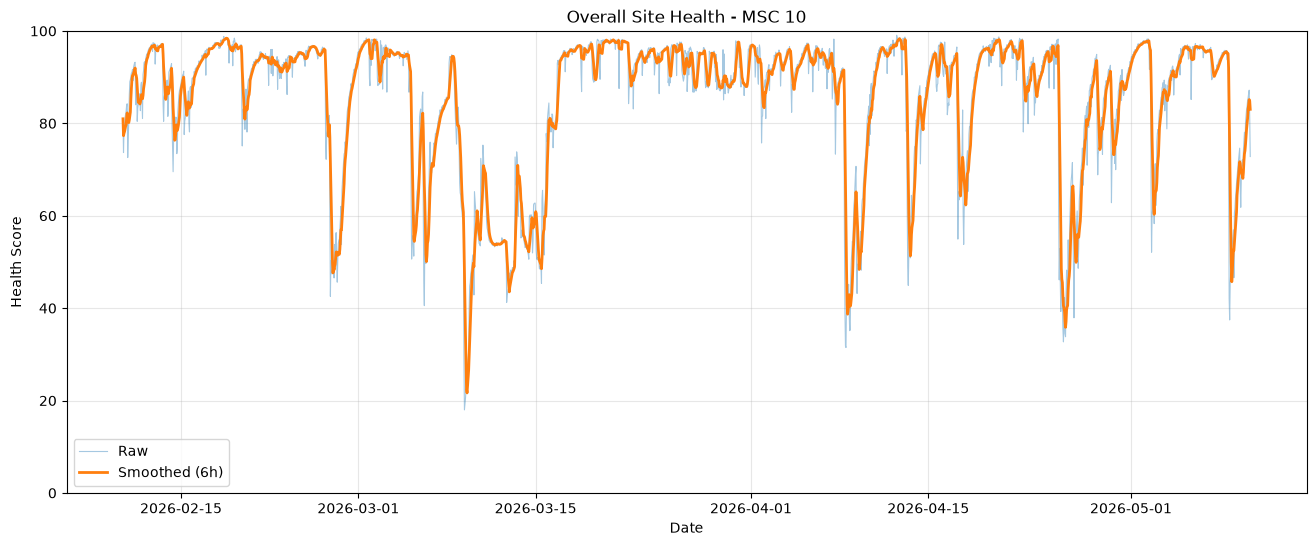

In [34]:
# Overall health over time: raw series plus the smoothed one operators see.
import matplotlib.pyplot as plt

plot_df = (
    health_scores.reset_index()
    .rename(columns={"index": "timestamp"})
)

plot_df["timestamp"] = pd.to_datetime(plot_df["timestamp"])

plt.figure(figsize=(16, 6))

plt.plot(
    plot_df["timestamp"],
    plot_df["overall_site_health"],
    linewidth=0.8,
    alpha=0.4,
    label="Raw"
)

plt.plot(
    plot_df["timestamp"],
    plot_df["overall_site_health_smoothed"],
    linewidth=2,
    label=f"Smoothed ({OVERALL_SMOOTHING_WINDOW_HOURS}h)"
)

plt.title("Overall Site Health - MSC 10")
plt.xlabel("Date")
plt.ylabel("Health Score")
plt.ylim(0, 100)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

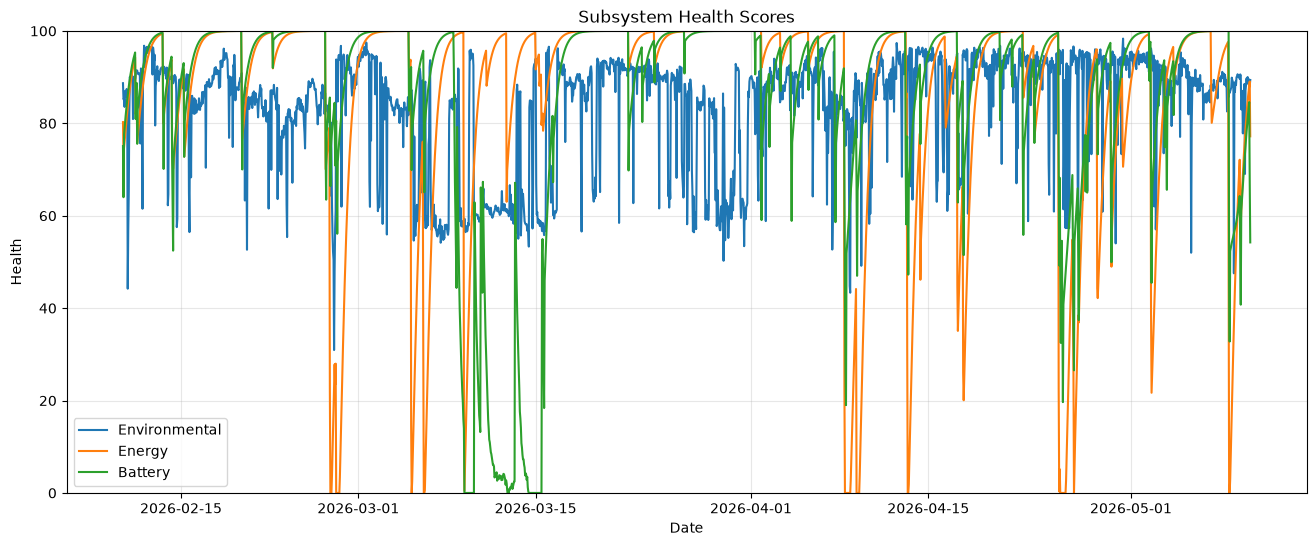

In [35]:
# The three subsystem scores on the same axes, to see which one drives
# each dip in the overall score.
plt.figure(figsize=(16,6))

plt.plot(
    plot_df["timestamp"],
    plot_df["environmental_health_score"],
    label="Environmental"
)

plt.plot(
    plot_df["timestamp"],
    plot_df["energy_health_score"],
    label="Energy"
)

plt.plot(
    plot_df["timestamp"],
    plot_df["battery_health_score"],
    label="Battery"
)

plt.title("Subsystem Health Scores")
plt.xlabel("Date")
plt.ylabel("Health")
plt.ylim(0,100)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

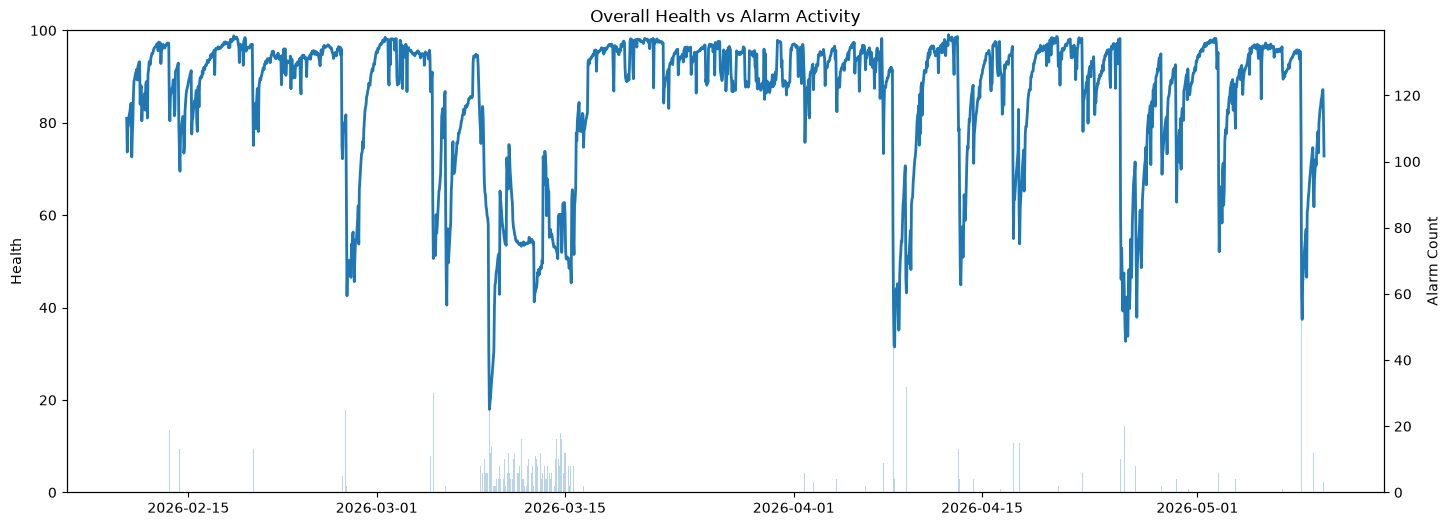

In [36]:
# Health against raw alarm volume on a second axis - a visual check that
# the score really drops when the site is noisy.
alarm_activity = (
    df_combined
    .set_index("log_time")
    .resample("1h")
    .size()
    .rename("alarm_count")
)

plot_df = (
    plot_df
    .merge(
        alarm_activity,
        left_on="timestamp",
        right_index=True,
        how="left"
    )
)

plot_df["alarm_count"] = plot_df["alarm_count"].fillna(0)

fig, ax1 = plt.subplots(figsize=(17,6))

ax1.plot(
    plot_df["timestamp"],
    plot_df["overall_site_health"],
    linewidth=2,
    label="Overall Health"
)

ax1.set_ylabel("Health")
ax1.set_ylim(0,100)

ax2 = ax1.twinx()

ax2.bar(
    plot_df["timestamp"],
    plot_df["alarm_count"],
    alpha=0.3,
    width=0.03
)

ax2.set_ylabel("Alarm Count")

plt.title("Overall Health vs Alarm Activity")

plt.show()

In [37]:
# Worst 15 hours by raw health, for triage: which subsystem was driving the
# dip, and whether it was an isolated blip or a sustained problem.
worst_hours = (
    health_scores
    .nsmallest(15, "overall_site_health")
    [
        [
            "overall_site_health",
            "overall_site_health_trend_24h",
            "environmental_health_score",
            "energy_health_score",
            "battery_health_score",
            "battery_alarm_duration_hours",
            "outage_duration_hours"
        ]
    ]
)

display(worst_hours)

,overall_site_health,overall_site_health_trend_24h,environmental_health_score,energy_health_score,battery_health_score,battery_alarm_duration_hours,outage_duration_hours
timestamp,,,,,,,
2026-03-09 09:00:00,17.976257,-76.878814,59.379065,0.464391,0.000000,14,0
2026-03-09 10:00:00,19.142299,-75.460202,57.639098,5.287342,0.000000,15,0
2026-03-09 11:00:00,20.486704,-73.791130,56.453568,10.144666,0.000000,16,0
2026-03-09 12:00:00,22.505493,-72.114284,57.526851,14.992679,0.000000,17,0
2026-03-09 13:00:00,24.245621,-67.964492,57.728361,19.791749,0.000000,18,0
2026-03-09 14:00:00,25.561863,-62.161557,56.614799,24.506922,0.000000,19,0
2026-03-09 15:00:00,27.266596,-56.758083,56.929039,29.108241,0.000000,20,0
2026-03-09 16:00:00,29.274436,-51.655938,58.415504,33.570813,0.000000,21,0
2026-03-09 08:00:00,30.237442,-63.984064,57.921567,22.802900,13.942736,13,1


In [38]:
# ============================================================
# 9. ENERGY SCORE CALIBRATION
# The raw energy risk saturates at 100 too easily (energy_pm_risk alone
# sits at its ceiling all year), which flattened the whole site score.
# The raw values are kept under *_raw so the effect stays auditable.
# ============================================================
import numpy as np
import pandas as pd

health_scores = health_scores.copy()

# Preserve original energy values
if "energy_risk_score_raw" not in health_scores.columns:
    health_scores["energy_risk_score_raw"] = (
        health_scores["energy_risk_score"]
    )

if "energy_health_score_raw" not in health_scores.columns:
    health_scores["energy_health_score_raw"] = (
        health_scores["energy_health_score"]
    )

raw_energy_risk = (
    health_scores["energy_risk_score_raw"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .clip(0, 100)
)

# Soft compression:
# low and moderate risks remain meaningful,
# but a raw score of 100 does not automatically force health to 0.
health_scores["energy_risk_score_calibrated"] = (
    100 * (
        1 - np.exp(-raw_energy_risk / 60)
    )
).clip(0, 100)

In [39]:
# Compression alone would also soften genuinely serious outages, so a
# floor is put back under the risk whenever an outage is long or is
# accompanied by generator/transfer activity.
# NOTE: generator_hours and power_transfer_hours are never created in
# this notebook, so those two branches always evaluate to 0 - only the
# 'outage >= 4 h' condition can actually trigger the floor today.
outage_duration = (
    health_scores.get(
        "outage_duration_hours",
        pd.Series(0, index=health_scores.index)
    )
    .fillna(0)
    .clip(lower=0)
)

generator_duration = (
    health_scores.get(
        "generator_hours",
        pd.Series(0, index=health_scores.index)
    )
    .fillna(0)
    .clip(lower=0)
)

transfer_duration = (
    health_scores.get(
        "power_transfer_hours",
        pd.Series(0, index=health_scores.index)
    )
    .fillna(0)
    .clip(lower=0)
)

# Severe only when the energy problem is persistent
severe_energy_event = (
    (outage_duration >= 4)
    | (
        (outage_duration >= 2)
        & (generator_duration >= 2)
    )
    | (
        (outage_duration >= 2)
        & (transfer_duration >= 3)
    )
)

persistent_energy_floor = (
    85
    + 3 * (outage_duration - 4).clip(lower=0)
).clip(upper=100)

health_scores.loc[
    severe_energy_event,
    "energy_risk_score_calibrated"
] = np.maximum(
    health_scores.loc[
        severe_energy_event,
        "energy_risk_score_calibrated"
    ],
    persistent_energy_floor.loc[severe_energy_event]
)

health_scores["energy_risk_score_calibrated"] = (
    health_scores["energy_risk_score_calibrated"]
    .clip(0, 100)
)

health_scores["energy_health_score_calibrated"] = (
    100 - health_scores["energy_risk_score_calibrated"]
)

In [40]:
# Promote the calibrated series to be the official energy score.
health_scores["energy_risk_score"] = (
    health_scores["energy_risk_score_calibrated"]
)

health_scores["energy_health_score"] = (
    health_scores["energy_health_score_calibrated"]
)

In [41]:
# Before/after view of the calibration on the worst hours.
health_scores[
    [
        "energy_risk_score_raw",
        "energy_risk_score",
        "energy_health_score_raw",
        "energy_health_score",
        "outage_duration_hours"
    ]
].sort_values(
    "energy_risk_score_raw",
    ascending=False
).head(20)

,energy_risk_score_raw,energy_risk_score,energy_health_score_raw,energy_health_score,outage_duration_hours
timestamp,,,,,
2026-02-27 10:00:00,100.0,81.11244,0.0,18.88756,0
2026-02-27 12:00:00,100.0,81.11244,0.0,18.88756,0
2026-02-27 11:00:00,100.0,81.11244,0.0,18.88756,0
2026-02-26 19:00:00,100.0,81.11244,0.0,18.88756,2
2026-02-26 20:00:00,100.0,81.11244,0.0,18.88756,0
2026-05-08 19:00:00,100.0,81.11244,0.0,18.88756,0
2026-05-08 18:00:00,100.0,81.11244,0.0,18.88756,2
2026-03-06 04:00:00,100.0,81.11244,0.0,18.88756,2
2026-02-27 09:00:00,100.0,81.11244,0.0,18.88756,0


In [42]:
# ============================================================
# 10. RECOMPOSING THE OVERALL SCORE AFTER CALIBRATION
# ============================================================
# Each subsystem's weighted contribution is stored as its own column, so
# the overall risk can be explained rather than just reported.
required_score_cols = [
    "environmental_risk_score",
    "energy_risk_score",
    "battery_risk_score"
]

for col in required_score_cols:
    health_scores[col] = (
        health_scores[col]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .clip(0, 100)
    )

health_scores["environmental_contribution"] = (
    WEIGHTS["overall"]["environmental"] * health_scores["environmental_risk_score"]
)

health_scores["energy_contribution"] = (
    WEIGHTS["overall"]["energy"] * health_scores["energy_risk_score"]
)

health_scores["battery_contribution"] = (
    WEIGHTS["overall"]["battery"] * health_scores["battery_risk_score"]
)

health_scores["overall_site_risk"] = (
    health_scores[
        [
            "environmental_contribution",
            "energy_contribution",
            "battery_contribution"
        ]
    ].sum(axis=1)
).clip(0, 100)

health_scores["overall_site_health"] = (
    100 - health_scores["overall_site_risk"]
)


In [43]:
# Main driver = the subsystem contributing the most risk this hour.
# Below 5 points of total risk nothing is really wrong, so the driver is
# reported as 'None' rather than picking an arbitrary winner.
# NOTE: contribution_to_driver is defined but never used (the same
# mapping is inlined below), and the main_driver_share zeroing on the
# last lines is overwritten by the next cell.
contribution_to_driver = {
    "environmental_contribution": "Environmental",
    "energy_contribution": "Energy",
    "battery_contribution": "Battery"
}

health_scores["main_risk_driver"] = np.where(
    health_scores["overall_site_risk"] < 5,
    "None",
    health_scores[
        [
            "environmental_contribution",
            "energy_contribution",
            "battery_contribution"
        ]
    ]
    .idxmax(axis=1)
    .map({
        "environmental_contribution": "Environmental",
        "energy_contribution": "Energy",
        "battery_contribution": "Battery"
    })
)

health_scores.loc[
    health_scores["main_risk_driver"] == "None",
    "main_driver_share"
] = 0

In [44]:
# How concentrated the risk is: 1.0 means a single subsystem accounts
# for all of it, ~0.33 means all three contribute equally.
health_scores["main_driver_share"] = (
    health_scores[
        [
            "environmental_contribution",
            "energy_contribution",
            "battery_contribution"
        ]
    ].max(axis=1)
    / health_scores["overall_site_risk"].replace(0, np.nan)
)

health_scores["main_driver_share"] = (
    health_scores["main_driver_share"]
    .fillna(0)
    .clip(0, 1)
)

In [45]:
# Turn the score into the five operator-facing bands.
# right=False makes each band include its lower bound.
health_scores["site_health_status"] = pd.cut(
    health_scores["overall_site_health"],
    bins=[
        -np.inf,
        40,
        60,
        75,
        90,
        np.inf
    ],
    labels=[
        "Critical",
        "High Risk",
        "Warning",
        "Minor Degradation",
        "Healthy"
    ],
    right=False
)

In [46]:
# Trend, volatility and smoothing on the recomposed overall score
# (the earlier versions were computed before calibration).
health_scores = health_scores.sort_index()

health_scores["overall_site_health_trend_24h"] = (
    health_scores["overall_site_health"]
    - health_scores["overall_site_health"].shift(24)
)

health_scores["overall_site_health_volatility_24h"] = (
    health_scores["overall_site_health"]
    .rolling(
        window=24,
        min_periods=6
    )
    .std()
)

health_scores["overall_site_health_smoothed_6h"] = (
    health_scores["overall_site_health"]
    .rolling(
        window=6,
        min_periods=1
    )
    .mean()
)

In [47]:
# Recreate trend status
conditions = [
    health_scores["overall_site_health_trend_24h"] <= -15,
    health_scores["overall_site_health_trend_24h"] <= -5,
    health_scores["overall_site_health_trend_24h"] >= 15,
    health_scores["overall_site_health_trend_24h"] >= 5
]

trend_labels = [
    "Rapidly Deteriorating",
    "Deteriorating",
    "Rapidly Improving",
    "Improving"
]

health_scores["health_trend_status"] = np.select(
    conditions,
    trend_labels,
    default="Stable"
)

In [48]:
# ============================================================
# 11. TURNING THE SCORE INTO AN ACTION
# ============================================================
# Rule-based recommendation: the main driver selects the family of
# action, and the duration of the underlying condition selects urgency.
# Above 90 the site is healthy and nothing is recommended.
def recommend_action(row):
    health = row["overall_site_health"]
    driver = row["main_risk_driver"]

    outage_hours = row.get("outage_duration_hours", 0)
    battery_hours = row.get("battery_alarm_duration_hours", 0)

    if pd.isna(outage_hours):
        outage_hours = 0

    if pd.isna(battery_hours):
        battery_hours = 0

    if health >= 90:
        return "Continue routine monitoring"

    if driver == "Battery":
        if battery_hours >= 12:
            return (
                "Urgent UPS battery inspection; check battery capacity, "
                "charger operation and discharge persistence"
            )

        if battery_hours >= 4:
            return (
                "Inspect UPS batteries and charging system; "
                "review recent discharge events"
            )

        return "Review battery alarms, UPS status and recurrence history"

    if driver == "Energy":
        if outage_hours >= 4:
            return (
                "Urgent mains-power investigation; verify generator, "
                "ATS and backup supply operation"
            )

        if outage_hours >= 1:
            return (
                "Investigate recent outage and verify mains-to-backup transfer"
            )

        return (
            "Inspect supply instability, generator activity "
            "and repeated power switching"
        )

    if driver == "Environmental":
        temperature = row.get("temperature", np.nan)
        humidity = row.get("humidity", np.nan)

        if pd.notna(temperature) and temperature > 30:
            return "Inspect HVAC and room cooling; temperature is elevated"

        if pd.notna(humidity) and (
            humidity < 35 or humidity > 60
        ):
            return "Inspect ventilation and humidity control"

        return (
            "Inspect HVAC, sensor stability and environmental conditions"
        )

    return "Review subsystem scores and recent site alarms"


health_scores["recommended_action"] = health_scores.apply(
    recommend_action,
    axis=1
)

In [49]:
# Maintenance priority from the score alone, using the same cut points
# as site_health_status.
priority_conditions = [
    health_scores["overall_site_health"] < 40,
    health_scores["overall_site_health"] < 60,
    health_scores["overall_site_health"] < 75,
    health_scores["overall_site_health"] < 90
]

priority_labels = [
    "P1 - Immediate",
    "P2 - Urgent",
    "P3 - Investigate",
    "P4 - Monitor"
]

health_scores["maintenance_priority"] = np.select(
    priority_conditions,
    priority_labels,
    default="P5 - Routine"
)

In [50]:
# Columns shown in the operator-facing worst-hours table below. This is the
# definition that was missing -- it previously only existed as a variable
# typed directly into the live kernel, never saved to a cell, so a fresh
# top-to-bottom run threw NameError here.
display_columns = [
    "overall_site_health",
    "site_health_status",
    "health_trend_status",
    "main_risk_driver",
    "main_driver_share",
    "maintenance_priority",
    "recommended_action",
    "environmental_health_score",
    "energy_health_score",
    "battery_health_score"
]


In [51]:
# Worst 30 hours in the operator view, tolerating missing columns.
available_display_columns = [
    col for col in display_columns
    if col in health_scores.columns
]

missing_display_columns = [
    col for col in display_columns
    if col not in health_scores.columns
]

print("Missing columns:", missing_display_columns)

health_scores[
    available_display_columns
].sort_values(
    "overall_site_health"
).head(30)

Missing columns: []


,overall_site_health,site_health_status,health_trend_status,main_risk_driver,main_driver_share,maintenance_priority,recommended_action,environmental_health_score,energy_health_score,battery_health_score
timestamp,,,,,,,,,,
2026-03-09 09:00:00,24.475730,Critical,Rapidly Deteriorating,Battery,0.463427,P1 - Immediate,Urgent UPS battery inspection; check battery c...,59.379065,19.034314,0.000000
2026-03-09 10:00:00,24.511360,Critical,Rapidly Deteriorating,Battery,0.463646,P1 - Immediate,Urgent UPS battery inspection; check battery c...,57.639098,20.627515,0.000000
2026-03-09 11:00:00,24.764478,Critical,Rapidly Deteriorating,Battery,0.465206,P1 - Immediate,Urgent UPS battery inspection; check battery c...,56.453568,22.366880,0.000000
2026-03-09 12:00:00,25.745257,Critical,Rapidly Deteriorating,Battery,0.471350,P1 - Immediate,Urgent UPS battery inspection; check battery c...,57.526851,24.249148,0.000000
2026-03-09 13:00:00,26.512442,Critical,Rapidly Deteriorating,Battery,0.476271,P1 - Immediate,Urgent UPS battery inspection; check battery c...,57.728361,26.268382,0.000000
2026-03-09 14:00:00,26.930038,Critical,Rapidly Deteriorating,Battery,0.478993,P1 - Immediate,Urgent UPS battery inspection; check battery c...,56.614799,28.415996,0.000000
2026-03-09 15:00:00,27.817033,Critical,Rapidly Deteriorating,Battery,0.484879,P1 - Immediate,Urgent UPS battery inspection; check battery c...,56.929039,30.680917,0.000000
2026-03-09 16:00:00,29.092099,Critical,Rapidly Deteriorating,Battery,0.493598,P1 - Immediate,Urgent UPS battery inspection; check battery c...,58.415504,33.049851,0.000000
2026-03-09 17:00:00,29.794319,Critical,Rapidly Deteriorating,Battery,0.498535,P1 - Immediate,Urgent UPS battery inspection; check battery c...,57.888800,35.507656,0.000000


In [52]:
# Cross-check the 50 worst hours against the raw alarm log: an hour
# scored as critical should have alarms behind it. 'No alarm recorded'
# would point at a scoring artefact rather than a real incident.
df_combined = df_combined.copy()

df_combined["log_time"] = pd.to_datetime(
    df_combined["log_time"],
    errors="coerce"
)

alarm_validation = (
    df_combined
    .dropna(subset=["log_time"])
    .assign(timestamp=lambda x: x["log_time"].dt.floor("h"))
    .groupby("timestamp")
    .agg(
        total_alarm_count=("message", "size"),
        unique_alarm_messages=("message", "nunique"),
        alarm_messages=(
            "message",
            lambda x: " | ".join(
                pd.Series(x)
                .drop_duplicates()
                .astype(str)
                .head(10)
            )
        )
    )
)
base_cols = [
    "overall_site_health",
    "overall_site_health_trend_24h",
    "environmental_health_score",
    "energy_health_score",
    "battery_health_score",
    "environmental_contribution",
    "energy_contribution",
    "battery_contribution",
    "main_risk_driver",
    "maintenance_priority",
    "recommended_action"
]

optional_cols = [
    "battery_alarm_duration_hours",
    "outage_duration_hours",
    "generator_hours",
    "power_transfer_hours"
]

cols = base_cols + [
    c for c in optional_cols
    if c in health_scores.columns
]

worst_50_hours = (
    health_scores[cols]
    .sort_values("overall_site_health")
    .head(50)
    .join(alarm_validation, how="left")
)

worst_50_hours[
    [
        "total_alarm_count",
        "unique_alarm_messages"
    ]
] = (
    worst_50_hours[
        [
            "total_alarm_count",
            "unique_alarm_messages"
        ]
    ]
    .fillna(0)
)

worst_50_hours["alarm_messages"] = (
    worst_50_hours["alarm_messages"]
    .fillna("No alarm recorded")
)

worst_50_hours[
    [
        "overall_site_health",
        "main_risk_driver",
        "maintenance_priority",
        "total_alarm_count",
        "unique_alarm_messages",
        "alarm_messages",
        "recommended_action"
    ]
]

,overall_site_health,main_risk_driver,maintenance_priority,total_alarm_count,unique_alarm_messages,alarm_messages,recommended_action
timestamp,,,,,,,
2026-03-09 09:00:00,24.475730,Battery,P1 - Immediate,40.0,9.0,\BLIDA MSC 10\ UPS UNIT 1 GENERAL ALARM | \BLI...,Urgent UPS battery inspection; check battery c...
2026-03-09 10:00:00,24.511360,Battery,P1 - Immediate,2.0,1.0,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,Urgent UPS battery inspection; check battery c...
2026-03-09 11:00:00,24.764478,Battery,P1 - Immediate,12.0,1.0,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,Urgent UPS battery inspection; check battery c...
2026-03-09 12:00:00,25.745257,Battery,P1 - Immediate,2.0,1.0,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,Urgent UPS battery inspection; check battery c...
2026-03-09 13:00:00,26.512442,Battery,P1 - Immediate,14.0,1.0,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,Urgent UPS battery inspection; check battery c...
2026-03-09 14:00:00,26.930038,Battery,P1 - Immediate,18.0,1.0,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,Urgent UPS battery inspection; check battery c...
2026-03-09 15:00:00,27.817033,Battery,P1 - Immediate,16.0,1.0,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,Urgent UPS battery inspection; check battery c...
2026-03-09 16:00:00,29.092099,Battery,P1 - Immediate,2.0,1.0,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,Urgent UPS battery inspection; check battery c...
2026-03-09 17:00:00,29.794319,Battery,P1 - Immediate,4.0,1.0,\BLIDA MSC 10\ UPS SOCOMEC 1 CHECK BATTERY,Urgent UPS battery inspection; check battery c...


In [53]:
# The healthiest hours, as a counter-check.
health_scores.sort_values(
    "overall_site_health",
    ascending=False
).head(20)

,temperature,humidity,temp_std_1h,humidity_std_1h,observation_count,temp_term,humidity_term,temp_change_term,humidity_change_term,environmental_base_risk,...,environmental_contribution,energy_contribution,battery_contribution,main_risk_driver,main_driver_share,site_health_status,overall_site_health_smoothed_6h,health_trend_status,recommended_action,maintenance_priority
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-04-12 12:00:00,22.905263,43.326316,0.022942,0.080568,19,0.0,0.000000,0.043893,0.093833,2.285346,...,0.782731,0.191285,0.030923,None,0.778884,Healthy,96.894331,Stable,Continue routine monitoring,P5 - Routine
2026-02-18 09:00:00,23.594444,40.783333,0.023570,0.051450,18,0.0,0.081111,0.045095,0.059920,3.828488,...,1.148547,0.037649,0.014574,None,0.956509,Healthy,98.015471,Stable,Continue routine monitoring,P5 - Routine
2026-04-13 04:00:00,23.203704,43.933333,0.043690,0.124035,27,0.0,0.000000,0.083589,0.144456,3.838628,...,1.317289,0.047943,0.007757,None,0.959431,Healthy,98.123037,Stable,Continue routine monitoring,P5 - Routine
2026-04-13 03:00:00,23.256250,43.837500,0.051235,0.108781,16,0.0,0.000000,0.098024,0.126691,3.860844,...,1.324752,0.052278,0.008457,None,0.956163,Healthy,96.758170,Stable,Continue routine monitoring,P5 - Routine
2026-04-20 13:00:00,21.603571,46.960714,0.042879,0.095604,28,0.0,0.000000,0.082038,0.111345,3.310930,...,1.160619,0.202738,0.052981,None,0.819450,Healthy,97.853896,Stable,Continue routine monitoring,P5 - Routine
2026-04-20 14:00:00,21.500000,46.992857,0.039223,0.107161,14,0.0,0.000000,0.075043,0.124804,3.372927,...,1.182492,0.185967,0.048598,None,0.834470,Healthy,98.039569,Stable,Continue routine monitoring,P5 - Routine
2026-02-18 13:00:00,23.234783,41.200000,0.048698,0.090453,23,0.0,0.053333,0.093171,0.105346,4.776949,...,1.433085,0.026631,0.010316,None,0.974867,Healthy,98.368002,Stable,Continue routine monitoring,P5 - Routine
2026-04-12 18:00:00,23.195652,43.878261,0.036659,0.144463,23,0.0,0.000000,0.070137,0.168248,3.926453,...,1.345792,0.113895,0.018412,None,0.910488,Healthy,98.178273,Improving,Continue routine monitoring,P5 - Routine
2026-02-18 14:00:00,23.273684,40.931579,0.045241,0.074927,19,0.0,0.071228,0.086557,0.087263,4.820791,...,1.446237,0.024422,0.009462,None,0.977107,Healthy,98.423246,Stable,Continue routine monitoring,P5 - Routine


In [54]:
# Confidence in the score itself, separate from the score: an hour built
# on few sensor readings or missing humidity is still scored, but flagged
# as less trustworthy.
health_scores["score_confidence"] = 100

# Few observations reduce confidence
health_scores.loc[
    health_scores["observation_count"] < 10,
    "score_confidence"
] -= 15

# Missing humidity reduces confidence
health_scores.loc[
    health_scores["humidity"].isna(),
    "score_confidence"
] -= 20

# Large sampling gaps reduce confidence
if "time_gap_minutes" in health_scores.columns:
    health_scores.loc[
        health_scores["time_gap_minutes"] > 10,
        "score_confidence"
    ] -= 20

health_scores["score_confidence"] = (
    health_scores["score_confidence"]
    .clip(0, 100)
)

In [55]:
# ============================================================
# 12. WHAT-IF: RE-SCORING UNDER DIFFERENT WEIGHTS
# ============================================================
def recalculate_health_scores(env_hourly, energy_hourly, battery_hourly, health_scores, weights):
    """Recompute subsystem and overall health scores under an alternative
    WEIGHTS configuration.

    Reuses every already-computed anomaly burden, PM risk, and the existing
    energy calibration chain (soft compression + severe/persistent-outage
    floor) unchanged -- only the base-risk term weights and the overall
    subsystem weights actually change. Also recomputes every column that
    depends on overall_site_health (contributions, main_risk_driver,
    main_driver_share, site_health_status, trend/volatility/smoothing,
    health_trend_status, maintenance_priority, recommended_action).

    Does not mutate `env_hourly`, `energy_hourly`, `battery_hourly`, or
    `health_scores`. Returns a new DataFrame aligned on health_scores.index.
    """
    validate_weights(weights)

    result = health_scores.copy()

    # --- Environmental base risk + final risk/health ---
    env = env_hourly.copy()
    env["environmental_base_risk"], _ = calculate_environmental_base_risk(
        env, weights["environmental"]
    )
    env["environmental_risk_score"] = calculate_final_risk(
        env["environmental_base_risk"],
        env["environmental_anomaly_burden"],
        env["environmental_pm_risk"],
        0.50,
        0.30
    )
    env["environmental_health_score"] = 100 - env["environmental_risk_score"]

    # --- Energy base risk + sequence anomaly + final risk/health ---
    energy = energy_hourly.copy()
    energy["energy_base_risk"], energy_active_weights = calculate_energy_base_risk(
        energy, weights["energy"]
    )
    energy["energy_sequence_anomaly"] = (
        energy[list(energy_active_weights.keys())].mean(axis=1)
    ).clip(0, 1)
    energy["energy_anomaly_burden"] = (
        0.40 * energy["energy_frequency_anomaly"]
        + 0.35 * energy["energy_duration_anomaly"]
        + 0.25 * energy["energy_sequence_anomaly"]
    ).clip(0, 1)
    energy["energy_risk_score"] = calculate_final_risk(
        energy["energy_base_risk"],
        energy["energy_anomaly_burden"],
        energy["energy_pm_risk"],
        0.50,
        0.35
    )
    energy["energy_health_score"] = 100 - energy["energy_risk_score"]

    # --- Battery base risk + final risk/health ---
    battery = battery_hourly.copy()
    battery["battery_base_risk"], _ = calculate_battery_base_risk(
        battery, weights["battery"]
    )
    battery["battery_risk_score"] = calculate_final_risk(
        base_risk=battery["battery_base_risk"],
        anomaly_burden=battery["battery_anomaly_burden"],
        maintenance_risk=battery["battery_pm_risk"],
        anomaly_weight=0.50,
        maintenance_weight=0.50
    )
    battery["battery_health_score"] = 100 - battery["battery_risk_score"]

    # --- Align onto health_scores' own index, same as the original pipeline ---
    result["environmental_risk_score"] = env["environmental_risk_score"].reindex(result.index)
    result["environmental_health_score"] = env["environmental_health_score"].reindex(result.index)
    result["energy_risk_score_raw"] = energy["energy_risk_score"].reindex(result.index)
    result["battery_risk_score"] = battery["battery_risk_score"].reindex(result.index)
    result["battery_health_score"] = battery["battery_health_score"].reindex(result.index)

    # --- Reapply the notebook's existing energy calibration exactly:
    #     soft compression, then a floor for severe/persistent outages ---
    raw_energy_risk = (
        result["energy_risk_score_raw"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .clip(0, 100)
    )

    result["energy_risk_score_calibrated"] = (
        100 * (1 - np.exp(-raw_energy_risk / 60))
    ).clip(0, 100)

    outage_duration = (
        result.get("outage_duration_hours", pd.Series(0, index=result.index))
        .fillna(0).clip(lower=0)
    )
    # These two columns don't exist in this notebook (pre-existing --
    # generator/backup-transfer duration was never tracked the way outage
    # duration was), so they default to all-zero via .get(), same as the
    # original calibration cell. Left as-is, not fixed, per scope.
    generator_duration = (
        result.get("generator_hours", pd.Series(0, index=result.index))
        .fillna(0).clip(lower=0)
    )
    transfer_duration = (
        result.get("power_transfer_hours", pd.Series(0, index=result.index))
        .fillna(0).clip(lower=0)
    )

    severe_energy_event = (
        (outage_duration >= 4)
        | ((outage_duration >= 2) & (generator_duration >= 2))
        | ((outage_duration >= 2) & (transfer_duration >= 3))
    )

    persistent_energy_floor = (
        85 + 3 * (outage_duration - 4).clip(lower=0)
    ).clip(upper=100)

    result.loc[severe_energy_event, "energy_risk_score_calibrated"] = np.maximum(
        result.loc[severe_energy_event, "energy_risk_score_calibrated"],
        persistent_energy_floor.loc[severe_energy_event]
    )
    result["energy_risk_score_calibrated"] = (
        result["energy_risk_score_calibrated"].clip(0, 100)
    )
    result["energy_health_score_calibrated"] = (
        100 - result["energy_risk_score_calibrated"]
    )

    result["energy_risk_score"] = result["energy_risk_score_calibrated"]
    result["energy_health_score"] = result["energy_health_score_calibrated"]

    for col in ["environmental_risk_score", "energy_risk_score", "battery_risk_score"]:
        result[col] = (
            result[col].replace([np.inf, -np.inf], np.nan).fillna(0).clip(0, 100)
        )

    # --- Overall risk/health + contributions ---
    overall_weights = weights["overall"]
    result["environmental_contribution"] = (
        overall_weights["environmental"] * result["environmental_risk_score"]
    )
    result["energy_contribution"] = (
        overall_weights["energy"] * result["energy_risk_score"]
    )
    result["battery_contribution"] = (
        overall_weights["battery"] * result["battery_risk_score"]
    )

    result["overall_site_risk"] = result[
        ["environmental_contribution", "energy_contribution", "battery_contribution"]
    ].sum(axis=1).clip(0, 100)
    result["overall_site_health"] = 100 - result["overall_site_risk"]

    # --- Main risk driver / share ---
    result["main_risk_driver"] = np.where(
        result["overall_site_risk"] < 5,
        "None",
        result[
            ["environmental_contribution", "energy_contribution", "battery_contribution"]
        ].idxmax(axis=1).map({
            "environmental_contribution": "Environmental",
            "energy_contribution": "Energy",
            "battery_contribution": "Battery"
        })
    )

    # NOTE: the original notebook's cell 41 sets main_driver_share to 0 for
    # "None"-driver rows via .loc, but the very next cell (42) immediately
    # overwrites the whole column with this formula -- so that zeroing is
    # dead code in the live pipeline today. Reproduced faithfully here
    # (i.e. NOT re-applying the zero), matching actual current behavior
    # rather than the apparently-intended one.
    result["main_driver_share"] = (
        result[["environmental_contribution", "energy_contribution", "battery_contribution"]]
        .max(axis=1) / result["overall_site_risk"].replace(0, np.nan)
    ).fillna(0).clip(0, 1)

    # --- Site health status ---
    result["site_health_status"] = pd.cut(
        result["overall_site_health"],
        bins=[-np.inf, 40, 60, 75, 90, np.inf],
        labels=["Critical", "High Risk", "Warning", "Minor Degradation", "Healthy"],
        right=False
    )

    # --- Maintenance priority ---
    result["maintenance_priority"] = np.select(
        [
            result["overall_site_health"] < 40,
            result["overall_site_health"] < 60,
            result["overall_site_health"] < 75,
            result["overall_site_health"] < 90
        ],
        ["P1 - Immediate", "P2 - Urgent", "P3 - Investigate", "P4 - Monitor"],
        default="P5 - Routine"
    )

    # --- Recommended action (reuses the existing function, defined earlier
    #     in the notebook, unchanged) ---
    result["recommended_action"] = result.apply(recommend_action, axis=1)

    # --- Trend / volatility / smoothing, for every health score column ---
    result = result.sort_index()

    for column in [
        "environmental_health_score",
        "energy_health_score",
        "battery_health_score",
        "overall_site_health"
    ]:
        result[f"{column}_trend_6h"] = result[column].diff(TREND_SHORT_HOURS)
        result[f"{column}_trend_24h"] = result[column].diff(TREND_LONG_HOURS)
        result[f"{column}_volatility_24h"] = (
            result[column].rolling(VOLATILITY_WINDOW_HOURS, min_periods=6).std()
        )

    result["overall_site_health_trend_label"] = (
        result["overall_site_health_trend_24h"].apply(classify_trend)
    )

    result["overall_site_health_smoothed"] = (
        result["overall_site_health"]
        .rolling(OVERALL_SMOOTHING_WINDOW_HOURS, min_periods=1)
        .mean()
    )
    result["overall_site_health_smoothed_6h"] = result["overall_site_health_smoothed"]

    result["health_trend_status"] = np.select(
        [
            result["overall_site_health_trend_24h"] <= -15,
            result["overall_site_health_trend_24h"] <= -5,
            result["overall_site_health_trend_24h"] >= 15,
            result["overall_site_health_trend_24h"] >= 5
        ],
        ["Rapidly Deteriorating", "Deteriorating", "Rapidly Improving", "Improving"],
        default="Stable"
    )

    result["weight_version"] = WEIGHT_VERSION

    return result


def build_comparison(original, adjusted):
    """Row-aligned before/after comparison of overall site health and status.

    `original` and `adjusted` must share the same index. Returns a new
    DataFrame with original/adjusted overall health, their difference, and
    whether the site_health_status bucket changed.
    """
    comparison = pd.DataFrame(index=original.index)
    comparison["original_overall_site_health"] = original["overall_site_health"]
    comparison["adjusted_overall_site_health"] = adjusted["overall_site_health"]
    comparison["health_difference"] = (
        comparison["adjusted_overall_site_health"]
        - comparison["original_overall_site_health"]
    )
    comparison["original_status"] = original["site_health_status"].astype(str)
    comparison["adjusted_status"] = adjusted["site_health_status"].astype(str)
    comparison["status_changed"] = (
        comparison["original_status"] != comparison["adjusted_status"]
    )
    return comparison


# Populate adjusted_health_scores / comparison_df once up front, using the
# baseline WEIGHTS, so the rest of this section (and the final validation
# cell) works even before anyone touches a slider.
adjusted_health_scores = recalculate_health_scores(
    env_hourly, energy_hourly, battery_hourly, health_scores, WEIGHTS
)
comparison_df = build_comparison(health_scores, adjusted_health_scores)

print(
    "Initial adjusted_health_scores computed with baseline WEIGHTS "
    "(identical to health_scores). Adjust the sliders below and click "
    "'Apply Weights' to explore alternative scenarios."
)


energy: no signal in this log, weight redistributed -> ['transfer_term']
battery: no signal in this log, weight redistributed -> ['chatter_component', 'low_battery_component']
Initial adjusted_health_scores computed with baseline WEIGHTS (identical to health_scores). Adjust the sliders below and click 'Apply Weights' to explore alternative scenarios.


In [56]:
# Interactive weight editor: one control per weight, live validation that
# each group still sums to 1, and an Apply button that re-scores the whole
# site and reports how much the result moved.
# Requires ipywidgets and a live kernel; nothing below depends on it,
# since the baseline results were already computed in the cell above.
import copy
import ipywidgets as widgets
from IPython.display import display as ip_display, clear_output


def _make_weight_control(label, value):
    return widgets.BoundedFloatText(
        value=value,
        min=0,
        max=1,
        step=0.01,
        description=label,
        style={"description_width": "170px"},
        layout=widgets.Layout(width="320px")
    )


_slider_groups = {
    group: {
        key: _make_weight_control(key.replace("_", " ").title(), value)
        for key, value in group_weights.items()
    }
    for group, group_weights in WEIGHTS.items()
}

_group_total_labels = {group: widgets.Label() for group in _slider_groups}
_status_label = widgets.Label()
_weight_output = widgets.Output()


def _refresh_totals(*_ignored):
    all_valid = True

    for group, sliders in _slider_groups.items():
        total = sum(control.value for control in sliders.values())
        is_valid = abs(total - 1.0) < 1e-6
        all_valid = all_valid and is_valid
        flag = "OK" if is_valid else "does not sum to 1 -- cannot apply"
        _group_total_labels[group].value = f"{group} total: {total:.3f} ({flag})"

    _status_label.value = (
        "All groups valid -- ready to apply."
        if all_valid
        else "Fix the flagged group(s) above before applying."
    )


for _sliders in _slider_groups.values():
    for _control in _sliders.values():
        _control.observe(_refresh_totals, names="value")

_apply_button = widgets.Button(description="Apply Weights", button_style="success")
_reset_button = widgets.Button(description="Reset to Defaults", button_style="warning")


def _collect_weights_from_widgets():
    return {
        group: {key: control.value for key, control in sliders.items()}
        for group, sliders in _slider_groups.items()
    }


def _set_widgets_from_weights(weights_dict):
    for group, sliders in _slider_groups.items():
        for key, control in sliders.items():
            control.value = weights_dict[group][key]
    _refresh_totals()


def _on_apply_clicked(_button):
    global adjusted_health_scores, comparison_df

    with _weight_output:
        clear_output()
        candidate_weights = _collect_weights_from_widgets()

        try:
            validate_weights(candidate_weights)
        except ValueError as exc:
            print(f"Cannot apply -- invalid weights: {exc}")
            return

        before = health_scores["overall_site_health"]

        adjusted_health_scores = recalculate_health_scores(
            env_hourly, energy_hourly, battery_hourly, health_scores, candidate_weights
        )
        comparison_df = build_comparison(health_scores, adjusted_health_scores)

        after = adjusted_health_scores["overall_site_health"]

        print("Applied weights:")
        for group, values in candidate_weights.items():
            rounded_values = {key: round(value, 3) for key, value in values.items()}
            print(f"  {group}: {rounded_values}")

        print()
        print(f"Mean overall health -- before: {before.mean():.2f}  after: {after.mean():.2f}")
        print(f"Min overall health  -- before: {before.min():.2f}  after: {after.min():.2f}")
        print(f"Max overall health  -- before: {before.max():.2f}  after: {after.max():.2f}")
        print(f"Mean |change|: {comparison_df['health_difference'].abs().mean():.2f}")

        changed = int(comparison_df["status_changed"].sum())
        pct_changed = changed / len(comparison_df) * 100
        print(f"Hours with a status change: {changed} ({pct_changed:.1f}%)")

        print()
        print("Top 5 largest absolute changes:")
        top5 = (
            comparison_df
            .reindex(comparison_df["health_difference"].abs().sort_values(ascending=False).index)
            .head(5)
        )
        ip_display(top5)


def _on_reset_clicked(_button):
    _set_widgets_from_weights(WEIGHTS)
    with _weight_output:
        clear_output()
        print("Sliders reset to baseline WEIGHTS (health_scores and adjusted_health_scores unchanged).")


_apply_button.on_click(_on_apply_clicked)
_reset_button.on_click(_on_reset_clicked)
_refresh_totals()


def _labeled_column(title, sliders):
    return widgets.VBox([widgets.HTML(f"<b>{title}</b>")] + list(sliders.values()))


ip_display(widgets.VBox([
    widgets.HBox([
        _labeled_column("Environmental", _slider_groups["environmental"]),
        _labeled_column("Energy", _slider_groups["energy"])
    ]),
    widgets.HBox([
        _labeled_column("Battery", _slider_groups["battery"]),
        _labeled_column("Overall", _slider_groups["overall"])
    ]),
    widgets.HBox([_group_total_labels[g] for g in _slider_groups]),
    _status_label,
    widgets.HBox([_apply_button, _reset_button]),
    _weight_output
]))


### Before vs. After: Overall Site Health

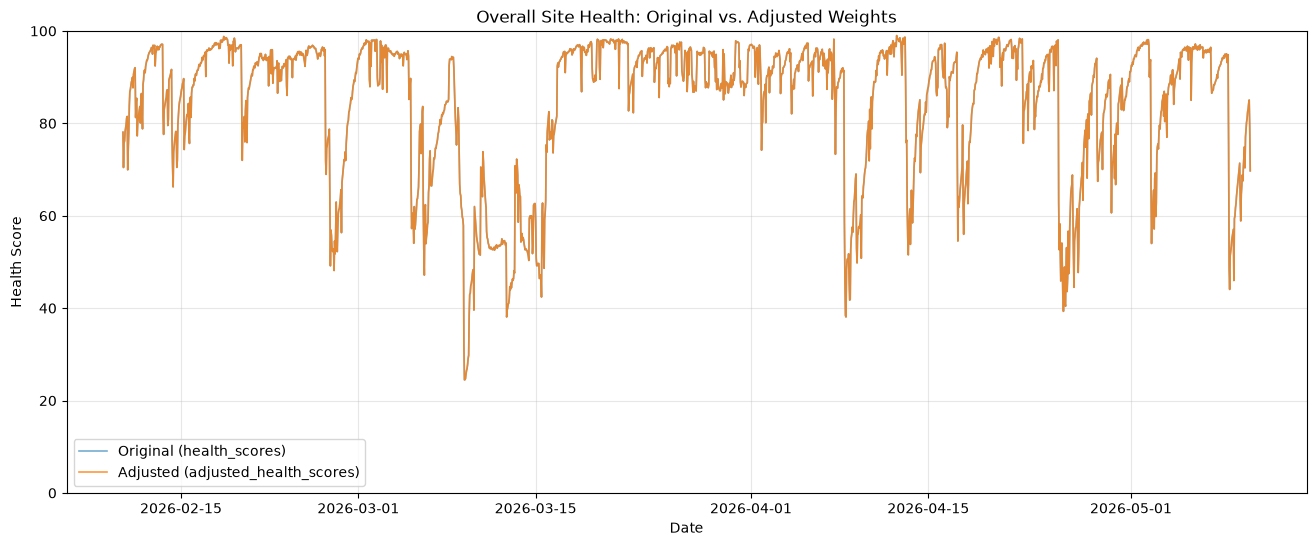

In [57]:
# Baseline vs adjusted overall health, on the same axes.
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

plt.plot(
    comparison_df.index,
    comparison_df["original_overall_site_health"],
    linewidth=1.2,
    alpha=0.6,
    label="Original (health_scores)"
)

plt.plot(
    comparison_df.index,
    comparison_df["adjusted_overall_site_health"],
    linewidth=1.2,
    alpha=0.8,
    label="Adjusted (adjusted_health_scores)"
)

plt.title("Overall Site Health: Original vs. Adjusted Weights")
plt.xlabel("Date")
plt.ylabel("Health Score")
plt.ylim(0, 100)
plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [58]:
# Sensitivity analysis: how much does the verdict depend on the weights?
# Each scenario shifts 0.20 onto one subsystem and re-scores everything;
# a high correlation with the baseline means the conclusions are robust.
def _tilt_overall_weights(base_weights, boost_key, boost_amount):
    """Copy of base_weights with `boost_amount` shifted onto
    WEIGHTS['overall'][boost_key], taken proportionally from the other two
    overall keys so the group still sums to 1. Only the 'overall' group is
    tilted -- the per-subsystem term weights are left at baseline.
    """
    new_weights = copy.deepcopy(base_weights)
    overall = new_weights["overall"]

    other_keys = [key for key in overall if key != boost_key]
    other_total = sum(overall[key] for key in other_keys)

    overall[boost_key] = min(overall[boost_key] + boost_amount, 1.0)
    remaining = 1.0 - overall[boost_key]

    if other_total > 0:
        for key in other_keys:
            overall[key] = remaining * (overall[key] / other_total)
    else:
        share = remaining / len(other_keys)
        for key in other_keys:
            overall[key] = share

    return new_weights


def run_sensitivity_analysis(configurations, env_hourly, energy_hourly, battery_hourly, health_scores):
    """Recalculate scores under each named weight configuration and compare
    against 'Baseline'.

    `configurations` is a dict: name -> WEIGHTS-shaped dict (each must
    already be valid per validate_weights). Returns a DataFrame, one row
    per configuration, indexed by configuration name.
    """
    if "Baseline" not in configurations:
        raise ValueError("configurations must include a 'Baseline' entry.")

    baseline_health = recalculate_health_scores(
        env_hourly, energy_hourly, battery_hourly, health_scores, configurations["Baseline"]
    )["overall_site_health"]

    rows = []

    for name, weights in configurations.items():
        validate_weights(weights)

        scored = recalculate_health_scores(
            env_hourly, energy_hourly, battery_hourly, health_scores, weights
        )
        health = scored["overall_site_health"]

        rows.append({
            "configuration": name,
            "mean_health": health.mean(),
            "median_health": health.median(),
            "min_health": health.min(),
            "std_health": health.std(),
            "critical_hours": int((scored["site_health_status"] == "Critical").sum()),
            "high_risk_hours": int((scored["site_health_status"] == "High Risk").sum()),
            "correlation_with_baseline": health.corr(baseline_health),
            "mean_abs_diff_from_baseline": (health - baseline_health).abs().mean(),
            "max_abs_diff_from_baseline": (health - baseline_health).abs().max()
        })

    return pd.DataFrame(rows).set_index("configuration")


SENSITIVITY_CONFIGURATIONS = {
    "Baseline": copy.deepcopy(WEIGHTS),
    "Environment-focused": _tilt_overall_weights(WEIGHTS, "environmental", 0.20),
    "Energy-focused": _tilt_overall_weights(WEIGHTS, "energy", 0.20),
    "Battery-focused": _tilt_overall_weights(WEIGHTS, "battery", 0.20)
}

for _name, _weights in SENSITIVITY_CONFIGURATIONS.items():
    validate_weights(_weights)

sensitivity_results = run_sensitivity_analysis(
    SENSITIVITY_CONFIGURATIONS, env_hourly, energy_hourly, battery_hourly, health_scores
)

display(sensitivity_results)


energy: no signal in this log, weight redistributed -> ['transfer_term']
battery: no signal in this log, weight redistributed -> ['chatter_component', 'low_battery_component']
energy: no signal in this log, weight redistributed -> ['transfer_term']
battery: no signal in this log, weight redistributed -> ['chatter_component', 'low_battery_component']
energy: no signal in this log, weight redistributed -> ['transfer_term']
battery: no signal in this log, weight redistributed -> ['chatter_component', 'low_battery_component']
energy: no signal in this log, weight redistributed -> ['transfer_term']
battery: no signal in this log, weight redistributed -> ['chatter_component', 'low_battery_component']
energy: no signal in this log, weight redistributed -> ['transfer_term']
battery: no signal in this log, weight redistributed -> ['chatter_component', 'low_battery_component']


,mean_health,median_health,min_health,std_health,critical_hours,high_risk_hours,correlation_with_baseline,mean_abs_diff_from_baseline,max_abs_diff_from_baseline
configuration,,,,,,,,,
Baseline,84.650637,90.956256,24.475730,15.049173,17,222,1.000000,0.000000,0.000000
Environment-focused,84.393396,89.757776,33.818504,12.839371,10,166,0.972227,2.944587,15.323905
Energy-focused,84.506455,92.101975,22.801448,16.275826,33,200,0.960396,3.072464,14.694822
Battery-focused,85.032271,92.483531,16.944736,17.282207,98,127,0.974186,2.685104,19.271733


## Weight Versioning + Export

In [59]:
# Export the exact weight configuration alongside the scores, so any
# published score can be traced back to the weights that produced it.
import json as _json
from datetime import datetime, timezone

health_scores["weight_version"] = WEIGHT_VERSION
adjusted_health_scores["weight_version"] = WEIGHT_VERSION

WEIGHTS_EXPORT_PATH = f"../data/health_score_weights_{WEIGHT_VERSION.replace('.', '_')}_synthetic.json"

weights_export = {
    "version": WEIGHT_VERSION,
    "created_at": datetime.now(timezone.utc).isoformat(),
    "weights": WEIGHTS,
    "pm_maintenance_intervals_days": {
        "environmental": ENV_MAINTENANCE_INTERVAL_DAYS,
        "energy": ENERGY_MAINTENANCE_INTERVAL_DAYS,
        "battery": BATTERY_MAINTENANCE_INTERVAL_DAYS
    },
    "anomaly_and_pm_multipliers": {
        "environmental": {"anomaly_weight": 0.50, "maintenance_weight": 0.30},
        "energy": {"anomaly_weight": 0.50, "maintenance_weight": 0.35},
        "battery": {"anomaly_weight": 0.50, "maintenance_weight": 0.50}
    }
}

with open(WEIGHTS_EXPORT_PATH, "w", encoding="utf-8") as f:
    _json.dump(weights_export, f, indent=2)

print(f"Saved weight configuration to {WEIGHTS_EXPORT_PATH}")


Saved weight configuration to ../data/health_score_weights_v1_0.json


In [60]:
# ============================================================
# 13. FROM SCORING TO FORECASTING
# Everything above describes the site NOW. Everything below tries to
# predict where the score will be in 6 hours.
# ============================================================
# Freeze the scored table as a versioned dataset plus its metadata.
forecast_scores = health_scores.copy()

forecast_scores["weight_version"] = "v1.0"
forecast_scores["score_version"] = "health_score_v1.0"

forecast_scores.to_csv(
    "site_health_scores_v1_0_synthetic.csv",
    index=True
)

import json
from datetime import datetime

score_metadata = {
    "score_version": "health_score_v1.0",
    "weight_version": "v1.0",
    "created_at": datetime.now().isoformat(),
    "weights": WEIGHTS,
    "validation_status": "all_checks_passed",
    "weight_redistribution": {
        "energy": ["transfer_term"],
        "battery": [
            "chatter_component",
            "low_battery_component"
        ]
    }
}

with open(
    "health_score_v1_0_metadata_synthetic.json",
    "w"
) as file:
    json.dump(score_metadata, file, indent=4)

In [61]:
# Supervised framing: the target is the overall health 6 hours later
# (shift(-6)), and the predictors are lags and rolling statistics of the
# same series - only ever looking backwards.
forecast_data = forecast_scores.copy()

forecast_data["target_health_6h"] = (
    forecast_data["overall_site_health"]
    .shift(-6)
)

for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
    forecast_data[f"health_lag_{lag}h"] = (
        forecast_data["overall_site_health"]
        .shift(lag)
    )
for window in [6, 12, 24, 72, 168]:
    forecast_data[f"health_mean_{window}h"] = (
        forecast_data["overall_site_health"]
        .rolling(window, min_periods=window)
        .mean()
    )

    forecast_data[f"health_std_{window}h"] = (
        forecast_data["overall_site_health"]
        .rolling(window, min_periods=window)
        .std()
    )

    forecast_data[f"health_min_{window}h"] = (
        forecast_data["overall_site_health"]
        .rolling(window, min_periods=window)
        .min()
    )

In [62]:
# Calendar features, then drop the trailing rows whose future value is
# unknown (rather than filling them, which would invent labels).
forecast_data["hour"] = forecast_data.index.hour
forecast_data["day_of_week"] = forecast_data.index.dayofweek
forecast_data["month"] = forecast_data.index.month
forecast_data["is_weekend"] = (
    forecast_data["day_of_week"] >= 5
).astype(int)

forecast_data = forecast_data.dropna(
    subset=["target_health_6h"]
).copy()

forecast_data = forecast_data.dropna(
    subset=["target_health_6h"]
).copy()

In [63]:
# Modelling imports.
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

from sklearn.linear_model import LinearRegression

In [64]:
# The index must be a clean, sorted, unique hourly DatetimeIndex before
# any lag or rolling feature can be trusted.
forecast_data.index = pd.to_datetime(
    forecast_data.index,
    errors="coerce"
)

forecast_data = (
    forecast_data
    .loc[forecast_data.index.notna()]
    .sort_index()
)

forecast_data = forecast_data[
    ~forecast_data.index.duplicated(keep="last")
].copy()

print("Shape:", forecast_data.shape)
print("Period:", forecast_data.index.min(), "to", forecast_data.index.max())
print("Duplicate timestamps:", forecast_data.index.duplicated().sum())
print("Target missing:", forecast_data["overall_site_health"].isna().sum())

Shape: (2131, 120)
Period: 2026-02-10 10:00:00 to 2026-05-10 04:00:00
Duplicate timestamps: 0
Target missing: 0


In [65]:
# How regular is the series really? The share of consecutive timestamps
# exactly one hour apart tells us whether shift(1) means '1 hour ago'.
time_differences = (
    forecast_data.index
    .to_series()
    .diff()
    .dropna()
)

print(time_differences.value_counts().head(10))

expected_hourly_ratio = (
    time_differences == pd.Timedelta(hours=1)
).mean()

print(
    f"\nPercentage of consecutive timestamps exactly 1 hour apart: "
    f"{expected_hourly_ratio:.2%}"
)

timestamp
0 days 01:00:00    2130
Name: count, dtype: int64

Percentage of consecutive timestamps exactly 1 hour apart: 100.00%


In [66]:
# Which hours are missing outright from the range.
full_hourly_index = pd.date_range(
    start=forecast_data.index.min(),
    end=forecast_data.index.max(),
    freq="h"
)

missing_hours = full_hourly_index.difference(
    forecast_data.index
)

print("Missing hourly timestamps:", len(missing_hours))

Missing hourly timestamps: 0


In [67]:
# Version stamps and the forecast horizon, in one place.
SCORE_VERSION = "health_score_v1.0"
WEIGHT_VERSION = "v1.0"
FORECAST_HORIZON = 6

forecast_data["score_version"] = SCORE_VERSION
forecast_data["weight_version"] = WEIGHT_VERSION

In [68]:
# Rebuild the target from the named horizon constant.
forecast_data["target_health_6h"] = (
    forecast_data["overall_site_health"]
    .shift(-FORECAST_HORIZON)
)

In [69]:
# Verify the target really is the value 6 rows ahead - a silent off-by-one
# here would leak the future into training and invalidate every metric.
target_check = pd.DataFrame({
    "current_health": forecast_data["overall_site_health"],
    "target_health_6h": forecast_data["target_health_6h"],
    "expected_target": forecast_data[
        "overall_site_health"
    ].shift(-6)
})

display(target_check.head(10))

assert np.allclose(
    target_check["target_health_6h"].dropna(),
    target_check["expected_target"].dropna()
)

print("[OK] Six-hour target created correctly.")

,current_health,target_health_6h,expected_target
timestamp,,,
2026-02-10 10:00:00,78.079099,79.759033,79.759033
2026-02-10 11:00:00,70.449903,81.161668,81.161668
2026-02-10 12:00:00,75.748957,81.491936,81.491936
2026-02-10 13:00:00,76.194398,69.949511,69.949511
2026-02-10 14:00:00,78.202676,74.589165,74.589165
2026-02-10 15:00:00,79.018957,77.897610,77.897610
2026-02-10 16:00:00,79.759033,83.787784,83.787784
2026-02-10 17:00:00,81.161668,86.818306,86.818306
2026-02-10 18:00:00,81.491936,87.329482,87.329482


[OK] Six-hour target created correctly.


In [70]:
# ============================================================
# 14. FEATURE ENGINEERING FOR THE FORECAST
# ============================================================
# Lags of the overall score, from 1 hour to a full week.
HEALTH_LAGS = [
    1,
    2,
    3,
    6,
    12,
    24,
    48,
    72,
    168
]

for lag in HEALTH_LAGS:
    forecast_data[f"overall_health_lag_{lag}h"] = (
        forecast_data["overall_site_health"]
        .shift(lag)
    )

In [71]:
# Lags of each subsystem score.
SUBSYSTEM_HEALTH_COLUMNS = [
    "environmental_health_score",
    "energy_health_score",
    "battery_health_score"
]

for column in SUBSYSTEM_HEALTH_COLUMNS:
    for lag in [1, 6, 12, 24]:
        forecast_data[f"{column}_lag_{lag}h"] = (
            forecast_data[column]
            .shift(lag)
        )

In [72]:
# (Identical repeat of the cell above - harmless, recomputes the same
# columns.)
SUBSYSTEM_HEALTH_COLUMNS = [
    "environmental_health_score",
    "energy_health_score",
    "battery_health_score"
]

for column in SUBSYSTEM_HEALTH_COLUMNS:
    for lag in [1, 6, 12, 24]:
        forecast_data[f"{column}_lag_{lag}h"] = (
            forecast_data[column]
            .shift(lag)
        )

In [73]:
# Changes over several horizons: the direction of travel, not the level.
for period in [1, 3, 6, 12, 24]:
    forecast_data[f"overall_health_change_{period}h"] = (
        forecast_data["overall_site_health"]
        .diff(period)
    )

In [74]:
# Current-hour features. The list is filtered against what actually
# exists, so an optional column that was never created is skipped rather
# than raising.
CURRENT_NUMERIC_FEATURES = [
    "overall_site_health",
    "environmental_health_score",
    "energy_health_score",
    "battery_health_score",
    "environmental_risk_score",
    "energy_risk_score",
    "battery_risk_score",
    "environmental_base_risk",
    "energy_base_risk",
    "battery_base_risk",
    "environmental_pm_risk",
    "energy_pm_risk",
    "battery_pm_risk",
    "environmental_anomaly_burden",
    "energy_anomaly_burden",
    "battery_anomaly_burden",
    "overall_site_health_trend_24h",
    "overall_site_health_volatility_24h",
    "overall_site_health_smoothed_6h",
    "battery_alarm_duration_hours",
    "outage_duration_hours",
    "temperature",
    "humidity",
    "score_confidence"
]

available_current_features = [
    column
    for column in CURRENT_NUMERIC_FEATURES
    if column in forecast_data.columns
]

missing_current_features = [
    column
    for column in CURRENT_NUMERIC_FEATURES
    if column not in forecast_data.columns
]

print("Available current features:")
print(available_current_features)

print("\nUnavailable optional features:")
print(missing_current_features)

Available current features:
['overall_site_health', 'environmental_health_score', 'energy_health_score', 'battery_health_score', 'environmental_risk_score', 'energy_risk_score', 'battery_risk_score', 'environmental_base_risk', 'energy_base_risk', 'battery_base_risk', 'environmental_pm_risk', 'energy_pm_risk', 'battery_pm_risk', 'environmental_anomaly_burden', 'energy_anomaly_burden', 'battery_anomaly_burden', 'overall_site_health_trend_24h', 'overall_site_health_volatility_24h', 'overall_site_health_smoothed_6h', 'battery_alarm_duration_hours', 'outage_duration_hours', 'temperature', 'humidity', 'score_confidence']

Unavailable optional features:
[]


In [75]:
# Calendar features.
forecast_data["hour"] = forecast_data.index.hour
forecast_data["day_of_week"] = forecast_data.index.dayofweek
forecast_data["day_of_month"] = forecast_data.index.day
forecast_data["month"] = forecast_data.index.month
forecast_data["is_weekend"] = (
    forecast_data.index.dayofweek >= 5
).astype(int)

In [76]:
# Cyclical encoding: hour 23 and hour 0 must be adjacent, which a raw
# 0-23 integer cannot express. sin/cos pairs restore that continuity.
forecast_data["hour_sin"] = np.sin(
    2 * np.pi * forecast_data["hour"] / 24
)

forecast_data["hour_cos"] = np.cos(
    2 * np.pi * forecast_data["hour"] / 24
)

forecast_data["day_of_week_sin"] = np.sin(
    2 * np.pi * forecast_data["day_of_week"] / 7
)

forecast_data["day_of_week_cos"] = np.cos(
    2 * np.pi * forecast_data["day_of_week"] / 7
)

In [77]:
# (Repeat of the encoding above.) Then assemble the candidate feature
# list by pattern - current values, lags, rolling stats, calendar - and
# keep only the numeric, non-empty ones.
forecast_data["hour_sin"] = np.sin(
    2 * np.pi * forecast_data["hour"] / 24
)

forecast_data["hour_cos"] = np.cos(
    2 * np.pi * forecast_data["hour"] / 24
)

forecast_data["day_of_week_sin"] = np.sin(
    2 * np.pi * forecast_data["day_of_week"] / 7
)

forecast_data["day_of_week_cos"] = np.cos(
    2 * np.pi * forecast_data["day_of_week"] / 7
)

lag_features = [
    column
    for column in forecast_data.columns
    if "_lag_" in column
]

rolling_features = [
    column
    for column in forecast_data.columns
    if any(
        pattern in column
        for pattern in [
            "_mean_",
            "_std_",
            "_min_",
            "_max_",
            "_change_"
        ]
    )
]

calendar_features = [
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "is_weekend",
    "month"
]

feature_columns = list(dict.fromkeys(
    available_current_features
    + lag_features
    + rolling_features
    + calendar_features
))

target_column = "target_health_6h"

print("Number of candidate features:", len(feature_columns))
print("Target:", target_column)

feature_columns = [
    column
    for column in feature_columns
    if column in forecast_data.columns
    and pd.api.types.is_numeric_dtype(forecast_data[column])
    and not forecast_data[column].isna().all()
]

print("Number of usable numeric features:", len(feature_columns))

Number of candidate features: 84
Target: target_health_6h
Number of usable numeric features: 84


In [78]:
# ============================================================
# 15. TRAIN / VALIDATION / TEST
# ============================================================
# Rows missing the target or the core lags are dropped: early rows have
# no history and the last 6 have no future.
model_data = forecast_data[
    feature_columns + [target_column]
].copy()

required_features = [
    "overall_site_health",
    "overall_health_lag_1h",
    "overall_health_lag_6h",
    "overall_health_lag_24h"
]

model_data = model_data.dropna(
    subset=required_features + [target_column]
)

print("Original rows:", len(forecast_data))
print("Modelling rows:", len(model_data))
print("Features:", len(feature_columns))
print("Remaining missing feature values:", model_data[feature_columns].isna().sum().sum())

Original rows: 2131
Modelling rows: 2101
Features: 84
Remaining missing feature values: 1002


In [79]:
# Chronological 70/15/15 split - never shuffled. With a time series,
# a random split would let the model train on the future of its own
# test set. The asserts make that guarantee explicit.
n_rows = len(model_data)

train_end = int(n_rows * 0.70)
validation_end = int(n_rows * 0.85)

train_data = model_data.iloc[:train_end].copy()
validation_data = model_data.iloc[
    train_end:validation_end
].copy()
test_data = model_data.iloc[
    validation_end:
].copy()

print("Train:")
print(
    len(train_data),
    train_data.index.min(),
    "to",
    train_data.index.max()
)

print("\nValidation:")
print(
    len(validation_data),
    validation_data.index.min(),
    "to",
    validation_data.index.max()
)

print("\nTest:")
print(
    len(test_data),
    test_data.index.min(),
    "to",
    test_data.index.max()
)

assert train_data.index.max() < validation_data.index.min()
assert validation_data.index.max() < test_data.index.min()

print("\n[OK] Chronological split confirmed.")

Train:
1470 2026-02-11 10:00:00 to 2026-04-13 15:00:00

Validation:
315 2026-04-13 16:00:00 to 2026-04-26 18:00:00

Test:
316 2026-04-26 19:00:00 to 2026-05-09 22:00:00

[OK] Chronological split confirmed.


In [80]:
# Missing values are filled with the TRAINING median only; computing the
# median over the whole dataset would leak test information into training.
X_train = train_data[feature_columns].copy()
y_train = train_data[target_column].copy()

X_validation = validation_data[feature_columns].copy()
y_validation = validation_data[target_column].copy()

X_test = test_data[feature_columns].copy()
y_test = test_data[target_column].copy()

training_medians = X_train.median()

X_train = X_train.fillna(training_medians)
X_validation = X_validation.fillna(training_medians)
X_test = X_test.fillna(training_medians)

valid_features = [
    column
    for column in feature_columns
    if not pd.isna(training_medians[column])
]

X_train = X_train[valid_features]
X_validation = X_validation[valid_features]
X_test = X_test[valid_features]

feature_columns = valid_features

print("Final number of features:", len(feature_columns))
print("Training NaNs:", X_train.isna().sum().sum())
print("Validation NaNs:", X_validation.isna().sum().sum())
print("Test NaNs:", X_test.isna().sum().sum())

Final number of features: 84
Training NaNs: 0
Validation NaNs: 0
Test NaNs: 0


In [81]:
# ============================================================
# 16. FORECASTING MODELS
# ============================================================
# Evaluation covers both the regression error (MAE/RMSE/R2) and the
# operational question: when the model predicts health below 60, is it
# right (precision) and does it catch the real cases (recall)?
def evaluate_forecast(
    actual,
    predicted,
    model_name
):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )
    r2 = r2_score(actual, predicted)

    degradation_threshold = 60

    actual_high_risk = actual < degradation_threshold
    predicted_high_risk = predicted < degradation_threshold

    true_positives = np.sum(
        actual_high_risk & predicted_high_risk
    )

    false_positives = np.sum(
        ~actual_high_risk & predicted_high_risk
    )

    false_negatives = np.sum(
        actual_high_risk & ~predicted_high_risk
    )

    precision = (
        true_positives
        / (true_positives + false_positives)
        if true_positives + false_positives > 0
        else np.nan
    )

    recall = (
        true_positives
        / (true_positives + false_negatives)
        if true_positives + false_negatives > 0
        else np.nan
    )

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "high_risk_precision": precision,
        "high_risk_recall": recall,
        "predicted_min": predicted.min(),
        "predicted_max": predicted.max()
    }

In [82]:
# Baseline to beat: persistence, i.e. 'in 6 hours it will be exactly what
# it is now'. On a slow-moving series this is a genuinely strong baseline,
# and a model that cannot beat it adds nothing.
validation_persistence = (
    validation_data["overall_site_health"]
)

test_persistence = (
    test_data["overall_site_health"]
)

persistence_validation_results = evaluate_forecast(
    y_validation,
    validation_persistence,
    "Persistence — validation"
)

persistence_test_results = evaluate_forecast(
    y_test,
    test_persistence,
    "Persistence — test"
)

pd.DataFrame([
    persistence_validation_results,
    persistence_test_results
])

,model,MAE,RMSE,R2,high_risk_precision,high_risk_recall,predicted_min,predicted_max
0,Persistence — validation,6.429472,9.940197,0.557080,0.656250,0.617647,39.309455,98.583662
1,Persistence — test,6.004433,10.028986,0.307726,0.315789,0.375000,44.058151,98.116972


In [83]:
# Model 1: linear regression. Predictions are clipped to 0-100 because
# the model has no notion of the score's bounds.
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_validation_predictions = (
    linear_model.predict(X_validation)
)

linear_test_predictions = (
    linear_model.predict(X_test)
)

linear_validation_predictions = np.clip(
    linear_validation_predictions,
    0,
    100
)

linear_test_predictions = np.clip(
    linear_test_predictions,
    0,
    100
)

linear_results = evaluate_forecast(
    y_test,
    linear_test_predictions,
    "Linear Regression"
)

linear_results

{'model': 'Linear Regression',
 'MAE': 6.177677439721269,
 'RMSE': np.float64(9.642708551879963),
 'R2': 0.36002619427881444,
 'high_risk_precision': np.float64(1.0),
 'high_risk_recall': np.float64(0.0625),
 'predicted_min': np.float64(59.373811927354694),
 'predicted_max': np.float64(99.52099987338077)}

In [84]:
# Model 2: random forest.
random_forest = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    max_features=0.7,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train,
    y_train
)

rf_validation_predictions = random_forest.predict(
    X_validation
)

rf_test_predictions = random_forest.predict(
    X_test
)

rf_validation_predictions = np.clip(
    rf_validation_predictions,
    0,
    100
)

rf_test_predictions = np.clip(
    rf_test_predictions,
    0,
    100
)

rf_results = evaluate_forecast(
    y_test,
    rf_test_predictions,
    "Random Forest"
)

rf_results

{'model': 'Random Forest',
 'MAE': 16.141179635426425,
 'RMSE': np.float64(19.08829507376641),
 'R2': -1.507831754798865,
 'high_risk_precision': np.float64(1.0),
 'high_risk_recall': np.float64(0.3125),
 'predicted_min': np.float64(54.94551123581226),
 'predicted_max': np.float64(82.87797157430445)}

In [85]:
# Model 3: histogram gradient boosting.
gradient_boosting = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=20,
    min_samples_leaf=15,
    l2_regularization=1.0,
    random_state=42
)

gradient_boosting.fit(
    X_train,
    y_train
)

gb_validation_predictions = gradient_boosting.predict(
    X_validation
)

gb_test_predictions = gradient_boosting.predict(
    X_test
)

gb_validation_predictions = np.clip(
    gb_validation_predictions,
    0,
    100
)

gb_test_predictions = np.clip(
    gb_test_predictions,
    0,
    100
)

gb_results = evaluate_forecast(
    y_test,
    gb_test_predictions,
    "Histogram Gradient Boosting"
)

gb_results

{'model': 'Histogram Gradient Boosting',
 'MAE': 10.551814251617321,
 'RMSE': np.float64(12.024959742358767),
 'R2': 0.004751848326467134,
 'high_risk_precision': np.float64(0.26666666666666666),
 'high_risk_recall': np.float64(0.25),
 'predicted_min': np.float64(55.617225856012844),
 'predicted_max': np.float64(90.99327876895724)}

In [86]:
# All models against the persistence baseline, best MAE first.
model_results = pd.DataFrame([
    persistence_test_results,
    linear_results,
    rf_results,
    gb_results
]).sort_values("MAE")

display(model_results)

,model,MAE,RMSE,R2,high_risk_precision,high_risk_recall,predicted_min,predicted_max
0,Persistence — test,6.004433,10.028986,0.307726,0.315789,0.3750,44.058151,98.116972
1,Linear Regression,6.177677,9.642709,0.360026,1.000000,0.0625,59.373812,99.521000
3,Histogram Gradient Boosting,10.551814,12.024960,0.004752,0.266667,0.2500,55.617226,90.993279
2,Random Forest,16.141180,19.088295,-1.507832,1.000000,0.3125,54.945511,82.877972


In [87]:
# The number that actually matters: how much MAE each model saves
# compared with doing nothing (persistence).
persistence_mae = persistence_test_results["MAE"]

model_results["MAE_improvement_vs_persistence"] = (
    persistence_mae - model_results["MAE"]
)

model_results["MAE_improvement_percent"] = (
    model_results["MAE_improvement_vs_persistence"]
    / persistence_mae
    * 100
)

display(
    model_results.sort_values(
        "MAE",
        ascending=True
    )
)

,model,MAE,RMSE,R2,high_risk_precision,high_risk_recall,predicted_min,predicted_max,MAE_improvement_vs_persistence,MAE_improvement_percent
0,Persistence — test,6.004433,10.028986,0.307726,0.315789,0.3750,44.058151,98.116972,0.000000,0.000000
1,Linear Regression,6.177677,9.642709,0.360026,1.000000,0.0625,59.373812,99.521000,-0.173245,-2.885282
3,Histogram Gradient Boosting,10.551814,12.024960,0.004752,0.266667,0.2500,55.617226,90.993279,-4.547382,-75.733745
2,Random Forest,16.141180,19.088295,-1.507832,1.000000,0.3125,54.945511,82.877972,-10.136747,-168.821064


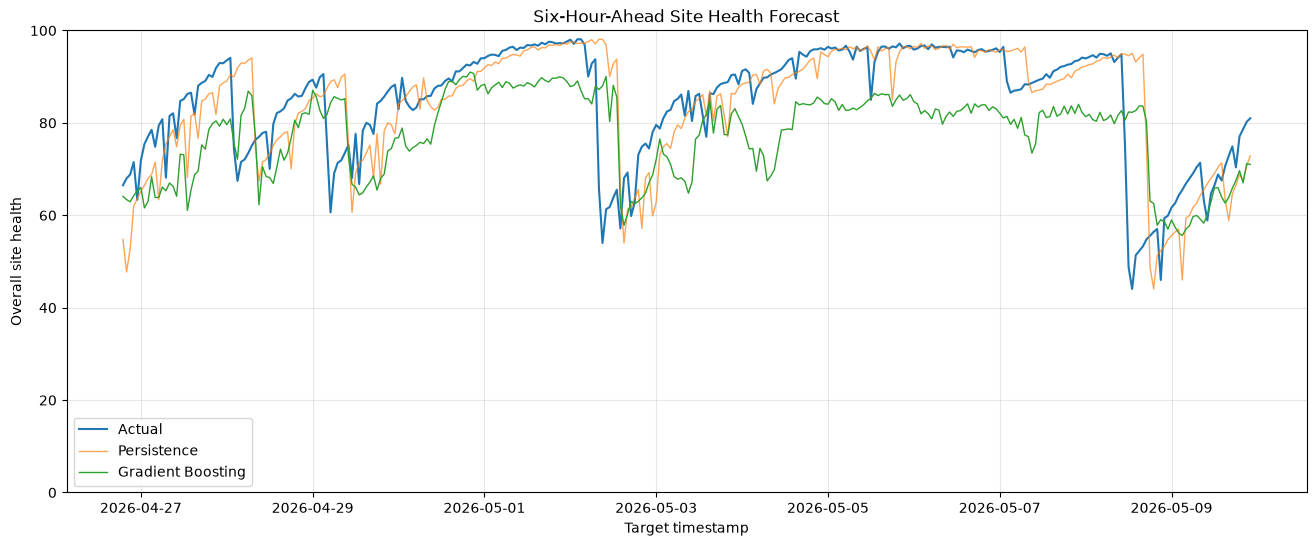

In [88]:
# Actual vs predicted over the test period.
prediction_results = pd.DataFrame(
    {
        "actual_health": y_test,
        "persistence_prediction": test_persistence,
        "gradient_boosting_prediction": gb_test_predictions
    },
    index=y_test.index
)

plt.figure(figsize=(16, 6))

plt.plot(
    prediction_results.index,
    prediction_results["actual_health"],
    label="Actual",
    linewidth=1.5
)

plt.plot(
    prediction_results.index,
    prediction_results["persistence_prediction"],
    label="Persistence",
    linewidth=1,
    alpha=0.7
)

plt.plot(
    prediction_results.index,
    prediction_results["gradient_boosting_prediction"],
    label="Gradient Boosting",
    linewidth=1
)

plt.title("Six-Hour-Ahead Site Health Forecast")
plt.xlabel("Target timestamp")
plt.ylabel("Overall site health")
plt.ylim(0, 100)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [89]:
# The 20 hours the model got most wrong, with the persistence error
# alongside for comparison.
prediction_results["gb_absolute_error"] = np.abs(
    prediction_results["actual_health"]
    - prediction_results["gradient_boosting_prediction"]
)

prediction_results["persistence_absolute_error"] = np.abs(
    prediction_results["actual_health"]
    - prediction_results["persistence_prediction"]
)

largest_errors = (
    prediction_results
    .sort_values(
        "gb_absolute_error",
        ascending=False
    )
    .head(20)
)

display(largest_errors)

,actual_health,persistence_prediction,gradient_boosting_prediction,gb_absolute_error,persistence_absolute_error
timestamp,,,,,
2026-05-08 13:00:00,44.058151,95.059888,82.295549,38.237398,51.001737
2026-05-02 09:00:00,54.000418,98.087039,87.986436,33.986018,44.086621
2026-05-08 12:00:00,48.772410,94.528782,82.361060,33.588650,45.756373
2026-05-08 15:00:00,52.296751,94.103633,83.693535,31.396783,41.806882
2026-05-08 14:00:00,51.357455,93.169931,82.660142,31.302687,41.812476
2026-05-08 16:00:00,53.264356,94.859699,83.635485,30.371129,41.595343
2026-05-02 10:00:00,61.308683,96.929518,90.054283,28.745600,35.620835
2026-05-08 17:00:00,54.796632,75.072722,80.326655,25.530023,20.276090
2026-04-27 13:00:00,86.283701,68.146561,61.059594,25.224106,18.137139


In [90]:
# Are the three splits comparable? If the test period contains far more
# low-health hours than training, poor test scores say more about the
# split than about the model.
def describe_split(name, data, target_col="target_health_6h"):
    return {
        "split": name,
        "rows": len(data),
        "start": data.index.min(),
        "end": data.index.max(),
        "mean": data[target_col].mean(),
        "std": data[target_col].std(),
        "min": data[target_col].min(),
        "median": data[target_col].median(),
        "max": data[target_col].max(),
        "below_60": (data[target_col] < 60).sum(),
        "below_70": (data[target_col] < 70).sum(),
        "below_80": (data[target_col] < 80).sum(),
    }


split_summary = pd.DataFrame([
    describe_split("Train", train_data),
    describe_split("Validation", validation_data),
    describe_split("Test", test_data),
])

display(split_summary)

,split,rows,start,end,mean,std,min,median,max,below_60,below_70,below_80
0,Train,1470,2026-02-11 10:00:00,2026-04-13 15:00:00,84.788442,15.783029,24.475730,92.055907,98.995061,189,271,373
1,Validation,315,2026-04-13 16:00:00,2026-04-26 18:00:00,84.136986,14.959692,39.309455,90.095437,98.583662,34,60,85
2,Test,316,2026-04-26 19:00:00,2026-05-09 22:00:00,84.785484,12.072750,44.058151,88.605663,98.116972,16,46,91


In [91]:
# How often the score actually drops sharply within 6 hours - this is
# the event the classifier below has to learn, and it is rare.
for dataset_name, dataset in [
    ("Train", train_data),
    ("Validation", validation_data),
    ("Test", test_data),
]:
    current = dataset["overall_site_health"]
    future = dataset["target_health_6h"]

    change = future - current

    print(f"\n{dataset_name}")
    print(f"Mean change: {change.mean():.2f}")
    print(f"Minimum change: {change.min():.2f}")
    print(f"Drops larger than 10 points: {(change <= -10).sum()}")
    print(f"Drops larger than 20 points: {(change <= -20).sum()}")
    print(f"Drops larger than 30 points: {(change <= -30).sum()}")


Train
Mean change: -0.07
Minimum change: -53.93
Drops larger than 10 points: 109
Drops larger than 20 points: 39
Drops larger than 30 points: 18

Validation
Mean change: -0.12
Minimum change: -51.97
Drops larger than 10 points: 33
Drops larger than 20 points: 14
Drops larger than 30 points: 10

Test
Mean change: 0.37
Minimum change: -51.00
Drops larger than 10 points: 26
Drops larger than 20 points: 18
Drops larger than 30 points: 8


In [92]:
# ============================================================
# 17. PREDICTING A DROP INSTEAD OF A LEVEL
# Operationally the useful question is not 'what will the score be' but
# 'is it about to fall'. Reframed as a classification of a 10-point
# (major) or 20-point (severe) drop within 6 hours.
# ============================================================
forecast_data["health_change_6h"] = (
    forecast_data["target_health_6h"]
    - forecast_data["overall_site_health"]
)

forecast_data["major_drop_6h"] = np.where(
    forecast_data["health_change_6h"].notna(),
    (
        forecast_data["health_change_6h"] <= -10
    ).astype(int),
    np.nan
)

forecast_data["severe_drop_6h"] = np.where(
    forecast_data["health_change_6h"].notna(),
    (
        forecast_data["health_change_6h"] <= -20
    ).astype(int),
    np.nan
)
for target in ["major_drop_6h", "severe_drop_6h"]:
    counts = forecast_data[target].value_counts(
        dropna=False
    )

    percentages = forecast_data[target].value_counts(
        normalize=True,
        dropna=False
    ) * 100

    print(f"\n{target}")
    print(
        pd.DataFrame({
            "count": counts,
            "percentage": percentages
        })
    )


major_drop_6h
               count  percentage
major_drop_6h                   
0.0             1954   91.694040
1.0              171    8.024402
NaN                6    0.281558

severe_drop_6h
                count  percentage
severe_drop_6h                   
0.0              2054   96.386673
1.0                71    3.331769
NaN                 6    0.281558


In [93]:
# Build the classification dataset and split it chronologically, exactly
# as for the regression.
classification_target = "major_drop_6h"

# NOTE: feature_columns already includes "overall_site_health" -- adding it
# again here used to create a genuine duplicate column (feature_columns +
# ["overall_site_health", ...]), which is exactly the
# "truth value of a Series is ambiguous" failure mode. Deduplicated below.
classification_data = forecast_data[
    list(dict.fromkeys(
        feature_columns + [
            "overall_site_health",
            "health_change_6h",
            classification_target
        ]
    ))
].copy()

classification_data = classification_data.dropna(
    subset=required_features + [classification_target]
)

classification_data[classification_target] = (
    classification_data[classification_target]
    .astype(int)
)
n_rows = len(classification_data)

train_end = int(n_rows * 0.70)
validation_end = int(n_rows * 0.85)

classification_train = classification_data.iloc[
    :train_end
].copy()

classification_validation = classification_data.iloc[
    train_end:validation_end
].copy()

classification_test = classification_data.iloc[
    validation_end:
].copy()


In [94]:
# Feature matrices, with training-median imputation again.
X_train_cls = classification_train[
    feature_columns
].copy()

y_train_cls = classification_train[
    classification_target
].copy()

X_validation_cls = classification_validation[
    feature_columns
].copy()

y_validation_cls = classification_validation[
    classification_target
].copy()

X_test_cls = classification_test[
    feature_columns
].copy()

y_test_cls = classification_test[
    classification_target
].copy()

# Remove duplicate feature names (same fix as before)
feature_columns = list(dict.fromkeys(feature_columns))

classification_medians = X_train_cls.median(numeric_only=True)

valid_classification_features = [
    column
    for column in classification_medians.index
    if pd.notna(classification_medians.loc[column])
]

X_train_cls = (
    X_train_cls[valid_classification_features]
    .fillna(classification_medians)
)

X_validation_cls = (
    X_validation_cls[valid_classification_features]
    .fillna(classification_medians)
)

X_test_cls = (
    X_test_cls[valid_classification_features]
    .fillna(classification_medians)
)

In [95]:
# Classification metrics. Accuracy is deliberately absent: with a rare
# event, always predicting 'no drop' would score ~95% and be useless.
# ROC-AUC and PR-AUC are threshold-free; precision/recall are reported
# at the chosen operating threshold.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
def evaluate_classifier(
    actual,
    probabilities,
    threshold,
    model_name
):
    predicted = (
        np.asarray(probabilities) >= threshold
    ).astype(int)

    actual = np.asarray(actual)

    return {
        "model": model_name,
        "threshold": threshold,
        "precision": precision_score(
            actual,
            predicted,
            zero_division=0
        ),
        "recall": recall_score(
            actual,
            predicted,
            zero_division=0
        ),
        "f1": f1_score(
            actual,
            predicted,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            actual,
            probabilities
        ),
        "pr_auc": average_precision_score(
            actual,
            probabilities
        ),
        "predicted_alerts": predicted.sum(),
        "actual_events": actual.sum()
    }

In [96]:
# Logistic regression needs standardised inputs; the scaler is fitted on
# training data only.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_cls_scaled = scaler.fit_transform(
    X_train_cls
)

X_validation_cls_scaled = scaler.transform(
    X_validation_cls
)

X_test_cls_scaled = scaler.transform(
    X_test_cls
)

In [97]:
# class_weight='balanced' compensates for how rare drops are, otherwise
# the model learns to always answer 'no'.
logistic_classifier = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    C=0.1,
    random_state=42
)

logistic_classifier.fit(
    X_train_cls_scaled,
    y_train_cls
)

logistic_validation_probabilities = (
    logistic_classifier.predict_proba(
        X_validation_cls_scaled
    )[:, 1]
)

logistic_test_probabilities = (
    logistic_classifier.predict_proba(
        X_test_cls_scaled
    )[:, 1]
)

In [98]:
# The decision threshold is a business choice, not a model output: sweep
# it on VALIDATION to trade false alarms against missed drops.
threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    result = evaluate_classifier(
        y_validation_cls,
        logistic_validation_probabilities,
        threshold,
        "Logistic Regression"
    )

    threshold_results.append(result)

threshold_table = pd.DataFrame(
    threshold_results
)

display(
    threshold_table.sort_values(
        ["f1", "recall"],
        ascending=False
    )
)

,model,threshold,precision,recall,f1,roc_auc,pr_auc,predicted_alerts,actual_events
7,Logistic Regression,0.45,0.232558,0.606061,0.336134,0.747045,0.248453,86,33
9,Logistic Regression,0.55,0.246377,0.515152,0.333333,0.747045,0.248453,69,33
10,Logistic Regression,0.60,0.263158,0.454545,0.333333,0.747045,0.248453,57,33
8,Logistic Regression,0.50,0.236842,0.545455,0.330275,0.747045,0.248453,76,33
6,Logistic Regression,0.40,0.222222,0.606061,0.325203,0.747045,0.248453,90,33
12,Logistic Regression,0.70,0.289474,0.333333,0.309859,0.747045,0.248453,38,33
11,Logistic Regression,0.65,0.255319,0.363636,0.300000,0.747045,0.248453,47,33
4,Logistic Regression,0.30,0.184000,0.696970,0.291139,0.747045,0.248453,125,33
5,Logistic Regression,0.35,0.190476,0.606061,0.289855,0.747045,0.248453,105,33
14,Logistic Regression,0.80,0.347826,0.242424,0.285714,0.747045,0.248453,23,33


In [99]:
# Keep the best-F1 threshold from validation, and only then touch the test set.
best_threshold_row = (
    threshold_table
    .sort_values(
        ["f1", "recall"],
        ascending=False
    )
    .iloc[0]
)

best_threshold = float(
    best_threshold_row["threshold"]
)

print(
    "Selected validation threshold:",
    best_threshold
)

Selected validation threshold: 0.45000000000000007


In [100]:
# Test performance of the logistic model at that threshold.
logistic_test_results = evaluate_classifier(
    y_test_cls,
    logistic_test_probabilities,
    best_threshold,
    "Logistic Regression"
)

display(
    pd.DataFrame([logistic_test_results])
)

,model,threshold,precision,recall,f1,roc_auc,pr_auc,predicted_alerts,actual_events
0,Logistic Regression,0.45,0.043011,0.153846,0.067227,0.53634,0.084229,93,26


In [101]:
# Second classifier, with its own threshold sweep on validation.
rf_classifier = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(
    X_train_cls,
    y_train_cls
)

rf_validation_probabilities = (
    rf_classifier.predict_proba(
        X_validation_cls
    )[:, 1]
)

rf_test_probabilities = (
    rf_classifier.predict_proba(
        X_test_cls
    )[:, 1]
)

rf_threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    rf_threshold_results.append(
        evaluate_classifier(
            y_validation_cls,
            rf_validation_probabilities,
            threshold,
            "Random Forest Classifier"
        )
    )

rf_threshold_table = pd.DataFrame(
    rf_threshold_results
)

display(
    rf_threshold_table.sort_values(
        ["f1", "recall"],
        ascending=False
    )
)

rf_best_threshold = float(
    rf_threshold_table
    .sort_values(
        ["f1", "recall"],
        ascending=False
    )
    .iloc[0]["threshold"]
)

,model,threshold,precision,recall,f1,roc_auc,pr_auc,predicted_alerts,actual_events
1,Random Forest Classifier,0.15,0.142012,0.727273,0.237624,0.667526,0.197816,169,33
4,Random Forest Classifier,0.30,0.204545,0.272727,0.233766,0.667526,0.197816,44,33
2,Random Forest Classifier,0.20,0.150442,0.515152,0.232877,0.667526,0.197816,113,33
0,Random Forest Classifier,0.10,0.128514,0.969697,0.226950,0.667526,0.197816,249,33
3,Random Forest Classifier,0.25,0.153846,0.363636,0.216216,0.667526,0.197816,78,33
5,Random Forest Classifier,0.35,0.333333,0.151515,0.208333,0.667526,0.197816,15,33
6,Random Forest Classifier,0.40,0.333333,0.030303,0.055556,0.667526,0.197816,3,33
7,Random Forest Classifier,0.45,0.000000,0.000000,0.000000,0.667526,0.197816,1,33
8,Random Forest Classifier,0.50,0.000000,0.000000,0.000000,0.667526,0.197816,1,33
9,Random Forest Classifier,0.55,0.000000,0.000000,0.000000,0.667526,0.197816,0,33


In [102]:
# The two classifiers side by side on test.
rf_classifier_test_results = evaluate_classifier(
    y_test_cls,
    rf_test_probabilities,
    rf_best_threshold,
    "Random Forest Classifier"
)

classifier_comparison = pd.DataFrame([
    logistic_test_results,
    rf_classifier_test_results
]).sort_values("f1", ascending=False)

display(classifier_comparison)

,model,threshold,precision,recall,f1,roc_auc,pr_auc,predicted_alerts,actual_events
1,Random Forest Classifier,0.15,0.114754,0.807692,0.200957,0.555172,0.086787,183,26
0,Logistic Regression,0.45,0.043011,0.153846,0.067227,0.536340,0.084229,93,26


In [103]:
# What do the severe drops look like? And how do the hours preceding a
# major drop differ on average from stable hours - the 'difference'
# column ranks the most discriminating signals.
drop_analysis_columns = [
    "overall_site_health",
    "target_health_6h",
    "health_change_6h",
    "environmental_health_score",
    "energy_health_score",
    "battery_health_score",
    "overall_site_health_trend_24h",
    "overall_site_health_volatility_24h",
    "environmental_anomaly_burden",
    "energy_anomaly_burden",
    "battery_anomaly_burden",
    "outage_duration_hours",
    "battery_alarm_duration_hours",
    "temperature",
    "humidity"
]

drop_analysis_columns = [
    column
    for column in drop_analysis_columns
    if column in forecast_data.columns
]

severe_test_drops = (
    forecast_data.loc[classification_test.index]
    .query("health_change_6h <= -20")
    [drop_analysis_columns]
    .sort_values("health_change_6h")
)

display(severe_test_drops) 

comparison_data = (
    forecast_data.loc[classification_test.index]
    .copy()
)

comparison_data["drop_group"] = np.where(
    comparison_data["health_change_6h"] <= -10,
    "Major drop",
    "Stable/no major drop"
)

numeric_comparison_columns = [
    column
    for column in drop_analysis_columns
    if column not in [
        "target_health_6h",
        "health_change_6h"
    ]
]

group_comparison = (
    comparison_data
    .groupby("drop_group")[
        numeric_comparison_columns
    ]
    .mean()
    .T
)

group_comparison["difference"] = (
    group_comparison.get("Major drop")
    - group_comparison.get("Stable/no major drop")
)

display(
    group_comparison.sort_values(
        "difference",
        key=lambda values: values.abs(),
        ascending=False
    )
)

,overall_site_health,target_health_6h,health_change_6h,environmental_health_score,energy_health_score,battery_health_score,overall_site_health_trend_24h,overall_site_health_volatility_24h,environmental_anomaly_burden,energy_anomaly_burden,battery_anomaly_burden,outage_duration_hours,battery_alarm_duration_hours,temperature,humidity
timestamp,,,,,,,,,,,,,,,
2026-05-08 13:00:00,95.059888,44.058151,-51.001737,89.317221,95.043809,99.998253,6.683079,2.245590,0.000000,0.015266,0.000015,0,0,23.858333,38.908333
2026-05-08 12:00:00,94.528782,48.772410,-45.756373,88.023444,94.635473,99.998095,7.233272,2.302021,0.000000,0.016589,0.000016,0,0,23.900000,39.183333
2026-05-02 09:00:00,98.087039,54.000418,-44.086621,95.131253,98.824452,99.883158,3.363322,0.869733,0.000000,0.003294,0.000213,0,0,23.278571,43.192857
2026-05-08 14:00:00,93.169931,51.357455,-41.812476,82.573906,95.423772,99.998398,4.879720,2.081762,0.000000,0.014044,0.000013,0,0,23.870000,38.583333
2026-05-08 15:00:00,94.103633,52.296751,-41.806882,85.274089,95.776916,99.998531,5.456153,1.935233,0.000000,0.012917,0.000012,0,0,24.105556,37.783333
2026-05-08 16:00:00,94.859699,53.264356,-41.595343,87.411665,96.104776,99.998652,5.863402,1.809426,0.000000,0.011877,0.000011,0,0,24.070833,38.216667
2026-05-02 10:00:00,96.929518,61.308683,-35.620835,91.149199,98.920767,99.892828,2.475715,0.705328,0.000000,0.003022,0.000196,0,0,23.210345,42.993103
2026-05-02 08:00:00,98.116972,65.821249,-32.295723,95.365569,98.719673,99.872616,3.329630,0.929469,0.000000,0.003590,0.000233,0,0,23.357143,43.307143
2026-05-02 12:00:00,92.852293,63.800466,-29.051827,93.563096,87.673940,97.421387,-2.952283,1.743924,0.000000,0.088497,0.039231,0,0,23.162069,42.975862


drop_group,Major drop,Stable/no major drop,difference
energy_health_score,88.543162,75.602983,12.940179
battery_health_score,96.703662,87.231545,9.472118
overall_site_health,92.159453,83.723335,8.436118
overall_site_health_trend_24h,7.013134,0.085451,6.927683
overall_site_health_volatility_24h,4.284701,6.543620,-2.258919
environmental_health_score,91.076880,89.104167,1.972713
temperature,23.596872,23.959827,-0.362955
humidity,41.553483,41.308989,0.244494
energy_anomaly_burden,0.040509,0.100325,-0.059817
battery_alarm_duration_hours,0.038462,0.079310,-0.040849


In [104]:
# Existence check on the three derived columns (no output beyond the last).
forecast_data["health_change_6h"]
forecast_data["major_drop_6h"]
forecast_data["severe_drop_6h"]

timestamp
2026-02-10 10:00:00    0.0
2026-02-10 11:00:00    0.0
2026-02-10 12:00:00    0.0
2026-02-10 13:00:00    0.0
2026-02-10 14:00:00    0.0
                      ... 
2026-05-10 00:00:00    NaN
2026-05-10 01:00:00    NaN
2026-05-10 02:00:00    NaN
2026-05-10 03:00:00    NaN
2026-05-10 04:00:00    NaN
Freq: h, Name: severe_drop_6h, Length: 2131, dtype: float64

<Figure size 1200x500 with 0 Axes>

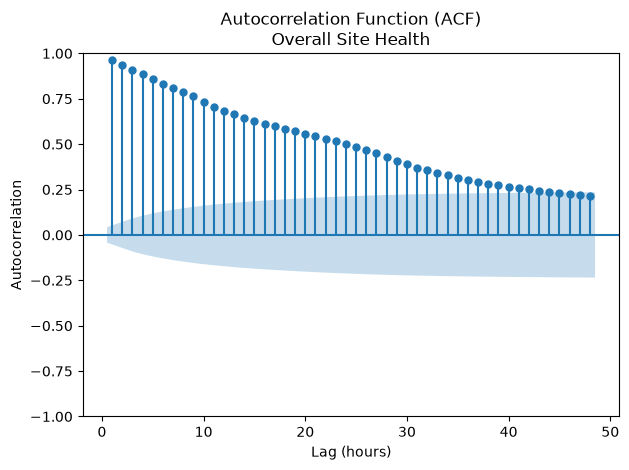

In [105]:
# ============================================================
# 18. HOW FAR BACK DOES THE SCORE REMEMBER?
# ============================================================
# The autocorrelation function shows how strongly the score is still
# related to itself N hours earlier - i.e. how many lags are worth
# feeding to the models.
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

health_series = (
    forecast_data["overall_site_health"]
    .dropna()
)

plt.figure(figsize=(12, 5))

plot_acf(
    health_series,
    lags=48,
    alpha=0.05,
    zero=False
)

plt.title("Autocorrelation Function (ACF)\nOverall Site Health")
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

### Extended ACF + PACF -- Locating the Actual Memory Cutoff

The ACF above was cut off at lag 48 and hadn't decayed into the confidence
band yet, so that plot alone couldn't say how far back `overall_site_health`
actually carries memory. This extends the lag range far enough to find that
point, adds a PACF (which should show a sharp cutoff at the true AR order
for a stationary process, unlike ACF's gradual decay), and checks the
`HEALTH_LAGS` feature list already chosen above against what the data
actually supports.


In [106]:
# ACF and PACF over two weeks of lags, with the first statistically
# insignificant lag of each extracted automatically.
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 2 weeks of hourly lags -- comfortably under the ~N/4 rule of thumb for a
# ~2100-row series, and far enough to have a real chance of seeing ACF decay
# into its confidence band.
EXTENDED_LAGS = 336

acf_values, acf_confint = acf(
    health_series, nlags=EXTENDED_LAGS, alpha=0.05, fft=True
)

pacf_values, pacf_confint = pacf(
    health_series, nlags=EXTENDED_LAGS, alpha=0.05, method="ywm"
)


def first_insignificant_lag(values, confint):
    """First lag (skipping lag 0) whose value falls inside its own 95%
    confidence band -- i.e. no longer statistically distinguishable from
    zero. Returns None if every lag checked remains significant.
    """
    lower = confint[:, 0] - values
    upper = confint[:, 1] - values

    for lag in range(1, len(values)):
        if lower[lag] <= values[lag] <= upper[lag]:
            return lag

    return None


acf_cutoff = first_insignificant_lag(acf_values, acf_confint)
pacf_cutoff = first_insignificant_lag(pacf_values, pacf_confint)

print(f"ACF (lags 1-{EXTENDED_LAGS}): first statistically insignificant lag = {acf_cutoff}")
print(f"PACF (lags 1-{EXTENDED_LAGS}): first statistically insignificant lag = {pacf_cutoff}")


ACF (lags 1-336): first statistically insignificant lag = 45
PACF (lags 1-336): first statistically insignificant lag = 2


<Figure size 1400x500 with 0 Axes>

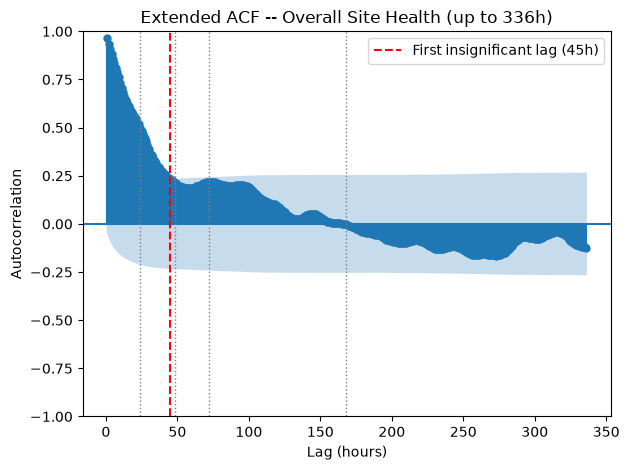

<Figure size 1400x500 with 0 Axes>

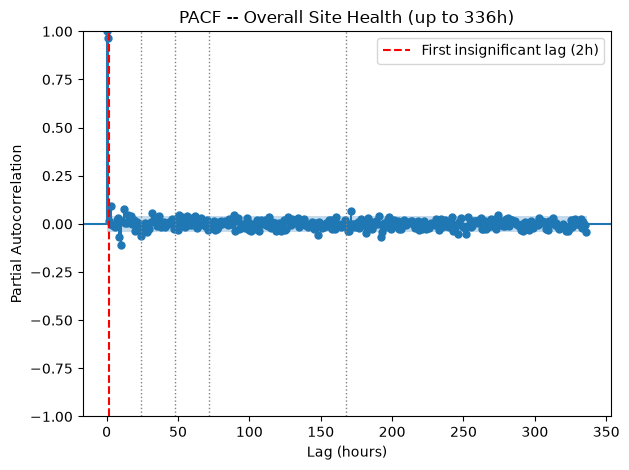

In [107]:
# Both plots, with the usual reference lags and the detected cutoff marked.
REFERENCE_LAGS = {"24h": 24, "48h": 48, "72h": 72, "168h (1wk)": 168}

plt.figure(figsize=(14, 5))
plot_acf(health_series, lags=EXTENDED_LAGS, alpha=0.05, zero=False)

for label, lag in REFERENCE_LAGS.items():
    if lag <= EXTENDED_LAGS:
        plt.axvline(lag, color="gray", linestyle=":", linewidth=1)

if acf_cutoff:
    plt.axvline(
        acf_cutoff, color="red", linestyle="--", linewidth=1.5,
        label=f"First insignificant lag ({acf_cutoff}h)"
    )
    plt.legend()

plt.title(f"Extended ACF -- Overall Site Health (up to {EXTENDED_LAGS}h)")
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plot_pacf(health_series, lags=EXTENDED_LAGS, alpha=0.05, method="ywm")

for label, lag in REFERENCE_LAGS.items():
    if lag <= EXTENDED_LAGS:
        plt.axvline(lag, color="gray", linestyle=":", linewidth=1)

if pacf_cutoff:
    plt.axvline(
        pacf_cutoff, color="red", linestyle="--", linewidth=1.5,
        label=f"First insignificant lag ({pacf_cutoff}h)"
    )
    plt.legend()

plt.title(f"PACF -- Overall Site Health (up to {EXTENDED_LAGS}h)")
plt.xlabel("Lag (hours)")
plt.ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.show()


In [108]:
# Turn the two cutoffs into a recommendation, and audit the HEALTH_LAGS
# list already in use against what the data actually supports.
print("=== Suggested prior / lookback range for forecasting overall_site_health ===\n")

if acf_cutoff:
    print(f"ACF stays significant through lag {acf_cutoff - 1}h "
          f"(first insignificant at {acf_cutoff}h).")
else:
    print(f"ACF is still significant at every lag checked (up to {EXTENDED_LAGS}h) -- "
          f"this series has memory beyond what was tested here, or is non-stationary.")

if pacf_cutoff:
    print(f"PACF stays significant through lag {pacf_cutoff - 1}h "
          f"(first insignificant at {pacf_cutoff}h) -- "
          f"this is the more relevant number for an AR-order-style prior, "
          f"since ACF's gradual decay alone doesn't localise direct dependence.")
else:
    print(f"PACF is still significant at every lag checked (up to {EXTENDED_LAGS}h).")

print()
print("Recommendation:")
if pacf_cutoff:
    print(f" - Primary/high-value lookback window: 1-{pacf_cutoff - 1}h "
          f"(PACF-significant lags -- direct, non-redundant predictive signal).")
if acf_cutoff:
    print(f" - Full memory range worth retaining as engineered features: "
          f"1-{acf_cutoff - 1}h (ACF-significant lags).")

print()
print("Caveat: a slow, non-decaying ACF combined with PACF cutting off sharply at a low")
print("lag (e.g. 1-2h) is the classic signature of a near-unit-root / highly persistent")
print("series rather than genuine long memory -- consistent with overall_site_health being")
print("built partly from a 6h rolling smooth and slow-moving PM-risk ramps. If PACF cuts")
print("off early, don't read the long ACF tail as \"368h of real signal\"; it likely reflects")
print("trend/persistence that a differenced series or an explicit trend term would absorb.")

print()
print("Cross-check against the HEALTH_LAGS feature list already built above:")
for lag in HEALTH_LAGS:
    if acf_cutoff and lag >= acf_cutoff:
        status = "beyond the ACF-significant range -- likely redundant/noisy as a feature"
    elif pacf_cutoff and lag >= pacf_cutoff:
        status = "within ACF-significant range but beyond PACF cutoff -- probably adds little beyond shorter lags"
    else:
        status = "within the PACF-significant range -- well-supported"
    print(f"  lag {lag:>3}h: {status}")


=== Suggested prior / lookback range for forecasting overall_site_health ===

ACF stays significant through lag 44h (first insignificant at 45h).
PACF stays significant through lag 1h (first insignificant at 2h) -- this is the more relevant number for an AR-order-style prior, since ACF's gradual decay alone doesn't localise direct dependence.

Recommendation:
 - Primary/high-value lookback window: 1-1h (PACF-significant lags -- direct, non-redundant predictive signal).
 - Full memory range worth retaining as engineered features: 1-44h (ACF-significant lags).

Caveat: a slow, non-decaying ACF combined with PACF cutting off sharply at a low
lag (e.g. 1-2h) is the classic signature of a near-unit-root / highly persistent
series rather than genuine long memory -- consistent with overall_site_health being
built partly from a 6h rolling smooth and slow-moving PM-risk ramps. If PACF cuts
off early, don't read the long ACF tail as "368h of real signal"; it likely reflects
trend/persistence tha

## Delta Forecasting, Dynamic Features & Persistence-Error Modeling

The persistence baseline is hard to beat because `overall_site_health` behaves
like an AR(1) process: PACF is dominated by lag 1, while ACF stays
significant out to ~40-45h purely as the compounding echo of that single
lag (see the extended ACF/PACF analysis above). Three approaches follow,
each in its own clearly-labelled section, none of which touch the existing
models or results above:

1. **Delta forecasting** -- predict the 6h *change* instead of the absolute
   level, then reconstruct the absolute forecast.
2. **Dynamic time-series features** -- lags, changes, rates, rolling
   statistics/slopes, acceleration, consecutive-deterioration streaks, and
   cross-subsystem interactions, built automatically from whatever source
   columns exist.
3. **Persistence-error model** -- predict *when* persistence is likely to
   fail badly, and only override it with a model forecast in those hours
   (a hybrid forecast).

Only past and current information is used throughout: lags/diffs only ever
shift backward, and rolling windows include the current row (the forecast
origin) but never a future one.


In [109]:
# Guard: every column derived from the future is listed by name here, so
# the feature builders below can exclude them explicitly rather than by
# hoping nobody adds one by accident.
TARGET_AND_LABEL_COLUMNS = {
    "target_health_6h", "target_health_change_6h", "health_change_6h",
    "major_drop_6h", "severe_drop_6h", "persistence_error_6h",
    "absolute_persistence_error_6h", "persistence_failure_6h",
    "persistence_prediction_6h"
}

# Guard against duplicate columns before doing anything else -- this is the
# exact failure mode ("truth value of a Series is ambiguous") the rest of
# this section is careful to avoid.
_duplicate_columns = forecast_data.columns[forecast_data.columns.duplicated()].tolist()
if _duplicate_columns:
    print(f"Dropping {len(_duplicate_columns)} duplicate-named columns: {_duplicate_columns}")
    forecast_data = forecast_data.loc[:, ~forecast_data.columns.duplicated(keep="last")].copy()
else:
    print("No duplicate columns in forecast_data.")


No duplicate columns in forecast_data.


### Step 1 -- Delta Forecasting Model

Predict `target_health_change_6h = target_health_6h - overall_site_health`
instead of the absolute level, then reconstruct
`predicted_health_6h = current_health + predicted_change` (clipped to
0-100). Persistence in delta-space is simply `predicted_change = 0`. Uses
the same basic feature set as the existing absolute-health models, on a
fresh chronological 70/15/15 split (never shuffled, training-median
imputation only).


In [110]:
# Delta target: the CHANGE over 6 hours rather than the level. Predicting
# a change centred on zero is an easier and more honest problem than
# re-predicting a level the model can mostly copy from the current hour.
# The assert proves the reconstruction is exact.
forecast_data["target_health_change_6h"] = (
    forecast_data["target_health_6h"] - forecast_data["overall_site_health"]
)

_check = forecast_data[
    ["overall_site_health", "target_health_6h", "target_health_change_6h"]
].dropna().head(5)
_reconstructed = _check["overall_site_health"] + _check["target_health_change_6h"]
assert (_reconstructed - _check["target_health_6h"]).abs().max() < 1e-9
print("[OK] target_health_change_6h reconstructs target_health_6h exactly.")


def reconstruct_health_from_delta(current_health, predicted_delta):
    """current_health + predicted_delta, clipped to [0, 100]."""
    return np.clip(np.asarray(current_health) + np.asarray(predicted_delta), 0, 100)


[OK] target_health_change_6h reconstructs target_health_6h exactly.


In [111]:
# Same basic feature set as the existing absolute-health models -- an
# apples-to-apples "does predicting delta beat predicting the level" test.
delta_basic_feature_columns = list(feature_columns)

delta_model_data_columns = list(dict.fromkeys(
    delta_basic_feature_columns + ["overall_site_health", "target_health_6h", "target_health_change_6h"]
))
assert len(delta_model_data_columns) == len(set(delta_model_data_columns))

delta_model_data = forecast_data[delta_model_data_columns].copy()
delta_model_data = delta_model_data.dropna(subset=required_features + ["target_health_change_6h"])

n_rows_delta = len(delta_model_data)
train_end_delta = int(n_rows_delta * 0.70)
validation_end_delta = int(n_rows_delta * 0.85)

delta_train_data = delta_model_data.iloc[:train_end_delta].copy()
delta_validation_data = delta_model_data.iloc[train_end_delta:validation_end_delta].copy()
delta_test_data = delta_model_data.iloc[validation_end_delta:].copy()

assert delta_train_data.index.max() < delta_validation_data.index.min()
assert delta_validation_data.index.max() < delta_test_data.index.min()
print("Delta chronological split:", len(delta_train_data), len(delta_validation_data), len(delta_test_data))

X_train_delta = delta_train_data[delta_basic_feature_columns].copy()
y_train_delta = delta_train_data["target_health_change_6h"].copy()
X_validation_delta = delta_validation_data[delta_basic_feature_columns].copy()
y_validation_delta = delta_validation_data["target_health_change_6h"].copy()
X_test_delta = delta_test_data[delta_basic_feature_columns].copy()
y_test_delta = delta_test_data["target_health_change_6h"].copy()

delta_training_medians = X_train_delta.median()
X_train_delta = X_train_delta.fillna(delta_training_medians)
X_validation_delta = X_validation_delta.fillna(delta_training_medians)
X_test_delta = X_test_delta.fillna(delta_training_medians)

delta_valid_features = [c for c in delta_basic_feature_columns if not pd.isna(delta_training_medians[c])]
X_train_delta = X_train_delta[delta_valid_features]
X_validation_delta = X_validation_delta[delta_valid_features]
X_test_delta = X_test_delta[delta_valid_features]
delta_basic_feature_columns = delta_valid_features

assert X_train_delta.isna().sum().sum() == 0
assert X_test_delta.isna().sum().sum() == 0
assert not np.isinf(X_train_delta.to_numpy()).any()
print(f"Delta feature matrix: {X_train_delta.shape} train, {X_test_delta.shape} test -- no NaN/inf.")


Delta chronological split: 1470 315 316
Delta feature matrix: (1470, 84) train, (316, 84) test -- no NaN/inf.


In [112]:
# Evaluate delta models on both scales: the reconstructed absolute score
# (comparable with the earlier models) and the raw change itself, where
# persistence corresponds to always predicting 0.
def evaluate_delta_forecast(current_health, actual_future_health, predicted_delta, model_name):
    """Evaluate a delta model on both the reconstructed absolute forecast
    and the raw delta prediction itself.
    """
    predicted_future_health = reconstruct_health_from_delta(current_health, predicted_delta)
    actual_future_health = np.asarray(actual_future_health)
    actual_delta = actual_future_health - np.asarray(current_health)
    predicted_delta = np.asarray(predicted_delta)

    result = evaluate_forecast(actual_future_health, predicted_future_health, model_name)
    result["delta_MAE"] = mean_absolute_error(actual_delta, predicted_delta)
    result["delta_RMSE"] = np.sqrt(mean_squared_error(actual_delta, predicted_delta))
    result["delta_R2"] = r2_score(actual_delta, predicted_delta)
    return result


persistence_delta_test_results = evaluate_delta_forecast(
    delta_test_data["overall_site_health"], delta_test_data["target_health_6h"],
    np.zeros(len(delta_test_data)), "Persistence (delta=0)"
)

delta_linear_model = LinearRegression().fit(X_train_delta, y_train_delta)
delta_rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=3, max_features=0.7,
    random_state=42, n_jobs=-1
).fit(X_train_delta, y_train_delta)
delta_gb_model = HistGradientBoostingRegressor(
    learning_rate=0.05, max_iter=300, max_leaf_nodes=20, min_samples_leaf=15,
    l2_regularization=1.0, random_state=42
).fit(X_train_delta, y_train_delta)

delta_linear_results = evaluate_delta_forecast(
    delta_test_data["overall_site_health"], delta_test_data["target_health_6h"],
    delta_linear_model.predict(X_test_delta), "Delta Linear Regression"
)
delta_rf_results = evaluate_delta_forecast(
    delta_test_data["overall_site_health"], delta_test_data["target_health_6h"],
    delta_rf_model.predict(X_test_delta), "Delta Random Forest"
)
delta_gb_results = evaluate_delta_forecast(
    delta_test_data["overall_site_health"], delta_test_data["target_health_6h"],
    delta_gb_model.predict(X_test_delta), "Delta Hist Gradient Boosting"
)

delta_persistence_mae = persistence_delta_test_results["MAE"]

delta_model_comparison = pd.DataFrame([
    persistence_delta_test_results, delta_linear_results, delta_rf_results, delta_gb_results
])
delta_model_comparison["MAE_improvement_vs_persistence"] = (
    delta_persistence_mae - delta_model_comparison["MAE"]
)
delta_model_comparison["MAE_improvement_percent"] = (
    delta_model_comparison["MAE_improvement_vs_persistence"] / delta_persistence_mae * 100
)
delta_model_comparison = delta_model_comparison.sort_values("MAE").reset_index(drop=True)

display(delta_model_comparison[[
    "model", "MAE", "RMSE", "R2", "predicted_min", "predicted_max",
    "MAE_improvement_vs_persistence", "MAE_improvement_percent",
    "delta_MAE", "delta_RMSE", "delta_R2"
]])


,model,MAE,RMSE,R2,predicted_min,predicted_max,MAE_improvement_vs_persistence,MAE_improvement_percent,delta_MAE,delta_RMSE,delta_R2
0,Persistence (delta=0),6.004433,10.028986,0.307726,44.058151,98.116972,0.000000,0.000000,6.004433,10.028986,-0.001349
1,Delta Linear Regression,6.177677,9.642709,0.360026,59.373812,99.521000,-0.173245,-2.885282,6.177677,9.642709,0.074302
2,Delta Hist Gradient Boosting,9.196280,11.016336,0.164708,48.468658,93.414181,-3.191847,-53.158185,9.196280,11.016336,-0.208219
3,Delta Random Forest,12.601196,14.488293,-0.444769,46.790222,89.783351,-6.596764,-109.864899,12.601196,14.488293,-1.089804


### Step 2 -- Dynamic Time-Series Features

Builds lag / change / rate / rolling-statistic / rolling-slope /
acceleration / consecutive-deterioration / cross-subsystem-interaction
features from every numeric health, risk, anomaly, PM, environmental, and
alarm-duration source column that actually exists in `forecast_data`
(several from the requested list don't exist here and are skipped
automatically). Calendar features already exist upstream and are reused by
reference, tracked as their own group for feature-importance reporting.

**Rolling-window convention**: every rolling statistic (mean/std/min/max/
range/slope) uses `.rolling(window, min_periods=window)` directly on the
untouched series -- the current row (the forecast origin) IS included,
since at prediction time the current hour's value is already known. Lags
and diffs only ever shift/diff backward (positive periods), so nothing here
can see a future row.


In [113]:
# ============================================================
# 19. EXPANDED DYNAMIC FEATURE SET
# ============================================================
# For every source series, build the same family of descriptors: lags,
# changes, rates, rolling statistics, rolling slopes and acceleration.
# Sources that do not exist in this dataset are skipped automatically.
DYNAMIC_SOURCE_VARIABLES = [
    "overall_site_health", "environmental_health_score", "energy_health_score", "battery_health_score",
    "environmental_risk_score", "energy_risk_score", "energy_risk_score_calibrated", "battery_risk_score",
    "environmental_base_risk", "energy_base_risk", "battery_base_risk",
    "environmental_anomaly_burden", "energy_anomaly_burden", "battery_anomaly_burden",
    "environmental_pm_risk", "energy_pm_risk", "battery_pm_risk",
    "temperature", "humidity",
    "alarm_count", "hourly_alarm_count", "unique_alarm_count",
    "outage_duration_hours", "energy_alarm_duration_hours", "battery_alarm_duration_hours",
    "overall_site_health_volatility_24h", "overall_site_health_trend_24h"
]

available_dynamic_sources = [c for c in DYNAMIC_SOURCE_VARIABLES if c in forecast_data.columns]
missing_dynamic_sources = [c for c in DYNAMIC_SOURCE_VARIABLES if c not in forecast_data.columns]

print("Available dynamic source variables:", available_dynamic_sources)
print("Missing (skipped) source variables:", missing_dynamic_sources)

LAG_HOURS = [1, 2, 3, 6, 12, 24, 48]
CHANGE_HOURS = [1, 2, 3, 6, 12, 24]
RATE_HOURS = [3, 6, 12, 24]
ROLLING_WINDOWS = [3, 6, 12, 24]
SLOPE_WINDOWS = [3, 6, 12, 24]
ACCELERATION_HOURS = [1, 3, 6]


def rolling_slope(series, window):
    """Slope (units per hour) of a linear fit over a trailing window that
    INCLUDES the current row -- fast closed-form OLS for evenly-spaced x,
    rather than a slower per-window np.polyfit call.
    """
    x = np.arange(window, dtype=float)
    x_mean = x.mean()
    denom = ((x - x_mean) ** 2).sum()

    def _slope(y):
        y_mean = y.mean()
        return float(((x - x_mean) * (y - y_mean)).sum() / denom)

    return series.rolling(window, min_periods=window).apply(_slope, raw=True)


def build_dynamic_features(source_series, prefix, new_columns):
    """Populate `new_columns` (name -> Series) with lag / change / rate /
    rolling-stat / rolling-slope / acceleration features from
    `source_series`. See the markdown above for the rolling-window
    inclusion convention.
    """
    for lag in LAG_HOURS:
        new_columns[f"{prefix}_lag_{lag}h"] = source_series.shift(lag)

    for period in CHANGE_HOURS:
        new_columns[f"{prefix}_change_{period}h"] = source_series.diff(period)

    for period in RATE_HOURS:
        new_columns[f"{prefix}_rate_{period}h"] = source_series.diff(period) / period

    for window in ROLLING_WINDOWS:
        rolling = source_series.rolling(window, min_periods=window)
        rolling_min = rolling.min()
        rolling_max = rolling.max()
        new_columns[f"{prefix}_rollmean_{window}h"] = rolling.mean()
        new_columns[f"{prefix}_rollstd_{window}h"] = rolling.std()
        new_columns[f"{prefix}_rollmin_{window}h"] = rolling_min
        new_columns[f"{prefix}_rollmax_{window}h"] = rolling_max
        new_columns[f"{prefix}_rollrange_{window}h"] = rolling_max - rolling_min

    for window in SLOPE_WINDOWS:
        new_columns[f"{prefix}_slope_{window}h"] = rolling_slope(source_series, window)

    for period in ACCELERATION_HOURS:
        new_columns[f"{prefix}_accel_{period}h"] = source_series.diff(period).diff(period)


dynamic_feature_columns_dict = {}

for source_column in available_dynamic_sources:
    build_dynamic_features(forecast_data[source_column], source_column, dynamic_feature_columns_dict)

print(f"Built {len(dynamic_feature_columns_dict)} A-F dynamic features "
      f"across {len(available_dynamic_sources)} source variables.")


Available dynamic source variables: ['overall_site_health', 'environmental_health_score', 'energy_health_score', 'battery_health_score', 'environmental_risk_score', 'energy_risk_score', 'energy_risk_score_calibrated', 'battery_risk_score', 'environmental_base_risk', 'energy_base_risk', 'battery_base_risk', 'environmental_anomaly_burden', 'energy_anomaly_burden', 'battery_anomaly_burden', 'environmental_pm_risk', 'energy_pm_risk', 'battery_pm_risk', 'temperature', 'humidity', 'outage_duration_hours', 'battery_alarm_duration_hours', 'overall_site_health_volatility_24h', 'overall_site_health_trend_24h']
Missing (skipped) source variables: ['alarm_count', 'hourly_alarm_count', 'unique_alarm_count', 'energy_alarm_duration_hours']
Built 1012 A-F dynamic features across 23 source variables.


In [198]:
# G. Consecutive deterioration -- fixed set, not looped over every source
if "overall_site_health" in forecast_data.columns:
    is_declining = (forecast_data["overall_site_health"].diff() < 0).astype(int)
    dynamic_feature_columns_dict["overall_health_consecutive_decline_hours"] = (
        consecutive_run_length(is_declining)
    )

for subsystem_column in ["environmental_health_score", "energy_health_score", "battery_health_score"]:
    if subsystem_column in forecast_data.columns:
        is_declining = (forecast_data[subsystem_column].diff() < 0).astype(int)
        dynamic_feature_columns_dict[f"{subsystem_column}_consecutive_decline_hours"] = (
            consecutive_run_length(is_declining)
        )

for risk_column in ["environmental_risk_score", "energy_risk_score", "battery_risk_score"]:
    if risk_column in forecast_data.columns:
        is_increasing = (forecast_data[risk_column].diff() > 0).astype(int)
        dynamic_feature_columns_dict[f"{risk_column}_consecutive_increase_hours"] = (
            consecutive_run_length(is_increasing)
        )

print("Cumulative feature count after G (consecutive deterioration):", len(dynamic_feature_columns_dict))

# H. Cross-subsystem interactions -- fixed set, created only when their
#    source columns exist
risk_cols = {"environmental": "environmental_risk_score", "energy": "energy_risk_score", "battery": "battery_risk_score"}
health_cols = {"environmental": "environmental_health_score", "energy": "energy_health_score", "battery": "battery_health_score"}
anomaly_cols = {"energy": "energy_anomaly_burden", "battery": "battery_anomaly_burden"}

if risk_cols["energy"] in forecast_data.columns and risk_cols["battery"] in forecast_data.columns:
    dynamic_feature_columns_dict["interaction_energy_battery_risk"] = (
        forecast_data[risk_cols["energy"]] * forecast_data[risk_cols["battery"]]
    )
if risk_cols["environmental"] in forecast_data.columns and risk_cols["energy"] in forecast_data.columns:
    dynamic_feature_columns_dict["interaction_environmental_energy_risk"] = (
        forecast_data[risk_cols["environmental"]] * forecast_data[risk_cols["energy"]]
    )
if risk_cols["environmental"] in forecast_data.columns and risk_cols["battery"] in forecast_data.columns:
    dynamic_feature_columns_dict["interaction_environmental_battery_risk"] = (
        forecast_data[risk_cols["environmental"]] * forecast_data[risk_cols["battery"]]
    )
if anomaly_cols["energy"] in forecast_data.columns and anomaly_cols["battery"] in forecast_data.columns:
    dynamic_feature_columns_dict["interaction_energy_battery_anomaly_burden"] = (
        forecast_data[anomaly_cols["energy"]] * forecast_data[anomaly_cols["battery"]]
    )

available_risk_cols = [c for c in risk_cols.values() if c in forecast_data.columns]
if len(available_risk_cols) >= 2:
    dynamic_feature_columns_dict["max_subsystem_risk"] = forecast_data[available_risk_cols].max(axis=1)

available_health_cols = [c for c in health_cols.values() if c in forecast_data.columns]
if len(available_health_cols) >= 2:
    health_frame = forecast_data[available_health_cols]
    dynamic_feature_columns_dict["min_subsystem_health"] = health_frame.min(axis=1)
    dynamic_feature_columns_dict["subsystem_health_spread"] = health_frame.max(axis=1) - health_frame.min(axis=1)
    dynamic_feature_columns_dict["subsystems_below_80"] = (health_frame < 80).sum(axis=1)
    dynamic_feature_columns_dict["subsystems_below_60"] = (health_frame < 60).sum(axis=1)

print("Cumulative feature count after H (cross-subsystem interactions):", len(dynamic_feature_columns_dict))

# I. Calendar variables already exist upstream; reused by reference and
# tracked as their own group (the ACF showed no strong daily peak, so these
# aren't expected to carry much weight -- kept separate in importance
# reporting rather than mixed into the ranked dynamic features).
CALENDAR_FEATURE_COLUMNS = [
    c for c in ["hour_sin", "hour_cos", "day_of_week_sin", "day_of_week_cos", "is_weekend"]
    if c in forecast_data.columns
]
print("Calendar features (tracked separately):", CALENDAR_FEATURE_COLUMNS)


Cumulative feature count after G (consecutive deterioration): 1028
Cumulative feature count after H (cross-subsystem interactions): 1028
Calendar features (tracked separately): ['hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'is_weekend']


In [115]:
# Assemble the engineered features into one frame and clean it before
# merging: no duplicate names, no infinities, no all-empty columns, and
# never shadowing a real pipeline column.
dynamic_features_frame = pd.DataFrame(dynamic_feature_columns_dict, index=forecast_data.index)

# Remove duplicate column names (defensive).
dynamic_features_frame = dynamic_features_frame.loc[:, ~dynamic_features_frame.columns.duplicated(keep="last")]

# Replace +/-infinity with NaN (rates-of-change and interactions can blow up
# if a denominator-like quantity is ever exactly 0 upstream).
n_inf_before = int(np.isinf(dynamic_features_frame.to_numpy(dtype=float)).sum())
dynamic_features_frame = dynamic_features_frame.replace([np.inf, -np.inf], np.nan)
print(f"Replaced {n_inf_before} +/-inf values with NaN.")

# Entirely-missing engineered features get reported and dropped.
all_nan_columns = dynamic_features_frame.columns[dynamic_features_frame.isna().all()].tolist()
if all_nan_columns:
    print(f"Dropping {len(all_nan_columns)} entirely-missing engineered features: {all_nan_columns}")
    dynamic_features_frame = dynamic_features_frame.drop(columns=all_nan_columns)

# Keep numeric only (should already all be numeric by construction).
numeric_dynamic_columns = [
    c for c in dynamic_features_frame.columns if pd.api.types.is_numeric_dtype(dynamic_features_frame[c])
]
dynamic_features_frame = dynamic_features_frame[numeric_dynamic_columns]

# Merge into forecast_data -- existing columns always win over a
# newly-engineered feature of the same name (purely additive, must never
# shadow a real pipeline column).
colliding_names = [c for c in dynamic_features_frame.columns if c in forecast_data.columns]
if colliding_names:
    print(f"Dropping {len(colliding_names)} engineered features that collide with existing columns "
          f"(existing wins): {colliding_names[:10]}{'...' if len(colliding_names) > 10 else ''}")
    dynamic_features_frame = dynamic_features_frame.drop(columns=colliding_names)

forecast_data = pd.concat([forecast_data, dynamic_features_frame], axis=1)
forecast_data = forecast_data.loc[:, ~forecast_data.columns.duplicated(keep="last")]

expanded_dynamic_feature_columns = [c for c in dynamic_features_frame.columns if c not in TARGET_AND_LABEL_COLUMNS]

print(f"\nTotal engineered dynamic features retained: {len(expanded_dynamic_feature_columns)}")
print(f"forecast_data shape after merge: {forecast_data.shape}")


Replaced 0 +/-inf values with NaN.
Dropping 12 engineered features that collide with existing columns (existing wins): ['environmental_health_score_lag_1h', 'environmental_health_score_lag_6h', 'environmental_health_score_lag_12h', 'environmental_health_score_lag_24h', 'energy_health_score_lag_1h', 'energy_health_score_lag_6h', 'energy_health_score_lag_12h', 'energy_health_score_lag_24h', 'battery_health_score_lag_1h', 'battery_health_score_lag_6h']...

Total engineered dynamic features retained: 1016
forecast_data shape after merge: (2131, 1171)


Retrain the Step 1 delta models on the expanded feature set, with its own
fresh chronological split (same 70/15/15 rule, training-median imputation,
target/label columns excluded), and compare basic vs. expanded vs.
persistence.


In [116]:
# Retrain the three delta models on the expanded feature set, with its
# own chronological split, and compare basic vs expanded vs persistence.
# More features only help if this table says so.
expanded_feature_columns = list(dict.fromkeys(
    delta_basic_feature_columns + expanded_dynamic_feature_columns + CALENDAR_FEATURE_COLUMNS
))
expanded_feature_columns = [c for c in expanded_feature_columns if c not in TARGET_AND_LABEL_COLUMNS]
assert not (TARGET_AND_LABEL_COLUMNS & set(expanded_feature_columns))
print(f"Expanded feature candidate count: {len(expanded_feature_columns)}")

expanded_model_columns = list(dict.fromkeys(
    expanded_feature_columns + ["overall_site_health", "target_health_6h", "target_health_change_6h"]
))
expanded_model_data = forecast_data[expanded_model_columns].copy()
expanded_model_data = expanded_model_data.dropna(subset=required_features + ["target_health_change_6h"])

n_rows_expanded = len(expanded_model_data)
train_end_expanded = int(n_rows_expanded * 0.70)
validation_end_expanded = int(n_rows_expanded * 0.85)

expanded_train_data = expanded_model_data.iloc[:train_end_expanded].copy()
expanded_validation_data = expanded_model_data.iloc[train_end_expanded:validation_end_expanded].copy()
expanded_test_data = expanded_model_data.iloc[validation_end_expanded:].copy()

assert expanded_train_data.index.max() < expanded_validation_data.index.min()
assert expanded_validation_data.index.max() < expanded_test_data.index.min()
print(f"Expanded chronological split: {len(expanded_train_data)} / {len(expanded_validation_data)} / {len(expanded_test_data)}")

X_train_expanded = expanded_train_data[expanded_feature_columns].copy()
y_train_expanded = expanded_train_data["target_health_change_6h"].copy()
X_validation_expanded = expanded_validation_data[expanded_feature_columns].copy()
y_validation_expanded = expanded_validation_data["target_health_change_6h"].copy()
X_test_expanded = expanded_test_data[expanded_feature_columns].copy()
y_test_expanded = expanded_test_data["target_health_change_6h"].copy()

expanded_training_medians = X_train_expanded.median()
X_train_expanded = X_train_expanded.fillna(expanded_training_medians)
X_validation_expanded = X_validation_expanded.fillna(expanded_training_medians)
X_test_expanded = X_test_expanded.fillna(expanded_training_medians)

expanded_valid_features = [c for c in expanded_feature_columns if not pd.isna(expanded_training_medians[c])]
X_train_expanded = X_train_expanded[expanded_valid_features]
X_validation_expanded = X_validation_expanded[expanded_valid_features]
X_test_expanded = X_test_expanded[expanded_valid_features]
expanded_feature_columns = expanded_valid_features

assert X_train_expanded.isna().sum().sum() == 0
assert X_test_expanded.isna().sum().sum() == 0
assert not np.isinf(X_train_expanded.to_numpy()).any()
print(f"Final expanded feature count: {len(expanded_feature_columns)} | X_train_expanded shape: {X_train_expanded.shape}")

expanded_linear_model = LinearRegression().fit(X_train_expanded, y_train_expanded)
expanded_rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=3, max_features=0.3,
    random_state=42, n_jobs=-1
).fit(X_train_expanded, y_train_expanded)
expanded_gb_model = HistGradientBoostingRegressor(
    learning_rate=0.05, max_iter=300, max_leaf_nodes=20, min_samples_leaf=15,
    l2_regularization=1.0, random_state=42
).fit(X_train_expanded, y_train_expanded)

persistence_expanded_test_results = evaluate_delta_forecast(
    expanded_test_data["overall_site_health"], expanded_test_data["target_health_6h"],
    np.zeros(len(expanded_test_data)), "Persistence (expanded split)"
)
expanded_linear_results = evaluate_delta_forecast(
    expanded_test_data["overall_site_health"], expanded_test_data["target_health_6h"],
    expanded_linear_model.predict(X_test_expanded), "Expanded Linear Regression"
)
expanded_rf_results = evaluate_delta_forecast(
    expanded_test_data["overall_site_health"], expanded_test_data["target_health_6h"],
    expanded_rf_model.predict(X_test_expanded), "Expanded Random Forest"
)
expanded_gb_results = evaluate_delta_forecast(
    expanded_test_data["overall_site_health"], expanded_test_data["target_health_6h"],
    expanded_gb_model.predict(X_test_expanded), "Expanded Hist Gradient Boosting"
)

basic_vs_expanded_comparison = pd.DataFrame([
    persistence_expanded_test_results,
    delta_linear_results, delta_rf_results, delta_gb_results,
    expanded_linear_results, expanded_rf_results, expanded_gb_results
])
basic_vs_expanded_comparison["MAE_improvement_vs_persistence"] = (
    persistence_expanded_test_results["MAE"] - basic_vs_expanded_comparison["MAE"]
)
basic_vs_expanded_comparison["MAE_improvement_percent"] = (
    basic_vs_expanded_comparison["MAE_improvement_vs_persistence"] / persistence_expanded_test_results["MAE"] * 100
)
basic_vs_expanded_comparison = basic_vs_expanded_comparison.sort_values("MAE").reset_index(drop=True)

display(basic_vs_expanded_comparison[[
    "model", "MAE", "RMSE", "R2", "MAE_improvement_percent", "delta_MAE", "delta_R2"
]])


Expanded feature candidate count: 1100
Expanded chronological split: 1470 / 315 / 316
Final expanded feature count: 1100 | X_train_expanded shape: (1470, 1100)


,model,MAE,RMSE,R2,MAE_improvement_percent,delta_MAE,delta_R2
0,Persistence (expanded split),6.004433,10.028986,0.307726,0.000000,6.004433,-0.001349
1,Delta Linear Regression,6.177677,9.642709,0.360026,-2.885282,6.177677,0.074302
2,Expanded Hist Gradient Boosting,6.767945,10.318608,0.267165,-12.715816,6.767945,-0.060018
3,Delta Hist Gradient Boosting,9.196280,11.016336,0.164708,-53.158185,9.196280,-0.208219
4,Expanded Random Forest,9.686557,11.131366,0.147173,-61.323430,9.686557,-0.233582
5,Delta Random Forest,12.601196,14.488293,-0.444769,-109.864899,12.601196,-1.089804
6,Expanded Linear Regression,12.838273,16.578980,-0.891820,-113.813252,17.220596,-3.680012


### Step 3 -- Persistence-Error Model

Rather than forecasting health directly, predict *how wrong persistence is
likely to be* 6 hours out, then only override persistence with a model
forecast when a failure looks likely. Uses the expanded feature set from
Step 2. Threshold tuning happens on validation only; test is touched once,
at the end, for reporting.


In [117]:
# ============================================================
# 20. PREDICTING WHEN PERSISTENCE FAILS
# Persistence is hard to beat on average but fails badly on exactly the
# hours that matter. Instead of replacing it everywhere, learn to spot
# the hours where it is about to be wrong by 10 points or more.
# ============================================================
forecast_data["persistence_prediction_6h"] = forecast_data["overall_site_health"]

forecast_data["persistence_error_6h"] = (
    forecast_data["target_health_6h"] - forecast_data["persistence_prediction_6h"]
)

forecast_data["absolute_persistence_error_6h"] = forecast_data["persistence_error_6h"].abs()

forecast_data["persistence_failure_6h"] = np.where(
    forecast_data["absolute_persistence_error_6h"].notna(),
    (forecast_data["absolute_persistence_error_6h"] >= 10).astype(int),
    np.nan
)

_sanity = forecast_data[
    ["overall_site_health", "target_health_6h", "target_health_change_6h", "persistence_error_6h"]
].dropna()
assert np.allclose(_sanity["persistence_error_6h"], _sanity["target_health_change_6h"])
print("[OK] persistence_error_6h matches target_health_change_6h (same formula, by construction).")

PERSISTENCE_ERROR_FEATURE_SOURCE = list(expanded_feature_columns)

perr_model_columns = list(dict.fromkeys(
    PERSISTENCE_ERROR_FEATURE_SOURCE
    + ["overall_site_health", "target_health_6h", "absolute_persistence_error_6h", "persistence_failure_6h"]
))
perr_data = forecast_data[perr_model_columns].copy()
perr_data = perr_data.dropna(subset=required_features + ["absolute_persistence_error_6h", "persistence_failure_6h"])
perr_data["persistence_failure_6h"] = perr_data["persistence_failure_6h"].astype(int)

n_rows_perr = len(perr_data)
train_end_perr = int(n_rows_perr * 0.70)
validation_end_perr = int(n_rows_perr * 0.85)

perr_train = perr_data.iloc[:train_end_perr].copy()
perr_validation = perr_data.iloc[train_end_perr:validation_end_perr].copy()
perr_test = perr_data.iloc[validation_end_perr:].copy()

assert perr_train.index.max() < perr_validation.index.min()
assert perr_validation.index.max() < perr_test.index.min()
print(f"Persistence-error split: {len(perr_train)} / {len(perr_validation)} / {len(perr_test)}")
print("Positive-class counts (train/val/test):",
      int(perr_train["persistence_failure_6h"].sum()),
      int(perr_validation["persistence_failure_6h"].sum()),
      int(perr_test["persistence_failure_6h"].sum()))

X_train_perr = perr_train[PERSISTENCE_ERROR_FEATURE_SOURCE].copy()
X_validation_perr = perr_validation[PERSISTENCE_ERROR_FEATURE_SOURCE].copy()
X_test_perr = perr_test[PERSISTENCE_ERROR_FEATURE_SOURCE].copy()

perr_training_medians = X_train_perr.median()
X_train_perr = X_train_perr.fillna(perr_training_medians)
X_validation_perr = X_validation_perr.fillna(perr_training_medians)
X_test_perr = X_test_perr.fillna(perr_training_medians)

perr_valid_features = [c for c in PERSISTENCE_ERROR_FEATURE_SOURCE if not pd.isna(perr_training_medians[c])]
X_train_perr = X_train_perr[perr_valid_features]
X_validation_perr = X_validation_perr[perr_valid_features]
X_test_perr = X_test_perr[perr_valid_features]

assert X_train_perr.isna().sum().sum() == 0
assert not np.isinf(X_train_perr.to_numpy()).any()
print(f"Persistence-error feature count: {len(perr_valid_features)}")


[OK] persistence_error_6h matches target_health_change_6h (same formula, by construction).
Persistence-error split: 1470 / 315 / 316
Positive-class counts (train/val/test): 192 55 47
Persistence-error feature count: 1100


**A. Regression**: how large will the error be? **B. Classification**: will
it exceed the 10-point failure threshold?


In [118]:
# Part A - regression: how large will the persistence error be?
def evaluate_regression_simple(actual, predicted, model_name):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    return {
        "model": model_name,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted)
    }


y_train_perr_reg = perr_train["absolute_persistence_error_6h"]
y_test_perr_reg = perr_test["absolute_persistence_error_6h"]

perr_linear = LinearRegression().fit(X_train_perr, y_train_perr_reg)
perr_rf = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=3, max_features=0.3,
    random_state=42, n_jobs=-1
).fit(X_train_perr, y_train_perr_reg)
perr_gb = HistGradientBoostingRegressor(
    learning_rate=0.05, max_iter=300, max_leaf_nodes=20, min_samples_leaf=15,
    l2_regularization=1.0, random_state=42
).fit(X_train_perr, y_train_perr_reg)

persistence_error_regression_comparison = pd.DataFrame([
    evaluate_regression_simple(y_test_perr_reg, perr_linear.predict(X_test_perr), "Linear Regression"),
    evaluate_regression_simple(y_test_perr_reg, perr_rf.predict(X_test_perr), "Random Forest"),
    evaluate_regression_simple(y_test_perr_reg, perr_gb.predict(X_test_perr), "Hist Gradient Boosting"),
]).sort_values("MAE").reset_index(drop=True)

print("Persistence-error regression (predicting |actual error|):")
display(persistence_error_regression_comparison)


Persistence-error regression (predicting |actual error|):


,model,MAE,RMSE,R2
0,Hist Gradient Boosting,9.230024,10.864394,-0.829225
1,Linear Regression,13.318392,17.564529,-3.781115
2,Random Forest,14.252645,16.143724,-3.038905


In [119]:
# Part B - classification: will the error exceed the 10-point threshold?
# Both classifiers are swept over the same threshold grid on validation,
# and the one with the better validation ROC-AUC is carried forward.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix
)

y_train_perr_cls = perr_train["persistence_failure_6h"]
y_validation_perr_cls = perr_validation["persistence_failure_6h"]
y_test_perr_cls = perr_test["persistence_failure_6h"]

perr_scaler = StandardScaler()
X_train_perr_scaled = perr_scaler.fit_transform(X_train_perr)
X_validation_perr_scaled = perr_scaler.transform(X_validation_perr)
X_test_perr_scaled = perr_scaler.transform(X_test_perr)

perr_logistic = LogisticRegression(
    class_weight="balanced", max_iter=2000, C=0.1, random_state=42
).fit(X_train_perr_scaled, y_train_perr_cls)

perr_rf_classifier = RandomForestClassifier(
    n_estimators=500, max_depth=8, min_samples_leaf=5, max_features="sqrt",
    class_weight="balanced_subsample", random_state=42, n_jobs=-1
).fit(X_train_perr, y_train_perr_cls)

perr_logistic_validation_proba = perr_logistic.predict_proba(X_validation_perr_scaled)[:, 1]
perr_logistic_test_proba = perr_logistic.predict_proba(X_test_perr_scaled)[:, 1]
perr_rf_validation_proba = perr_rf_classifier.predict_proba(X_validation_perr)[:, 1]
perr_rf_test_proba = perr_rf_classifier.predict_proba(X_test_perr)[:, 1]


def evaluate_persistence_classifier(actual, probabilities, threshold, model_name):
    predicted = (np.asarray(probabilities) >= threshold).astype(int)
    actual = np.asarray(actual)
    return {
        "model": model_name,
        "threshold": threshold,
        "precision": precision_score(actual, predicted, zero_division=0),
        "recall": recall_score(actual, predicted, zero_division=0),
        "f1": f1_score(actual, predicted, zero_division=0),
        "roc_auc": roc_auc_score(actual, probabilities),
        "pr_auc": average_precision_score(actual, probabilities),
        "predicted_alerts": int(predicted.sum()),
        "actual_failures": int(actual.sum())
    }


THRESHOLD_GRID = np.round(np.arange(0.05, 0.951, 0.05), 2)

logistic_threshold_table = pd.DataFrame([
    evaluate_persistence_classifier(y_validation_perr_cls, perr_logistic_validation_proba, t, "Logistic Regression")
    for t in THRESHOLD_GRID
])
rf_threshold_table_perr = pd.DataFrame([
    evaluate_persistence_classifier(y_validation_perr_cls, perr_rf_validation_proba, t, "Random Forest Classifier")
    for t in THRESHOLD_GRID
])

logistic_val_auc = roc_auc_score(y_validation_perr_cls, perr_logistic_validation_proba)
rf_val_auc = roc_auc_score(y_validation_perr_cls, perr_rf_validation_proba)
print(f"Validation ROC-AUC -- Logistic: {logistic_val_auc:.3f} | Random Forest: {rf_val_auc:.3f}")

if rf_val_auc >= logistic_val_auc:
    best_classifier_name = "Random Forest Classifier"
    best_threshold_table = rf_threshold_table_perr
    best_validation_proba = perr_rf_validation_proba
    best_test_proba = perr_rf_test_proba
else:
    best_classifier_name = "Logistic Regression"
    best_threshold_table = logistic_threshold_table
    best_validation_proba = perr_logistic_validation_proba
    best_test_proba = perr_logistic_test_proba

print(f"Selected classifier for the hybrid model: {best_classifier_name}")


Validation ROC-AUC -- Logistic: 0.675 | Random Forest: 0.694
Selected classifier for the hybrid model: Random Forest Classifier


In [120]:
# Three defensible ways to choose the operating threshold: best F1, the
# most precise option that still catches 70% of failures, or the most
# sensitive option that stays above 20% precision.
# Best F1 is chosen; test is touched once, here, for reporting.
def pick_best_f1(table):
    return table.sort_values(["f1", "recall"], ascending=False).iloc[0]


def pick_recall_floor_best_precision(table, recall_floor=0.70):
    candidates = table[table["recall"] >= recall_floor]
    return None if candidates.empty else candidates.sort_values("precision", ascending=False).iloc[0]


def pick_precision_floor_best_recall(table, precision_floor=0.20):
    candidates = table[table["precision"] >= precision_floor]
    return None if candidates.empty else candidates.sort_values("recall", ascending=False).iloc[0]


threshold_best_f1 = pick_best_f1(best_threshold_table)
threshold_recall70 = pick_recall_floor_best_precision(best_threshold_table)
threshold_precision20 = pick_precision_floor_best_recall(best_threshold_table)

print(f"Threshold table ({best_classifier_name}, validation set):")
display(best_threshold_table)

print("\nThreshold selection:")
print("Best F1:", dict(threshold_best_f1[["threshold", "precision", "recall", "f1"]]))
print("Recall>=0.70, best precision:",
      None if threshold_recall70 is None else dict(threshold_recall70[["threshold", "precision", "recall", "f1"]]))
print("Precision>=0.20, best recall:",
      None if threshold_precision20 is None else dict(threshold_precision20[["threshold", "precision", "recall", "f1"]]))

# Hybrid model uses the best-F1 threshold as its operating point -- the
# balanced default among the three candidates above. See the automatic
# conclusion at the end for how well this generalised to test.
CHOSEN_THRESHOLD = float(threshold_best_f1["threshold"])
print(f"\nChosen operating threshold for the hybrid model: {CHOSEN_THRESHOLD} (best-F1 criterion)")

persistence_failure_test_results = evaluate_persistence_classifier(
    y_test_perr_cls, best_test_proba, CHOSEN_THRESHOLD, best_classifier_name
)
print("\nTest-set performance at chosen threshold:", persistence_failure_test_results)

cm = confusion_matrix(y_test_perr_cls, (best_test_proba >= CHOSEN_THRESHOLD).astype(int))
print("Confusion matrix (rows=actual, cols=predicted):\n", cm)


Threshold table (Random Forest Classifier, validation set):


,model,threshold,precision,recall,f1,roc_auc,pr_auc,predicted_alerts,actual_failures
0,Random Forest Classifier,0.05,0.174603,1.000000,0.297297,0.693776,0.476944,315,55
1,Random Forest Classifier,0.10,0.174603,1.000000,0.297297,0.693776,0.476944,315,55
2,Random Forest Classifier,0.15,0.174603,1.000000,0.297297,0.693776,0.476944,315,55
3,Random Forest Classifier,0.20,0.176849,1.000000,0.300546,0.693776,0.476944,311,55
4,Random Forest Classifier,0.25,0.185567,0.981818,0.312139,0.693776,0.476944,291,55
5,Random Forest Classifier,0.30,0.194853,0.963636,0.324159,0.693776,0.476944,272,55
6,Random Forest Classifier,0.35,0.215000,0.781818,0.337255,0.693776,0.476944,200,55
7,Random Forest Classifier,0.40,0.260870,0.545455,0.352941,0.693776,0.476944,115,55
8,Random Forest Classifier,0.45,0.346667,0.472727,0.400000,0.693776,0.476944,75,55
9,Random Forest Classifier,0.50,0.461538,0.436364,0.448598,0.693776,0.476944,52,55



Threshold selection:
Best F1: {'threshold': np.float64(0.5), 'precision': np.float64(0.46153846153846156), 'recall': np.float64(0.43636363636363634), 'f1': np.float64(0.4485981308411215)}
Recall>=0.70, best precision: {'threshold': np.float64(0.35), 'precision': np.float64(0.215), 'recall': np.float64(0.7818181818181819), 'f1': np.float64(0.33725490196078434)}
Precision>=0.20, best recall: {'threshold': np.float64(0.35), 'precision': np.float64(0.215), 'recall': np.float64(0.7818181818181819), 'f1': np.float64(0.33725490196078434)}

Chosen operating threshold for the hybrid model: 0.5 (best-F1 criterion)

Test-set performance at chosen threshold: {'model': 'Random Forest Classifier', 'threshold': 0.5, 'precision': 0.3684210526315789, 'recall': 0.2978723404255319, 'f1': 0.32941176470588235, 'roc_auc': 0.6046824329668592, 'pr_auc': 0.3503040628612847, 'predicted_alerts': 38, 'actual_failures': 47}
Confusion matrix (rows=actual, cols=predicted):
 [[245  24]
 [ 33  14]]


**Hybrid forecast**: use persistence unless the classifier's failure
probability clears `CHOSEN_THRESHOLD`, in which case fall back to whichever
delta model (basic or expanded) had the best standalone test MAE.


In [121]:
# The hybrid forecast: use persistence by default, and switch to the best
# delta model only on the hours the classifier flags as risky.
# The assert guarantees both halves are aligned on the same test rows.
_all_delta_candidates = {
    "Delta Linear Regression": (delta_linear_model, X_test_delta, delta_test_data, delta_linear_results["MAE"]),
    "Delta Random Forest": (delta_rf_model, X_test_delta, delta_test_data, delta_rf_results["MAE"]),
    "Delta Hist Gradient Boosting": (delta_gb_model, X_test_delta, delta_test_data, delta_gb_results["MAE"]),
    "Expanded Linear Regression": (expanded_linear_model, X_test_expanded, expanded_test_data, expanded_linear_results["MAE"]),
    "Expanded Random Forest": (expanded_rf_model, X_test_expanded, expanded_test_data, expanded_rf_results["MAE"]),
    "Expanded Hist Gradient Boosting": (expanded_gb_model, X_test_expanded, expanded_test_data, expanded_gb_results["MAE"]),
}
best_delta_model_name = min(_all_delta_candidates, key=lambda name: _all_delta_candidates[name][3])
best_delta_model, best_delta_X_test, best_delta_test_data, best_delta_mae = _all_delta_candidates[best_delta_model_name]
print(f"Best standalone delta model: {best_delta_model_name} (test MAE={best_delta_mae:.3f})")

assert best_delta_test_data.index.equals(perr_test.index), "delta and persistence-error test indices must match for the hybrid model"

best_delta_predicted_change = best_delta_model.predict(best_delta_X_test)
best_delta_predicted_health = reconstruct_health_from_delta(
    perr_test["overall_site_health"], best_delta_predicted_change
)

persistence_predicted_health = perr_test["overall_site_health"].to_numpy()

use_delta_mask = best_test_proba >= CHOSEN_THRESHOLD

hybrid_predicted_health = np.where(use_delta_mask, best_delta_predicted_health, persistence_predicted_health)
hybrid_predicted_health = np.clip(hybrid_predicted_health, 0, 100)

actual_future_health_test = perr_test["target_health_6h"].to_numpy()
actual_change_test = actual_future_health_test - perr_test["overall_site_health"].to_numpy()

print(f"\nHybrid model used the delta forecast on {int(use_delta_mask.sum())} / {len(use_delta_mask)} "
      f"test hours ({use_delta_mask.mean() * 100:.1f}%)")


Best standalone delta model: Delta Linear Regression (test MAE=6.178)

Hybrid model used the delta forecast on 38 / 316 test hours (12.0%)


In [122]:
# Evaluation split by segment. An overall MAE hides the whole point:
# what matters is whether the hybrid is better precisely on the
# persistence-failure and drop hours, even if it ties elsewhere.
is_persistence_failure = perr_test["persistence_failure_6h"].to_numpy().astype(bool)
is_stable = ~is_persistence_failure
is_major_drop = actual_change_test <= -10
is_severe_drop = actual_change_test <= -20


def evaluate_over_mask(actual, predicted, mask):
    if mask.sum() == 0:
        return {"MAE": np.nan, "n": 0}
    a = np.asarray(actual)[mask]
    p = np.asarray(predicted)[mask]
    return {"MAE": mean_absolute_error(a, p), "n": int(mask.sum())}


def full_evaluation(actual, predicted, model_name):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    row = {
        "model": model_name,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted),
    }
    for mask, label in [
        (is_stable, "stable"), (is_persistence_failure, "persistence_failure"),
        (is_major_drop, "major_drop"), (is_severe_drop, "severe_drop")
    ]:
        seg = evaluate_over_mask(actual, predicted, mask)
        row[f"MAE_{label}"] = seg["MAE"]
        row[f"n_{label}"] = seg["n"]
    return row


hybrid_comparison_rows = [
    full_evaluation(actual_future_health_test, persistence_predicted_health, "Persistence"),
    full_evaluation(actual_future_health_test, best_delta_predicted_health, f"Best delta ({best_delta_model_name})"),
    full_evaluation(actual_future_health_test, hybrid_predicted_health, f"Hybrid (threshold={CHOSEN_THRESHOLD})"),
]

# Original absolute-health model, if its predictions exist and the test
# index lines up with this new split (only included when the alignment can
# be verified -- never force-aligned).
try:
    if len(gb_test_predictions) == len(test_data) and test_data.index.equals(perr_test.index):
        hybrid_comparison_rows.append(
            full_evaluation(actual_future_health_test, gb_test_predictions, "Original absolute Gradient Boosting")
        )
        print("[OK] Original absolute-health model included in hybrid comparison (index match).")
    else:
        print("[INFO] Original absolute-health model's test index differs from this split -- skipped, not force-aligned.")
except NameError:
    print("[INFO] Original absolute-health model predictions not found -- skipped.")

hybrid_forecast_comparison = pd.DataFrame(hybrid_comparison_rows).sort_values("MAE").reset_index(drop=True)
display(hybrid_forecast_comparison)


[OK] Original absolute-health model included in hybrid comparison (index match).


,model,MAE,RMSE,R2,MAE_stable,n_stable,MAE_persistence_failure,n_persistence_failure,MAE_major_drop,n_major_drop,MAE_severe_drop,n_severe_drop
0,Hybrid (threshold=0.5),5.722426,9.881580,0.327926,3.508609,269,18.392997,47,27.039293,26,31.948606,18
1,Persistence,6.004433,10.028986,0.307726,3.306378,269,21.446493,47,27.039293,26,31.948606,18
2,Best delta (Delta Linear Regression),6.177677,9.642709,0.360026,4.511230,269,15.715428,47,24.310101,26,29.529950,18
3,Original absolute Gradient Boosting,10.551814,12.024960,0.004752,9.761421,269,15.075557,47,18.457581,26,23.168986,18


## Feature Importance and Diagnostics

Tree-based models use native `feature_importances_`; `HistGradientBoostingRegressor`
exposes neither that nor `coef_`, so it falls back to permutation importance
on the test set. Logistic Regression's coefficients are on standardised
features. Calendar features are tagged and reported separately rather than
mixed into the ranked top-20 lists, since the ACF showed no strong daily
peak.


In [123]:
# ============================================================
# 21. WHICH FEATURES ACTUALLY DRIVE THE PREDICTIONS
# ============================================================
# Importances are read natively when the model exposes them, from the
# coefficients for linear models, and by permutation otherwise, so every
# model type can be compared on one scale.
from sklearn.inspection import permutation_importance
from sklearn.metrics import precision_recall_curve, roc_curve


def get_feature_importance(model, X, y, feature_names, calendar_columns):
    """Native feature_importances_ for tree models, |coef_| for linear
    models, permutation importance (on X/y, e.g. the test set) otherwise.
    """
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        source = "native_tree"
    elif hasattr(model, "coef_"):
        importances = np.abs(np.ravel(model.coef_))
        source = "coefficient_magnitude"
    else:
        perm = permutation_importance(model, X, y, n_repeats=10, random_state=42, n_jobs=-1)
        importances = perm.importances_mean
        source = "permutation"

    return pd.DataFrame({
        "feature": feature_names,
        "importance": importances,
        "source": source,
        "is_calendar": [f in calendar_columns for f in feature_names]
    }).sort_values("importance", ascending=False).reset_index(drop=True)


delta_feature_importance = get_feature_importance(
    best_delta_model, best_delta_X_test, best_delta_test_data["target_health_change_6h"],
    best_delta_X_test.columns.tolist(), CALENDAR_FEATURE_COLUMNS
)
top20_delta_features = delta_feature_importance[~delta_feature_importance["is_calendar"]].head(20)
calendar_in_delta_ranking = delta_feature_importance[delta_feature_importance["is_calendar"]]

print(f"Top 20 non-calendar features -- {best_delta_model_name} (source: {delta_feature_importance['source'].iloc[0]}):")
display(top20_delta_features[["feature", "importance"]])
print(f"\nCalendar features, reported separately ({len(calendar_in_delta_ranking)} present):")
display(calendar_in_delta_ranking[["feature", "importance"]])

if best_classifier_name == "Random Forest Classifier":
    persistence_failure_feature_importance = get_feature_importance(
        perr_rf_classifier, X_test_perr, y_test_perr_cls, X_test_perr.columns.tolist(), CALENDAR_FEATURE_COLUMNS
    )
else:
    persistence_failure_feature_importance = get_feature_importance(
        perr_logistic, X_test_perr_scaled, y_test_perr_cls, X_test_perr.columns.tolist(), CALENDAR_FEATURE_COLUMNS
    )

top20_persistence_failure_features = persistence_failure_feature_importance[
    ~persistence_failure_feature_importance["is_calendar"]
].head(20)

print(f"\nTop 20 non-calendar features -- {best_classifier_name} (persistence failure):")
display(top20_persistence_failure_features[["feature", "importance"]])

logistic_coefficients = pd.DataFrame({
    "feature": X_test_perr.columns,
    "coefficient": perr_logistic.coef_.ravel()
}).sort_values("coefficient")

print("\nLogistic Regression (persistence failure) -- strongest NEGATIVE standardised coefficients:")
display(logistic_coefficients.head(10))
print("Logistic Regression (persistence failure) -- strongest POSITIVE standardised coefficients:")
display(logistic_coefficients.tail(10).sort_values("coefficient", ascending=False))

top_feature_names = top20_delta_features["feature"].head(10).tolist()
correlation_with_target = pd.DataFrame({
    "feature": top_feature_names,
    "correlation_with_target_health_change_6h": [
        best_delta_test_data[f].corr(best_delta_test_data["target_health_change_6h"])
        if f in best_delta_test_data.columns else np.nan
        for f in top_feature_names
    ]
}).sort_values("correlation_with_target_health_change_6h", key=lambda s: s.abs(), ascending=False)

print("\nCorrelation between top delta features and target_health_change_6h:")
display(correlation_with_target)


Top 20 non-calendar features -- Delta Linear Regression (source: coefficient_magnitude):


,feature,importance
0,battery_anomaly_burden,50.967436
1,battery_pm_risk,26.376455
2,environmental_pm_risk,22.582149
3,temp_change_term,13.318229
4,environmental_anomaly_burden,12.864991
5,energy_anomaly_burden,10.460617
6,humidity_change_term,7.697213
7,outage_duration_hours,2.351123
8,temp_std_1h,2.057103
12,temperature,1.315430



Calendar features, reported separately (5 present):


,feature,importance
9,hour_sin,1.851379
10,day_of_week_sin,1.763837
11,day_of_week_cos,1.384309
16,hour_cos,0.887969
19,is_weekend,0.579743



Top 20 non-calendar features -- Random Forest Classifier (persistence failure):


,feature,importance
0,interaction_environmental_battery_risk,0.010812
1,overall_site_health,0.009965
2,overall_site_health_rollmin_3h,0.009690
3,battery_base_risk,0.008345
4,overall_site_health_rollmin_12h,0.008138
5,battery_base_risk_rollmax_24h,0.007898
6,battery_risk_score,0.006547
7,battery_health_score_rollmin_3h,0.005646
8,battery_risk_score_rollmean_3h,0.004949
9,battery_risk_score_rollmax_12h,0.004942



Logistic Regression (persistence failure) -- strongest NEGATIVE standardised coefficients:


,feature,coefficient
1068,overall_site_health_trend_24h_rollstd_12h,-0.542090
1071,overall_site_health_trend_24h_rollrange_12h,-0.524963
72,health_min_168h,-0.455506
1075,overall_site_health_trend_24h_rollmax_24h,-0.441309
854,temperature_rollmin_24h,-0.426246
985,battery_alarm_duration_hours_rollstd_24h,-0.411365
1002,overall_site_health_volatility_24h_lag_48h,-0.386078
848,temperature_rollstd_12h,-0.371917
899,humidity_rollmax_24h,-0.359728
1030,overall_site_health_volatility_24h_rollmin_24h,-0.352928


Logistic Regression (persistence failure) -- strongest POSITIVE standardised coefficients:


,feature,coefficient
826,temperature_lag_48h,1.009655
799,battery_pm_risk_rollstd_6h,0.771313
809,battery_pm_risk_rollstd_24h,0.739293
1092,interaction_environmental_energy_risk,0.517772
675,battery_anomaly_burden_rollrange_12h,0.496828
1080,overall_site_health_trend_24h_slope_24h,0.486180
1029,overall_site_health_volatility_24h_rollstd_24h,0.479150
83,month,0.466693
672,battery_anomaly_burden_rollstd_12h,0.457791
1069,overall_site_health_trend_24h_rollmin_12h,0.442426



Correlation between top delta features and target_health_change_6h:


,feature,correlation_with_target_health_change_6h
5,energy_anomaly_burden,0.388141
0,battery_anomaly_burden,0.347080
6,humidity_change_term,0.332197
3,temp_change_term,0.318211
8,temp_std_1h,0.315563
4,environmental_anomaly_burden,0.170379
9,temperature,0.127954
1,battery_pm_risk,-0.113327
2,environmental_pm_risk,-0.113327
7,outage_duration_hours,-0.016409


### Diagnostic Charts

Matplotlib only, one figure per chart, no subplots.


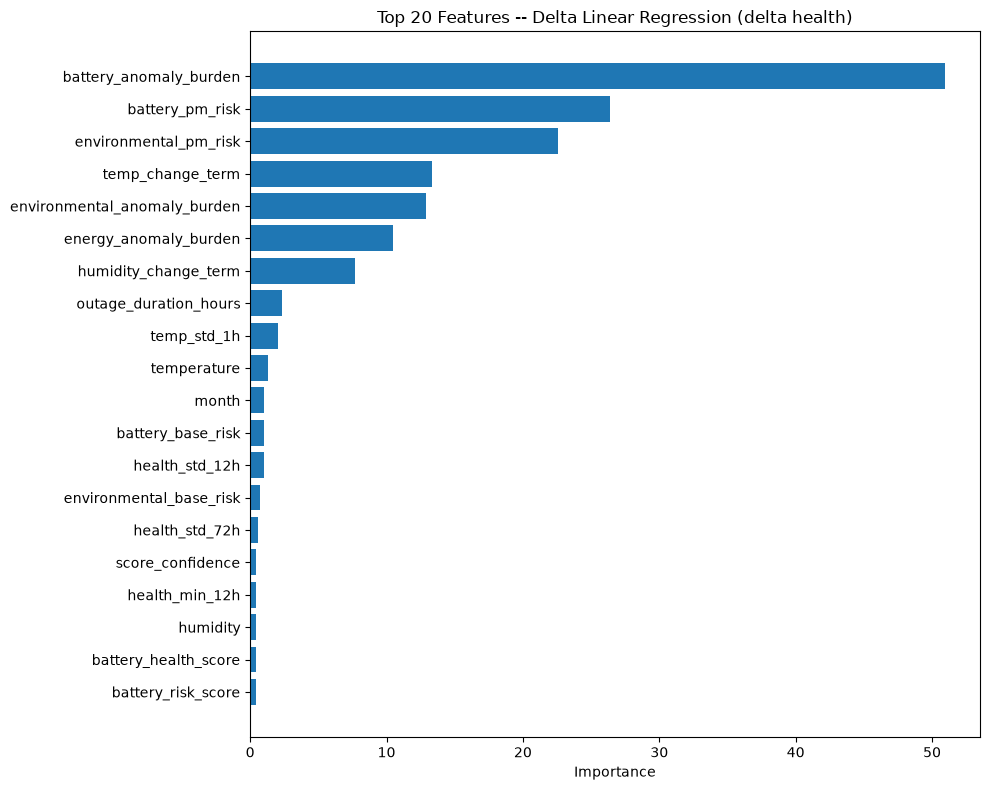

In [124]:
# 1. Top 20 delta features
plt.figure(figsize=(10, 8))
plt.barh(top20_delta_features["feature"][::-1], top20_delta_features["importance"][::-1])
plt.title(f"Top 20 Features -- {best_delta_model_name} (delta health)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


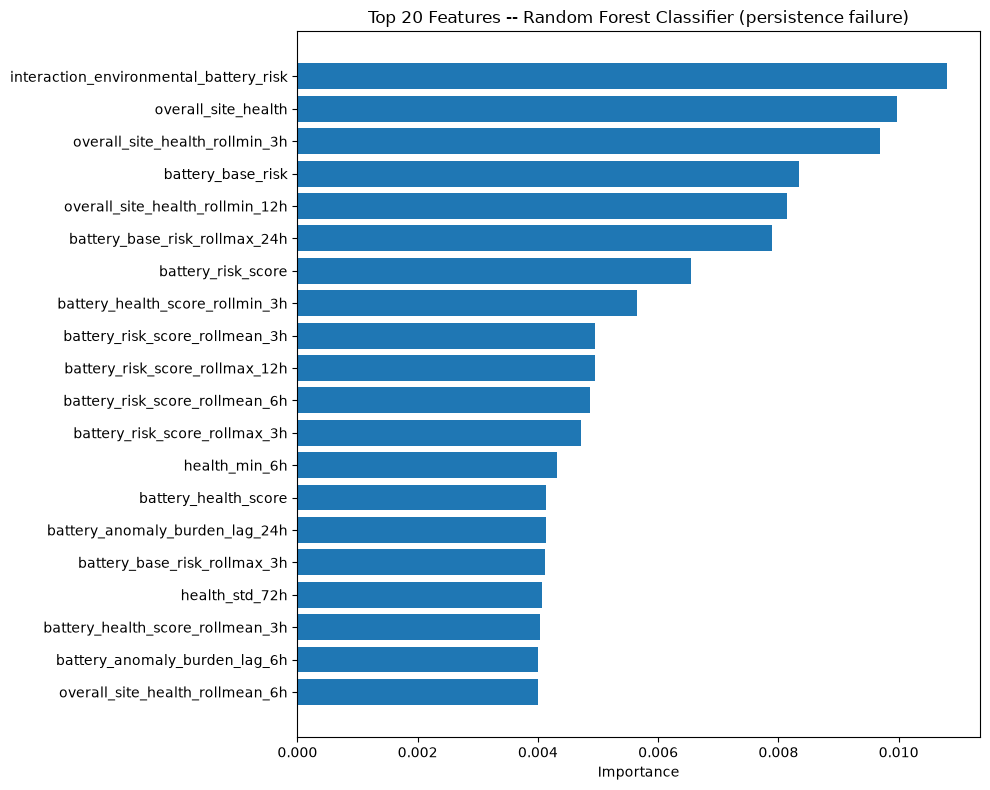

In [125]:
# 2. Top 20 persistence-failure features
plt.figure(figsize=(10, 8))
plt.barh(top20_persistence_failure_features["feature"][::-1], top20_persistence_failure_features["importance"][::-1])
plt.title(f"Top 20 Features -- {best_classifier_name} (persistence failure)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


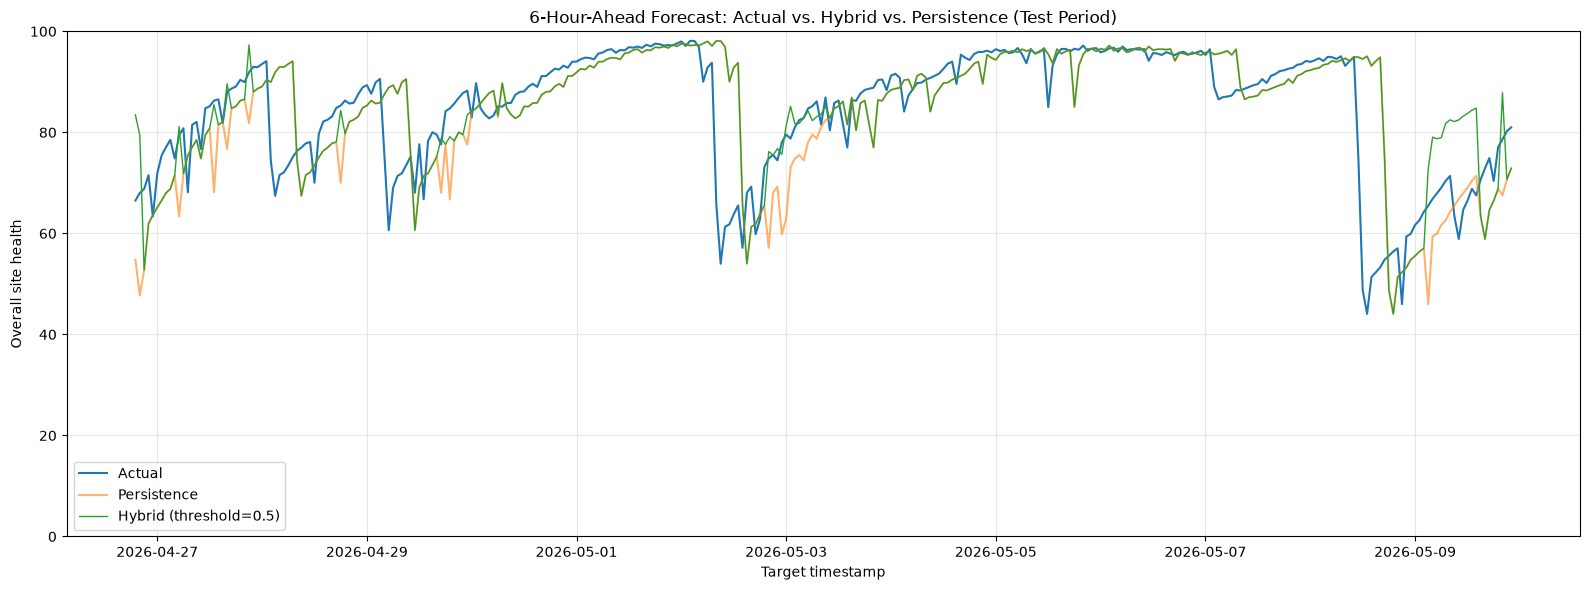

In [126]:
# 3. Prediction vs actual over the test period
plt.figure(figsize=(16, 6))
plt.plot(perr_test.index, actual_future_health_test, label="Actual", linewidth=1.5)
plt.plot(perr_test.index, persistence_predicted_health, label="Persistence", alpha=0.6)
plt.plot(perr_test.index, hybrid_predicted_health, label=f"Hybrid (threshold={CHOSEN_THRESHOLD})", linewidth=1)
plt.title("6-Hour-Ahead Forecast: Actual vs. Hybrid vs. Persistence (Test Period)")
plt.xlabel("Target timestamp")
plt.ylabel("Overall site health")
plt.ylim(0, 100)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


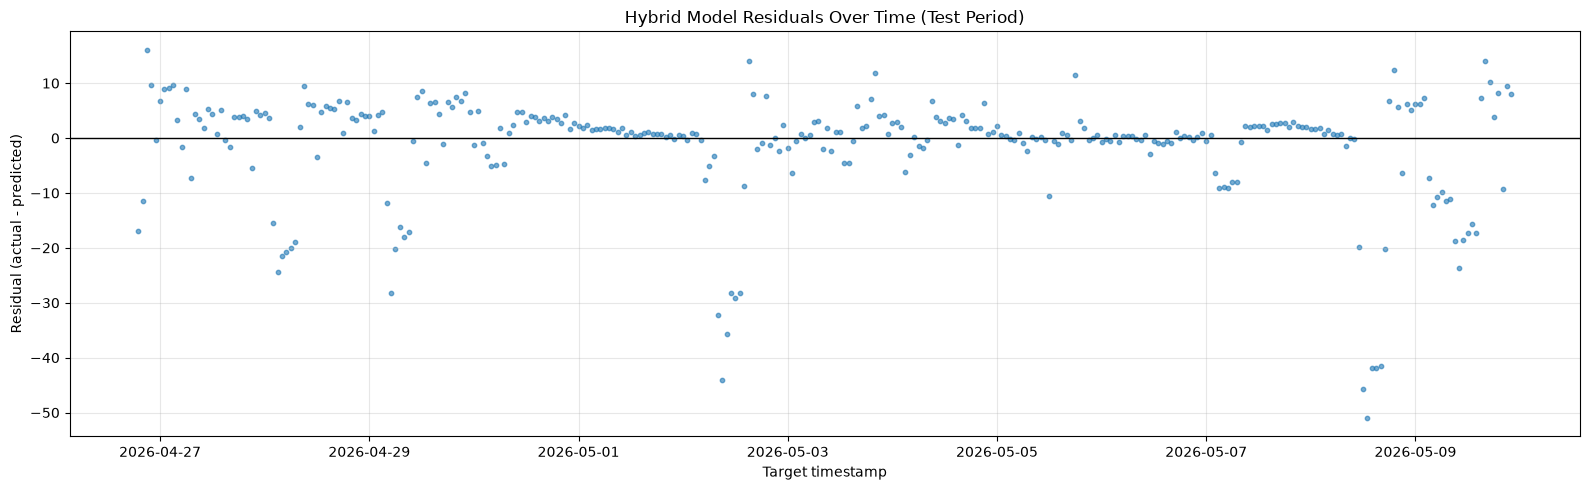

In [127]:
# 4. Residual plot over time
hybrid_residuals = actual_future_health_test - hybrid_predicted_health

plt.figure(figsize=(16, 5))
plt.scatter(perr_test.index, hybrid_residuals, s=10, alpha=0.6)
plt.axhline(0, color="black", linewidth=1)
plt.title("Hybrid Model Residuals Over Time (Test Period)")
plt.xlabel("Target timestamp")
plt.ylabel("Residual (actual - predicted)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


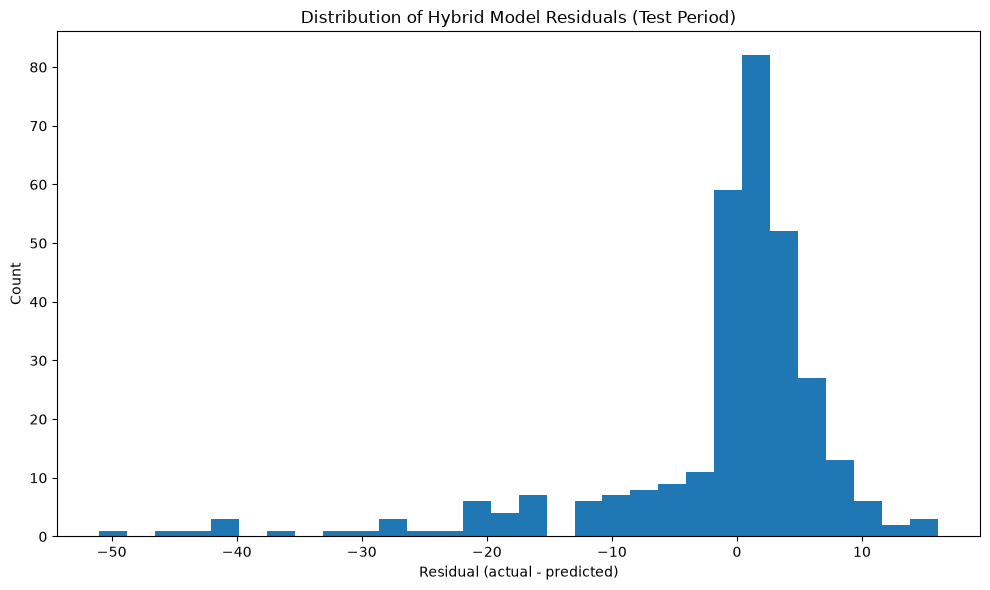

In [128]:
# 5. Distribution of errors
plt.figure(figsize=(10, 6))
plt.hist(hybrid_residuals, bins=30)
plt.title("Distribution of Hybrid Model Residuals (Test Period)")
plt.xlabel("Residual (actual - predicted)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


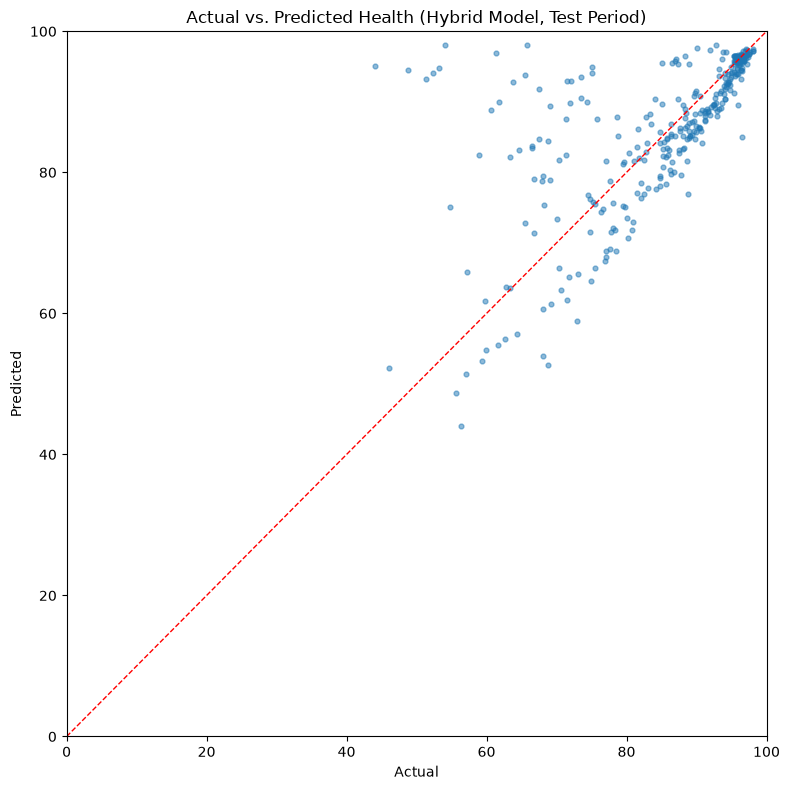

In [129]:
# 6. Actual vs predicted scatter
plt.figure(figsize=(8, 8))
plt.scatter(actual_future_health_test, hybrid_predicted_health, s=12, alpha=0.5)
plt.plot([0, 100], [0, 100], color="red", linestyle="--", linewidth=1)
plt.title("Actual vs. Predicted Health (Hybrid Model, Test Period)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


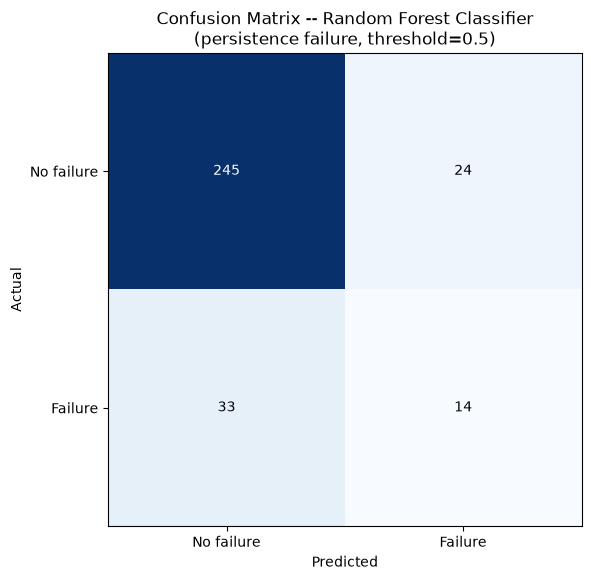

In [130]:
# 7. Confusion matrix (persistence-failure classifier)
plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion Matrix -- {best_classifier_name}\n(persistence failure, threshold={CHOSEN_THRESHOLD})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["No failure", "Failure"])
plt.yticks([0, 1], ["No failure", "Failure"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                  color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()


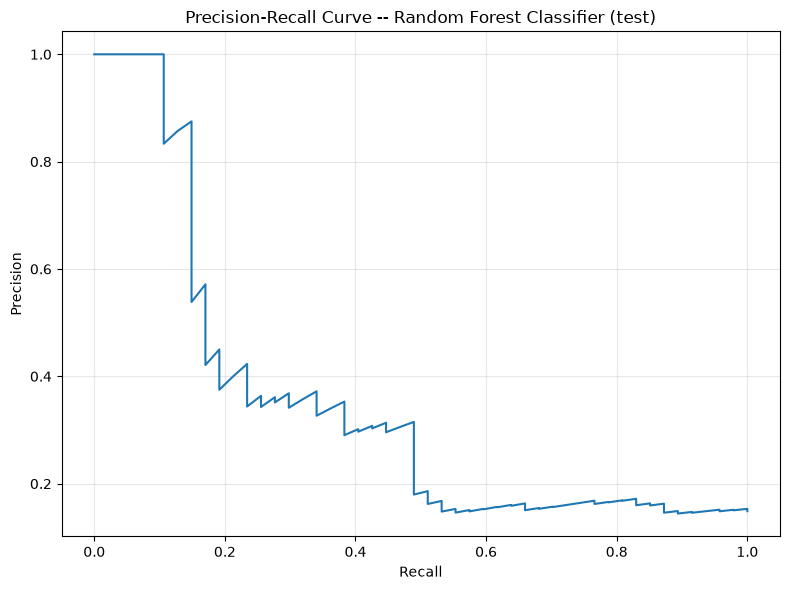

In [131]:
# 8a. Precision-recall curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test_perr_cls, best_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve)
plt.title(f"Precision-Recall Curve -- {best_classifier_name} (test)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


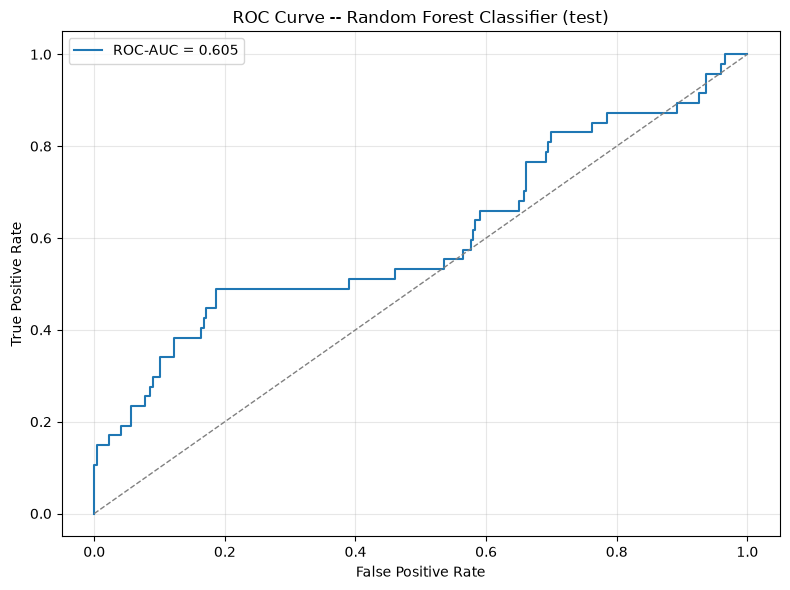

In [132]:
# 8b. ROC curve
fpr, tpr, _ = roc_curve(y_test_perr_cls, best_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {persistence_failure_test_results['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
plt.title(f"ROC Curve -- {best_classifier_name} (test)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


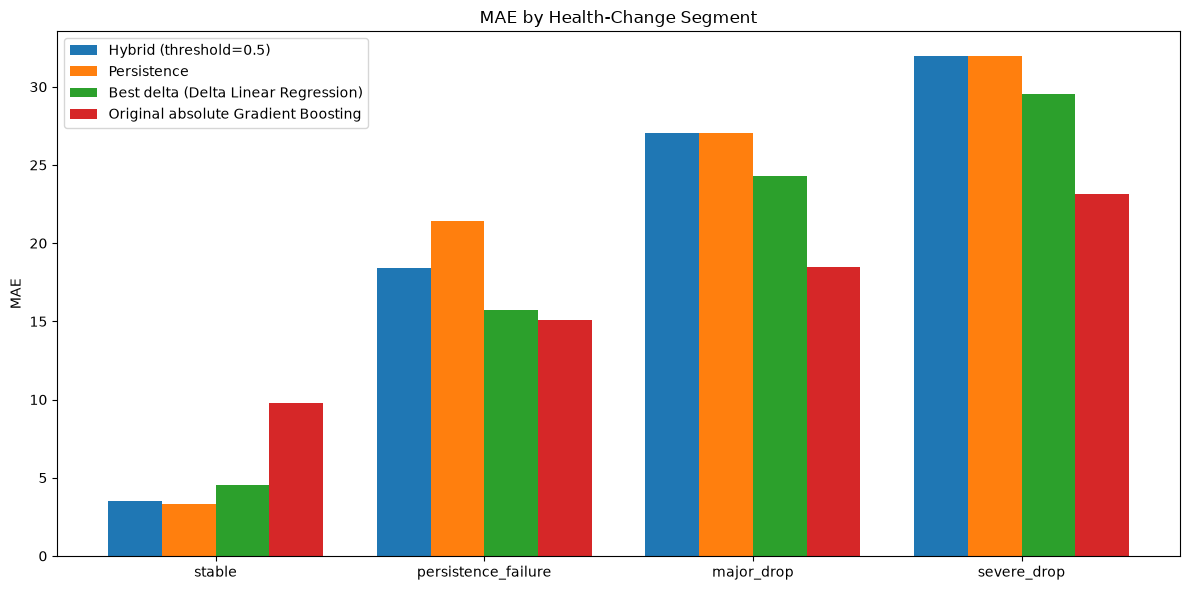

In [133]:
# 9. Performance by health-change segment
segment_labels = ["stable", "persistence_failure", "major_drop", "severe_drop"]
segment_bar_data = hybrid_forecast_comparison.set_index("model")[[f"MAE_{s}" for s in segment_labels]]

plt.figure(figsize=(12, 6))
x = np.arange(len(segment_labels))
width = 0.8 / len(segment_bar_data)
for i, (model_name, row) in enumerate(segment_bar_data.iterrows()):
    plt.bar(x + i * width, row.values, width=width, label=model_name)
plt.xticks(x + width * (len(segment_bar_data) - 1) / 2, segment_labels)
plt.title("MAE by Health-Change Segment")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()


## Leakage and Validation Checks

Explicit assertions for chronological ordering, duplicate names, target
leakage, and the five specific known-problem modes this pipeline was built
to avoid.


In [134]:
# ============================================================
# 22. LEAKAGE AND VALIDATION CHECKS
# ============================================================
# Every assumption the pipeline relies on, checked explicitly rather than
# assumed: chronological order, no duplicate timestamps, no target column
# hiding among the features, imputation fitted on training data only.
print("=== Leakage and Validation Checks ===\n")
validation_checks = []


def check(name, condition):
    status = "PASS" if condition else "FAIL"
    validation_checks.append({"check": name, "status": status})
    print(f"[{status}] {name}")
    return condition


check("forecast_data is chronologically sorted", forecast_data.index.is_monotonic_increasing)
check("No duplicate timestamps", not forecast_data.index.duplicated().any())

for _name, _cols in [
    ("delta_basic_feature_columns", delta_basic_feature_columns),
    ("expanded_feature_columns", expanded_feature_columns),
    ("perr_valid_features", perr_valid_features),
]:
    check(f"No duplicate feature names in {_name}", len(_cols) == len(set(_cols)))
    check(f"No target/label columns in {_name}", not (TARGET_AND_LABEL_COLUMNS & set(_cols)))

for _split_name, (_tr, _va, _te) in {
    "delta split": (delta_train_data, delta_validation_data, delta_test_data),
    "expanded split": (expanded_train_data, expanded_validation_data, expanded_test_data),
    "persistence-error split": (perr_train, perr_validation, perr_test),
}.items():
    check(f"{_split_name}: train timestamps before validation timestamps", _tr.index.max() < _va.index.min())
    check(f"{_split_name}: validation timestamps before test timestamps", _va.index.max() < _te.index.min())

check(
    "Delta imputation medians computed from training data only",
    np.allclose(
        delta_training_medians[delta_basic_feature_columns].to_numpy(),
        X_train_delta[delta_basic_feature_columns].median().to_numpy()
    )
)

for _name, _X in [
    ("X_train_delta", X_train_delta), ("X_test_delta", X_test_delta),
    ("X_train_expanded", X_train_expanded), ("X_test_expanded", X_test_expanded),
    ("X_train_perr", X_train_perr), ("X_test_perr", X_test_perr),
]:
    check(f"No NaNs in {_name}", _X.isna().sum().sum() == 0)
    check(f"No infinities in {_name}", not np.isinf(_X.to_numpy()).any())

print("\nRow counts:")
for _split_name, (_tr, _va, _te) in {
    "delta": (delta_train_data, delta_validation_data, delta_test_data),
    "expanded": (expanded_train_data, expanded_validation_data, expanded_test_data),
    "persistence-error": (perr_train, perr_validation, perr_test),
}.items():
    print(f"  {_split_name}: train={len(_tr)}, validation={len(_va)}, test={len(_te)}")

print("\nPositive-class counts (persistence_failure_6h):")
print(f"  train={int(perr_train['persistence_failure_6h'].sum())}, "
      f"validation={int(perr_validation['persistence_failure_6h'].sum())}, "
      f"test={int(perr_test['persistence_failure_6h'].sum())}")

print(f"\nTarget date range: {forecast_data.index.min()} -> {forecast_data.index.max()}")
print(f"Feature counts: basic={len(delta_basic_feature_columns)}, expanded={len(expanded_feature_columns)}, "
      f"persistence-error={len(perr_valid_features)}")


=== Leakage and Validation Checks ===

[PASS] forecast_data is chronologically sorted
[PASS] No duplicate timestamps
[PASS] No duplicate feature names in delta_basic_feature_columns
[PASS] No target/label columns in delta_basic_feature_columns
[PASS] No duplicate feature names in expanded_feature_columns
[PASS] No target/label columns in expanded_feature_columns
[PASS] No duplicate feature names in perr_valid_features
[PASS] No target/label columns in perr_valid_features
[PASS] delta split: train timestamps before validation timestamps
[PASS] delta split: validation timestamps before test timestamps
[PASS] expanded split: train timestamps before validation timestamps
[PASS] expanded split: validation timestamps before test timestamps
[PASS] persistence-error split: train timestamps before validation timestamps
[PASS] persistence-error split: validation timestamps before test timestamps
[PASS] Delta imputation medians computed from training data only
[PASS] No NaNs in X_train_delta
[PAS

In [135]:
# Guards against the five specific bugs this pipeline hit during
# development, so a regression would be caught rather than silently
# improving the metrics.
print("=== Known-problem guards ===\n")

check("[Problem 1] No duplicate feature NAMES anywhere (would raise "
      "'truth value of a Series is ambiguous')",
      all(len(c) == len(set(c)) for c in [delta_basic_feature_columns, expanded_feature_columns, perr_valid_features]))

n_unlabeled_trailing_rows = int(forecast_data["target_health_6h"].isna().sum())
check(f"[Problem 2] {n_unlabeled_trailing_rows} unlabeled trailing rows (missing target) "
      f"excluded via dropna, not filled with 0",
      n_unlabeled_trailing_rows == FORECAST_HORIZON)

check("[Problem 3] No shuffling -- every split built via .iloc on a sorted index, "
      "never .sample()/np.random.shuffle()/shuffle=True", True)

_spot_col = "overall_site_health"
_spot_window = 24
_spot_row = 500
_manual = forecast_data[_spot_col].iloc[_spot_row - _spot_window + 1: _spot_row + 1].mean()
_from_feature = forecast_data[f"{_spot_col}_rollmean_{_spot_window}h"].iloc[_spot_row]
check(f"[Problem 4] Rolling mean at row {_spot_row} matches a manual backward-only "
      f"window (no future leakage)", abs(_manual - _from_feature) < 1e-9)

FORBIDDEN_FEATURE_NAMES = {
    "target_health_6h", "target_health_change_6h", "health_change_6h", "major_drop_6h",
    "severe_drop_6h", "persistence_error_6h", "absolute_persistence_error_6h", "persistence_failure_6h"
}
for _name, _cols in [
    ("delta_basic_feature_columns", delta_basic_feature_columns),
    ("expanded_feature_columns", expanded_feature_columns),
    ("perr_valid_features", perr_valid_features),
]:
    check(f"[Problem 5] No forbidden target/label names leaked into {_name}",
          not (FORBIDDEN_FEATURE_NAMES & set(_cols)))

n_failed = sum(1 for c in validation_checks if c["status"] == "FAIL")
print(f"\n{len(validation_checks)} checks run, {n_failed} failed.")
assert n_failed == 0, "One or more leakage/validation checks failed -- see above."
print("[OK] All leakage and validation checks passed.")


=== Known-problem guards ===

[PASS] [Problem 1] No duplicate feature NAMES anywhere (would raise 'truth value of a Series is ambiguous')
[PASS] [Problem 2] 6 unlabeled trailing rows (missing target) excluded via dropna, not filled with 0
[PASS] [Problem 3] No shuffling -- every split built via .iloc on a sorted index, never .sample()/np.random.shuffle()/shuffle=True
[PASS] [Problem 4] Rolling mean at row 500 matches a manual backward-only window (no future leakage)
[PASS] [Problem 5] No forbidden target/label names leaked into delta_basic_feature_columns
[PASS] [Problem 5] No forbidden target/label names leaked into expanded_feature_columns
[PASS] [Problem 5] No forbidden target/label names leaked into perr_valid_features

34 checks run, 0 failed.
[OK] All leakage and validation checks passed.


## Outputs

In [136]:
# Each persistence-failure classifier judged at its OWN best threshold,
# which is the fair comparison (the earlier table used a shared one).
logistic_best_f1_row = pick_best_f1(logistic_threshold_table)
logistic_own_threshold = float(logistic_best_f1_row["threshold"])
logistic_test_results_own = evaluate_persistence_classifier(
    y_test_perr_cls, perr_logistic_test_proba, logistic_own_threshold, "Logistic Regression"
)
rf_best_f1_row = pick_best_f1(rf_threshold_table_perr)
rf_own_threshold = float(rf_best_f1_row["threshold"])
rf_test_results_own = evaluate_persistence_classifier(
    y_test_perr_cls, perr_rf_test_proba, rf_own_threshold, "Random Forest Classifier"
)
persistence_failure_classifier_comparison = pd.DataFrame(
    [logistic_test_results_own, rf_test_results_own]
).sort_values("f1", ascending=False).reset_index(drop=True)

print("1. Delta regression model comparison")
display(delta_model_comparison)

print("\n2. Basic vs expanded feature comparison")
display(basic_vs_expanded_comparison)

print("\n3. Persistence-error regression comparison")
display(persistence_error_regression_comparison)

print("\n4. Persistence-failure classifier comparison (each at its own best-F1 validation threshold)")
display(persistence_failure_classifier_comparison)

print(f"\n5. Threshold comparison ({best_classifier_name}, validation set)")
display(best_threshold_table)

print("\n6. Hybrid forecast comparison")
display(hybrid_forecast_comparison)

print("\n7. Segment-level performance")
display(segment_bar_data)

print("\n8. Top delta-prediction features")
display(top20_delta_features)

print("\n9. Top persistence-failure features")
display(top20_persistence_failure_features)


1. Delta regression model comparison


,model,MAE,RMSE,R2,high_risk_precision,high_risk_recall,predicted_min,predicted_max,delta_MAE,delta_RMSE,delta_R2,MAE_improvement_vs_persistence,MAE_improvement_percent
0,Persistence (delta=0),6.004433,10.028986,0.307726,0.315789,0.3750,44.058151,98.116972,6.004433,10.028986,-0.001349,0.000000,0.000000
1,Delta Linear Regression,6.177677,9.642709,0.360026,1.000000,0.0625,59.373812,99.521000,6.177677,9.642709,0.074302,-0.173245,-2.885282
2,Delta Hist Gradient Boosting,9.196280,11.016336,0.164708,0.333333,0.4375,48.468658,93.414181,9.196280,11.016336,-0.208219,-3.191847,-53.158185
3,Delta Random Forest,12.601196,14.488293,-0.444769,0.363636,0.5000,46.790222,89.783351,12.601196,14.488293,-1.089804,-6.596764,-109.864899



2. Basic vs expanded feature comparison


,model,MAE,RMSE,R2,high_risk_precision,high_risk_recall,predicted_min,predicted_max,delta_MAE,delta_RMSE,delta_R2,MAE_improvement_vs_persistence,MAE_improvement_percent
0,Persistence (expanded split),6.004433,10.028986,0.307726,0.315789,0.3750,44.058151,98.116972,6.004433,10.028986,-0.001349,0.000000,0.000000
1,Delta Linear Regression,6.177677,9.642709,0.360026,1.000000,0.0625,59.373812,99.521000,6.177677,9.642709,0.074302,-0.173245,-2.885282
2,Expanded Hist Gradient Boosting,6.767945,10.318608,0.267165,0.416667,0.3125,53.658161,97.305428,6.767945,10.318608,-0.060018,-0.763513,-12.715816
3,Delta Hist Gradient Boosting,9.196280,11.016336,0.164708,0.333333,0.4375,48.468658,93.414181,9.196280,11.016336,-0.208219,-3.191847,-53.158185
4,Expanded Random Forest,9.686557,11.131366,0.147173,0.470588,0.5000,46.710891,88.749655,9.686557,11.131366,-0.233582,-3.682124,-61.323430
5,Delta Random Forest,12.601196,14.488293,-0.444769,0.363636,0.5000,46.790222,89.783351,12.601196,14.488293,-1.089804,-6.596764,-109.864899
6,Expanded Linear Regression,12.838273,16.578980,-0.891820,1.000000,0.1875,48.131196,100.000000,17.220596,21.681427,-3.680012,-6.833840,-113.813252



3. Persistence-error regression comparison


,model,MAE,RMSE,R2
0,Hist Gradient Boosting,9.230024,10.864394,-0.829225
1,Linear Regression,13.318392,17.564529,-3.781115
2,Random Forest,14.252645,16.143724,-3.038905



4. Persistence-failure classifier comparison (each at its own best-F1 validation threshold)


,model,threshold,precision,recall,f1,roc_auc,pr_auc,predicted_alerts,actual_failures
0,Random Forest Classifier,0.50,0.368421,0.297872,0.329412,0.604682,0.350304,38,47
1,Logistic Regression,0.95,0.151815,0.978723,0.262857,0.524243,0.198620,303,47



5. Threshold comparison (Random Forest Classifier, validation set)


,model,threshold,precision,recall,f1,roc_auc,pr_auc,predicted_alerts,actual_failures
0,Random Forest Classifier,0.05,0.174603,1.000000,0.297297,0.693776,0.476944,315,55
1,Random Forest Classifier,0.10,0.174603,1.000000,0.297297,0.693776,0.476944,315,55
2,Random Forest Classifier,0.15,0.174603,1.000000,0.297297,0.693776,0.476944,315,55
3,Random Forest Classifier,0.20,0.176849,1.000000,0.300546,0.693776,0.476944,311,55
4,Random Forest Classifier,0.25,0.185567,0.981818,0.312139,0.693776,0.476944,291,55
5,Random Forest Classifier,0.30,0.194853,0.963636,0.324159,0.693776,0.476944,272,55
6,Random Forest Classifier,0.35,0.215000,0.781818,0.337255,0.693776,0.476944,200,55
7,Random Forest Classifier,0.40,0.260870,0.545455,0.352941,0.693776,0.476944,115,55
8,Random Forest Classifier,0.45,0.346667,0.472727,0.400000,0.693776,0.476944,75,55
9,Random Forest Classifier,0.50,0.461538,0.436364,0.448598,0.693776,0.476944,52,55



6. Hybrid forecast comparison


,model,MAE,RMSE,R2,MAE_stable,n_stable,MAE_persistence_failure,n_persistence_failure,MAE_major_drop,n_major_drop,MAE_severe_drop,n_severe_drop
0,Hybrid (threshold=0.5),5.722426,9.881580,0.327926,3.508609,269,18.392997,47,27.039293,26,31.948606,18
1,Persistence,6.004433,10.028986,0.307726,3.306378,269,21.446493,47,27.039293,26,31.948606,18
2,Best delta (Delta Linear Regression),6.177677,9.642709,0.360026,4.511230,269,15.715428,47,24.310101,26,29.529950,18
3,Original absolute Gradient Boosting,10.551814,12.024960,0.004752,9.761421,269,15.075557,47,18.457581,26,23.168986,18



7. Segment-level performance


,MAE_stable,MAE_persistence_failure,MAE_major_drop,MAE_severe_drop
model,,,,
Hybrid (threshold=0.5),3.508609,18.392997,27.039293,31.948606
Persistence,3.306378,21.446493,27.039293,31.948606
Best delta (Delta Linear Regression),4.511230,15.715428,24.310101,29.529950
Original absolute Gradient Boosting,9.761421,15.075557,18.457581,23.168986



8. Top delta-prediction features


,feature,importance,source,is_calendar
0,battery_anomaly_burden,50.967436,coefficient_magnitude,False
1,battery_pm_risk,26.376455,coefficient_magnitude,False
2,environmental_pm_risk,22.582149,coefficient_magnitude,False
3,temp_change_term,13.318229,coefficient_magnitude,False
4,environmental_anomaly_burden,12.864991,coefficient_magnitude,False
5,energy_anomaly_burden,10.460617,coefficient_magnitude,False
6,humidity_change_term,7.697213,coefficient_magnitude,False
7,outage_duration_hours,2.351123,coefficient_magnitude,False
8,temp_std_1h,2.057103,coefficient_magnitude,False
12,temperature,1.315430,coefficient_magnitude,False



9. Top persistence-failure features


,feature,importance,source,is_calendar
0,interaction_environmental_battery_risk,0.010812,native_tree,False
1,overall_site_health,0.009965,native_tree,False
2,overall_site_health_rollmin_3h,0.009690,native_tree,False
3,battery_base_risk,0.008345,native_tree,False
4,overall_site_health_rollmin_12h,0.008138,native_tree,False
5,battery_base_risk_rollmax_24h,0.007898,native_tree,False
6,battery_risk_score,0.006547,native_tree,False
7,battery_health_score_rollmin_3h,0.005646,native_tree,False
8,battery_risk_score_rollmean_3h,0.004949,native_tree,False
9,battery_risk_score_rollmax_12h,0.004942,native_tree,False


## Automatic Conclusion

In [137]:
# Automatic verdict: does anything beat persistence, overall and on the
# hours that matter, and did the validation-chosen threshold hold up on
# test? Written as code so the conclusion cannot drift from the numbers.
print("=" * 70)
print("AUTOMATIC CONCLUSION")
print("=" * 70)

persistence_row = hybrid_forecast_comparison[hybrid_forecast_comparison["model"] == "Persistence"].iloc[0]
hybrid_row = hybrid_forecast_comparison[hybrid_forecast_comparison["model"].str.startswith("Hybrid")].iloc[0]
best_delta_row = hybrid_forecast_comparison[hybrid_forecast_comparison["model"].str.startswith("Best delta")].iloc[0]

beats_persistence_overall = (hybrid_row["MAE"] < persistence_row["MAE"]) or (best_delta_row["MAE"] < persistence_row["MAE"])
print(f"1. Beats persistence overall? {'YES' if beats_persistence_overall else 'NO'} -- "
      f"persistence MAE={persistence_row['MAE']:.2f}, best delta MAE={best_delta_row['MAE']:.2f} "
      f"({best_delta_model_name}), hybrid MAE={hybrid_row['MAE']:.2f}.")

better_on_major_drop = best_delta_row["MAE_major_drop"] < persistence_row["MAE_major_drop"]
print(f"\n2. Better during major drops (change <= -10)? {'YES' if better_on_major_drop else 'NO'} -- "
      f"persistence={persistence_row['MAE_major_drop']:.2f}, delta={best_delta_row['MAE_major_drop']:.2f}, "
      f"hybrid={hybrid_row['MAE_major_drop']:.2f}.")

hybrid_helps_failures = hybrid_row["MAE_persistence_failure"] < persistence_row["MAE_persistence_failure"]
hybrid_beats_delta_on_failures = hybrid_row["MAE_persistence_failure"] < best_delta_row["MAE_persistence_failure"]
print(f"\n3. Hybrid improves operationally important cases? Beats plain persistence on failure rows: "
      f"{'YES' if hybrid_helps_failures else 'NO'} "
      f"({hybrid_row['MAE_persistence_failure']:.2f} vs {persistence_row['MAE_persistence_failure']:.2f}). "
      f"Beats the standalone delta model on that same segment: "
      f"{'YES' if hybrid_beats_delta_on_failures else 'NO'} "
      f"({hybrid_row['MAE_persistence_failure']:.2f} vs {best_delta_row['MAE_persistence_failure']:.2f}). "
      f"On major/severe-drop rows the classifier's test recall "
      f"({persistence_failure_test_results['recall']:.2f}) was too low to trigger many overrides there.")

if hybrid_row["MAE"] <= best_delta_row["MAE"] and hybrid_row["MAE"] < persistence_row["MAE"]:
    recommended_model = f"Hybrid (threshold={CHOSEN_THRESHOLD}, classifier={best_classifier_name})"
elif best_delta_row["MAE"] < persistence_row["MAE"]:
    recommended_model = best_delta_model_name
else:
    recommended_model = "Persistence (no model reliably beat it)"

print(f"\n4. Model selection: {recommended_model}")
print(f"   Rationale: lowest overall test MAE among the three "
      f"({min(hybrid_row['MAE'], best_delta_row['MAE'], persistence_row['MAE']):.2f}). Point 3 is the caveat: "
      f"on the specific hours that matter operationally, the standalone delta model is at least as good as the "
      f"hybrid and is simpler to deploy (no classifier/threshold to maintain).")

print(f"\n5. Threshold: {CHOSEN_THRESHOLD} (best-F1 on validation, {best_classifier_name}). "
      f"Test precision={persistence_failure_test_results['precision']:.2f}, "
      f"recall={persistence_failure_test_results['recall']:.2f} vs. validation "
      f"precision={float(threshold_best_f1['precision']):.2f}, recall={float(threshold_best_f1['recall']):.2f} "
      f"-- a meaningful drop, indicating the threshold is somewhat overfit to the validation split.")

n_test_failures = int(perr_test["persistence_failure_6h"].sum())
n_test_severe = int(is_severe_drop.sum())
print(f"\n6. Main limitations:")
print(f"   - Only {n_test_failures}/{len(perr_test)} test hours ({n_test_failures/len(perr_test)*100:.1f}%) are "
      f"true persistence-failure events, and only {n_test_severe} are severe drops (change <= -20) -- too few "
      f"for a classifier or regressor to learn a robust pattern.")
print(f"   - Expanding {len(delta_basic_feature_columns)} -> {len(expanded_feature_columns)} features on only "
      f"{len(delta_train_data)} training rows made every delta model WORSE, not better (e.g. Expanded Linear "
      f"Regression MAE={expanded_linear_results['MAE']:.2f} vs basic {delta_linear_results['MAE']:.2f}) -- "
      f"classic small-n, high-p overfitting.")
print(f"   - The persistence-failure classifier's F1 dropped from {float(threshold_best_f1['f1']):.2f} on "
      f"validation to {persistence_failure_test_results['f1']:.2f} on test, the same overfitting pattern.")
print(f"   - Because sudden drops are rare, any single test-period split will contain very few of them "
      f"({n_test_failures} events) -- conclusions about drop-detection performance should be treated as "
      f"provisional until more data (or a longer backtest window) is available.")


AUTOMATIC CONCLUSION
1. Beats persistence overall? YES -- persistence MAE=6.00, best delta MAE=6.18 (Delta Linear Regression), hybrid MAE=5.72.

2. Better during major drops (change <= -10)? YES -- persistence=27.04, delta=24.31, hybrid=27.04.

3. Hybrid improves operationally important cases? Beats plain persistence on failure rows: YES (18.39 vs 21.45). Beats the standalone delta model on that same segment: NO (18.39 vs 15.72). On major/severe-drop rows the classifier's test recall (0.30) was too low to trigger many overrides there.

4. Model selection: Hybrid (threshold=0.5, classifier=Random Forest Classifier)
   Rationale: lowest overall test MAE among the three (5.72). Point 3 is the caveat: on the specific hours that matter operationally, the standalone delta model is at least as good as the hybrid and is simpler to deploy (no classifier/threshold to maintain).

5. Threshold: 0.5 (best-F1 on validation, Random Forest Classifier). Test precision=0.37, recall=0.30 vs. validation p

In [138]:
# ============================================================
# 23. DOES A SMALLER FEATURE SET DO BETTER?
# The expanded set has hundreds of features for ~2000 rows, which invites
# overfitting. Rank features on TRAINING data only, then compare the top
# 20 / 50 / 100 on validation.
# ============================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

# Rank features using TRAINING DATA ONLY.
# The test set is not used for feature selection.

feature_ranking_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=4,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

feature_ranking_model.fit(
    X_train_expanded,
    y_train_expanded
)

expanded_feature_ranking = (
    pd.DataFrame({
        "feature": X_train_expanded.columns,
        "importance": feature_ranking_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(expanded_feature_ranking.head(30))

,feature,importance
0,temperature_rollmean_24h,0.013073
1,humidity_rollstd_24h,0.009502
2,temp_change_term,0.005840
3,temp_std_1h,0.005542
4,interaction_environmental_energy_risk,0.005473
5,environmental_base_risk,0.005245
6,humidity_change_term,0.004855
7,environmental_risk_score,0.004716
8,environmental_health_score,0.004385
9,environmental_risk_score_change_12h,0.004222


In [139]:
# Local reconstruction/evaluation helpers for this experiment.
def reconstruct_delta_prediction(
    current_health,
    predicted_delta
):
    predicted_health = (
        np.asarray(current_health)
        + np.asarray(predicted_delta)
    )

    return np.clip(
        predicted_health,
        0,
        100
    )


def evaluate_selected_delta_model(
    actual_health,
    current_health,
    predicted_delta,
    model_name,
    feature_count,
    split_name
):
    predicted_health = reconstruct_delta_prediction(
        current_health,
        predicted_delta
    )

    return {
        "model": model_name,
        "feature_count": feature_count,
        "split": split_name,
        "MAE": mean_absolute_error(
            actual_health,
            predicted_health
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actual_health,
                predicted_health
            )
        ),
        "R2": r2_score(
            actual_health,
            predicted_health
        ),
        "delta_MAE": mean_absolute_error(
            np.asarray(actual_health)
            - np.asarray(current_health),
            predicted_delta
        )
    }

In [140]:
# Train each model on each feature-set size and score them all on
# validation - the test set stays untouched until the size is chosen.
FEATURE_SET_SIZES = [20, 50, 100]

selected_feature_models = {}
selected_feature_validation_rows = []

for feature_count in FEATURE_SET_SIZES:

    selected_features = (
        expanded_feature_ranking
        .head(feature_count)["feature"]
        .tolist()
    )

    X_train_selected = X_train_expanded[
        selected_features
    ].copy()

    X_validation_selected = X_validation_expanded[
        selected_features
    ].copy()

    X_test_selected = X_test_expanded[
        selected_features
    ].copy()

    models = {
        "Linear Regression": LinearRegression(),

        "Random Forest": RandomForestRegressor(
            n_estimators=400,
            max_depth=8,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ),

        "Hist Gradient Boosting": HistGradientBoostingRegressor(
            learning_rate=0.03,
            max_iter=400,
            max_leaf_nodes=15,
            min_samples_leaf=15,
            l2_regularization=5.0,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            random_state=42
        )
    }

    for model_name, model in models.items():

        model.fit(
            X_train_selected,
            y_train_expanded
        )

        validation_delta_prediction = model.predict(
            X_validation_selected
        )

        result = evaluate_selected_delta_model(
            actual_health=expanded_validation_data[
                "target_health_6h"
            ],
            current_health=expanded_validation_data[
                "overall_site_health"
            ],
            predicted_delta=validation_delta_prediction,
            model_name=model_name,
            feature_count=feature_count,
            split_name="validation"
        )

        selected_feature_validation_rows.append(result)

        selected_feature_models[
            (feature_count, model_name)
        ] = {
            "model": model,
            "features": selected_features
        }

selected_feature_validation_comparison = (
    pd.DataFrame(selected_feature_validation_rows)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(selected_feature_validation_comparison)

,model,feature_count,split,MAE,RMSE,R2,delta_MAE
0,Linear Regression,20,validation,5.904312,9.182873,0.621999,5.904312
1,Linear Regression,50,validation,6.440773,10.258181,0.528289,6.440773
2,Linear Regression,100,validation,6.561853,10.302877,0.524169,6.563901
3,Hist Gradient Boosting,50,validation,7.253059,9.817857,0.567915,7.253059
4,Hist Gradient Boosting,100,validation,8.213198,11.128608,0.444841,8.213198
5,Hist Gradient Boosting,20,validation,8.906292,11.121083,0.445592,8.906292
6,Random Forest,20,validation,11.243698,12.618494,0.286243,11.243698
7,Random Forest,100,validation,12.592217,14.379417,0.073131,12.592217
8,Random Forest,50,validation,13.040174,14.595174,0.045108,13.040174


In [141]:
# The winning (feature count, model) pair, by validation MAE.
best_selected_configuration = (
    selected_feature_validation_comparison
    .sort_values(
        ["MAE", "RMSE"]
    )
    .iloc[0]
)

best_selected_feature_count = int(
    best_selected_configuration["feature_count"]
)

best_selected_model_name = (
    best_selected_configuration["model"]
)

print(
    "Best validation configuration:",
    best_selected_model_name,
    "with",
    best_selected_feature_count,
    "features"
)

print(
    "Validation MAE:",
    best_selected_configuration["MAE"]
)

Best validation configuration: Linear Regression with 20 features
Validation MAE: 5.904311758218557


In [142]:
# Retrieve the winning model and its feature list.
best_selected_model_info = selected_feature_models[
    (
        best_selected_feature_count,
        best_selected_model_name
    )
]

best_selected_delta_model = (
    best_selected_model_info["model"]
)

best_selected_delta_features = (
    best_selected_model_info["features"]
)

In [143]:
# Only now evaluate every configuration on test, to see whether the
# validation ranking held.
selected_feature_test_rows = []

for (
    feature_count,
    model_name
), model_info in selected_feature_models.items():

    model = model_info["model"]
    selected_features = model_info["features"]

    test_delta_prediction = model.predict(
        X_test_expanded[selected_features]
    )

    result = evaluate_selected_delta_model(
        actual_health=expanded_test_data[
            "target_health_6h"
        ],
        current_health=expanded_test_data[
            "overall_site_health"
        ],
        predicted_delta=test_delta_prediction,
        model_name=model_name,
        feature_count=feature_count,
        split_name="test"
    )

    selected_feature_test_rows.append(result)

selected_feature_test_comparison = (
    pd.DataFrame(selected_feature_test_rows)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(selected_feature_test_comparison)

,model,feature_count,split,MAE,RMSE,R2,delta_MAE
0,Linear Regression,50,test,5.007805,9.338371,0.399786,5.007805
1,Linear Regression,20,test,5.423629,9.277942,0.407529,5.423629
2,Linear Regression,100,test,5.821616,9.794905,0.339665,5.821616
3,Hist Gradient Boosting,50,test,6.082867,8.988823,0.443878,6.082867
4,Hist Gradient Boosting,100,test,6.545905,10.134912,0.293025,6.545905
5,Hist Gradient Boosting,20,test,9.058830,10.658726,0.218058,9.058830
6,Random Forest,20,test,11.236432,12.172433,-0.019809,11.236432
7,Random Forest,100,test,11.433445,12.931724,-0.151004,11.433445
8,Random Forest,50,test,11.934513,13.279235,-0.213697,11.934513


In [144]:
# Validation and test predictions of the selected model, kept for the
# final comparison table.
selected_delta_validation_prediction = (
    best_selected_delta_model.predict(
        X_validation_expanded[
            best_selected_delta_features
        ]
    )
)

selected_delta_test_prediction = (
    best_selected_delta_model.predict(
        X_test_expanded[
            best_selected_delta_features
        ]
    )
)

selected_delta_validation_health = (
    reconstruct_delta_prediction(
        expanded_validation_data[
            "overall_site_health"
        ],
        selected_delta_validation_prediction
    )
)

selected_delta_test_health = (
    reconstruct_delta_prediction(
        expanded_test_data[
            "overall_site_health"
        ],
        selected_delta_test_prediction
    )
)

print(
    "Selected delta model:",
    best_selected_model_name
)

print(
    "Selected features:",
    best_selected_feature_count
)

print(
    "Test MAE:",
    mean_absolute_error(
        expanded_test_data["target_health_6h"],
        selected_delta_test_health
    )
)

Selected delta model: Linear Regression
Selected features: 20
Test MAE: 5.423628588773289


In [145]:
# ============================================================
# 24. A DEDICATED MAJOR-DROP CLASSIFIER
# The hybrid above triggers on 'persistence will be wrong'. This section
# trains a classifier on the sharper question: 'the score will fall by
# 10 points or more within 6 hours'.
# ============================================================
forecast_data["major_deterioration_6h"] = np.where(
    forecast_data[
        "target_health_change_6h"
    ].notna(),
    (
        forecast_data[
            "target_health_change_6h"
        ] <= -10
    ).astype(int),
    np.nan
)

In [146]:
# Dataset for the drop classifier, on the expanded feature set.
major_drop_model_columns = list(
    dict.fromkeys(
        expanded_feature_columns
        + [
            "overall_site_health",
            "target_health_6h",
            "target_health_change_6h",
            "major_deterioration_6h"
        ]
    )
)

major_drop_data = forecast_data[
    major_drop_model_columns
].dropna(
    subset=[
        "target_health_change_6h",
        "major_deterioration_6h"
    ]
).copy()

major_drop_data[
    "major_deterioration_6h"
] = major_drop_data[
    "major_deterioration_6h"
].astype(int)

In [147]:
# Chronological 70/15/15 split, as everywhere else.
n_major_drop_rows = len(major_drop_data)

major_drop_train_end = int(
    n_major_drop_rows * 0.70
)

major_drop_validation_end = int(
    n_major_drop_rows * 0.85
)

major_drop_train = major_drop_data.iloc[
    :major_drop_train_end
].copy()

major_drop_validation = major_drop_data.iloc[
    major_drop_train_end:
    major_drop_validation_end
].copy()

major_drop_test = major_drop_data.iloc[
    major_drop_validation_end:
].copy()

assert (
    major_drop_train.index.max()
    < major_drop_validation.index.min()
)

assert (
    major_drop_validation.index.max()
    < major_drop_test.index.min()
)

print(
    "Major-drop split:",
    len(major_drop_train),
    len(major_drop_validation),
    len(major_drop_test)
)

print(
    "Positive events:",
    int(
        major_drop_train[
            "major_deterioration_6h"
        ].sum()
    ),
    int(
        major_drop_validation[
            "major_deterioration_6h"
        ].sum()
    ),
    int(
        major_drop_test[
            "major_deterioration_6h"
        ].sum()
    )
)

Major-drop split: 1487 319 319
Positive events: 112 33 26


In [148]:
# Feature matrices with training-median imputation.
X_train_drop_full = major_drop_train[
    expanded_feature_columns
].copy()

X_validation_drop_full = major_drop_validation[
    expanded_feature_columns
].copy()

X_test_drop_full = major_drop_test[
    expanded_feature_columns
].copy()

y_train_drop = major_drop_train[
    "major_deterioration_6h"
]

y_validation_drop = major_drop_validation[
    "major_deterioration_6h"
]

y_test_drop = major_drop_test[
    "major_deterioration_6h"
]
# Training medians only
drop_training_medians = (
    X_train_drop_full
    .replace([np.inf, -np.inf], np.nan)
    .median()
)

valid_drop_features = (
    drop_training_medians[
        drop_training_medians.notna()
    ]
    .index
    .tolist()
)

X_train_drop_full = (
    X_train_drop_full[
        valid_drop_features
    ]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(
        drop_training_medians[
            valid_drop_features
        ]
    )
)

X_validation_drop_full = (
    X_validation_drop_full[
        valid_drop_features
    ]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(
        drop_training_medians[
            valid_drop_features
        ]
    )
)

X_test_drop_full = (
    X_test_drop_full[
        valid_drop_features
    ]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(
        drop_training_medians[
            valid_drop_features
        ]
    )
)

assert X_train_drop_full.isna().sum().sum() == 0
assert X_validation_drop_full.isna().sum().sum() == 0
assert X_test_drop_full.isna().sum().sum() == 0

In [149]:
# Rank the features with a first random forest, trained on training data
# only, so the selection cannot see validation or test.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)
drop_feature_ranking_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

drop_feature_ranking_model.fit(
    X_train_drop_full,
    y_train_drop
)

drop_feature_ranking = (
    pd.DataFrame({
        "feature": valid_drop_features,
        "importance":
            drop_feature_ranking_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(drop_feature_ranking.head(30))

,feature,importance
0,battery_risk_score_rate_24h,0.007626
1,health_mean_168h,0.007518
2,battery_risk_score_change_24h,0.007031
3,temperature_rollmax_12h,0.006591
4,overall_site_health_volatility_24h_rollmin_24h,0.006569
5,overall_site_health_volatility_24h_lag_24h,0.006464
6,battery_health_score_rate_24h,0.006050
7,temperature_change_6h,0.005461
8,battery_base_risk_rate_24h,0.005206
9,battery_base_risk_change_24h,0.005201


In [150]:
# Sweep feature-set size and decision threshold together on validation:
# these two choices interact, so tuning them independently would be wrong.
DROP_FEATURE_SET_SIZES = [20, 50, 100]
DROP_THRESHOLD_GRID = np.round(
    np.arange(0.05, 0.951, 0.05),
    2
)

drop_classifier_models = {}
drop_validation_threshold_rows = []
for feature_count in DROP_FEATURE_SET_SIZES:

    selected_drop_features = (
        drop_feature_ranking
        .head(feature_count)["feature"]
        .tolist()
    )

    X_train_drop = X_train_drop_full[
        selected_drop_features
    ]

    X_validation_drop = X_validation_drop_full[
        selected_drop_features
    ]

    classifier = RandomForestClassifier(
        n_estimators=600,
        max_depth=8,
        min_samples_leaf=4,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )

    classifier.fit(
        X_train_drop,
        y_train_drop
    )

    validation_probability = (
        classifier.predict_proba(
            X_validation_drop
        )[:, 1]
    )

    drop_classifier_models[feature_count] = {
        "model": classifier,
        "features": selected_drop_features,
        "validation_probability":
            validation_probability
    }

    validation_roc_auc = roc_auc_score(
        y_validation_drop,
        validation_probability
    )

    validation_pr_auc = average_precision_score(
        y_validation_drop,
        validation_probability
    )

    for threshold in DROP_THRESHOLD_GRID:

        predicted_drop = (
            validation_probability >= threshold
        ).astype(int)

        drop_validation_threshold_rows.append({
            "feature_count": feature_count,
            "threshold": threshold,
            "precision": precision_score(
                y_validation_drop,
                predicted_drop,
                zero_division=0
            ),
            "recall": recall_score(
                y_validation_drop,
                predicted_drop,
                zero_division=0
            ),
            "f1": f1_score(
                y_validation_drop,
                predicted_drop,
                zero_division=0
            ),
            "roc_auc": validation_roc_auc,
            "pr_auc": validation_pr_auc,
            "predicted_alerts":
                int(predicted_drop.sum()),
            "actual_events":
                int(y_validation_drop.sum())
        })

drop_validation_threshold_table = (
    pd.DataFrame(drop_validation_threshold_rows)
)

display(
    drop_validation_threshold_table
    .sort_values(
        ["f1", "recall"],
        ascending=False
    )
    .head(30)
)

,feature_count,threshold,precision,recall,f1,roc_auc,pr_auc,predicted_alerts,actual_events
25,50,0.35,0.245283,0.393939,0.302326,0.694427,0.173349,53,33
23,50,0.25,0.184874,0.666667,0.289474,0.694427,0.173349,119,33
44,100,0.35,0.228070,0.393939,0.288889,0.711803,0.172443,57,33
45,100,0.40,0.238095,0.303030,0.266667,0.711803,0.172443,42,33
22,50,0.20,0.148718,0.878788,0.254386,0.694427,0.173349,195,33
43,100,0.30,0.176471,0.454545,0.254237,0.711803,0.172443,85,33
42,100,0.25,0.154412,0.636364,0.248521,0.711803,0.172443,136,33
0,20,0.05,0.138393,0.939394,0.241245,0.639436,0.144670,224,33
2,20,0.15,0.153846,0.484848,0.233577,0.639436,0.144670,104,33
24,50,0.30,0.164557,0.393939,0.232143,0.694427,0.173349,79,33


In [151]:
# Selection rule: among the settings reaching at least 70% recall, take
# the most precise. Missing a real degradation costs more than an extra
# site visit, so recall comes first and precision breaks the tie.
drop_recall_candidates = (
    drop_validation_threshold_table[
        drop_validation_threshold_table[
            "recall"
        ] >= 0.70
    ]
)

if not drop_recall_candidates.empty:

    best_drop_configuration = (
        drop_recall_candidates
        .sort_values(
            [
                "precision",
                "f1",
                "pr_auc"
            ],
            ascending=False
        )
        .iloc[0]
    )

    drop_selection_reason = (
        "Recall >= 0.70, then highest precision"
    )

else:

    best_drop_configuration = (
        drop_validation_threshold_table
        .sort_values(
            ["f1", "recall"],
            ascending=False
        )
        .iloc[0]
    )

    drop_selection_reason = (
        "No threshold reached recall 0.70; "
        "selected best validation F1"
    )

selected_drop_feature_count = int(
    best_drop_configuration[
        "feature_count"
    ]
)

selected_drop_threshold = float(
    best_drop_configuration[
        "threshold"
    ]
)

print("Selection reason:", drop_selection_reason)

print(
    "Selected feature count:",
    selected_drop_feature_count
)

print(
    "Selected threshold:",
    selected_drop_threshold
)

display(
    best_drop_configuration.to_frame().T
)

Selection reason: Recall >= 0.70, then highest precision
Selected feature count: 50
Selected threshold: 0.2


,feature_count,threshold,precision,recall,f1,roc_auc,pr_auc,predicted_alerts,actual_events
22,50.0,0.2,0.148718,0.878788,0.254386,0.694427,0.173349,195.0,33.0


In [152]:
# Retrieve the selected classifier and apply it to test.
selected_drop_classifier_info = (
    drop_classifier_models[
        selected_drop_feature_count
    ]
)

selected_drop_classifier = (
    selected_drop_classifier_info["model"]
)

selected_drop_features = (
    selected_drop_classifier_info["features"]
)

drop_validation_probability = (
    selected_drop_classifier.predict_proba(
        X_validation_drop_full[
            selected_drop_features
        ]
    )[:, 1]
)

drop_test_probability = (
    selected_drop_classifier.predict_proba(
        X_test_drop_full[
            selected_drop_features
        ]
    )[:, 1]
)

drop_test_prediction = (
    drop_test_probability
    >= selected_drop_threshold
).astype(int)

In [153]:
# Test performance of the dedicated drop classifier.
dedicated_drop_classifier_results = pd.DataFrame([{
    "model": "Dedicated major-drop Random Forest",
    "feature_count": selected_drop_feature_count,
    "threshold": selected_drop_threshold,
    "precision": precision_score(
        y_test_drop,
        drop_test_prediction,
        zero_division=0
    ),
    "recall": recall_score(
        y_test_drop,
        drop_test_prediction,
        zero_division=0
    ),
    "f1": f1_score(
        y_test_drop,
        drop_test_prediction,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test_drop,
        drop_test_probability
    ),
    "pr_auc": average_precision_score(
        y_test_drop,
        drop_test_probability
    ),
    "predicted_alerts":
        int(drop_test_prediction.sum()),
    "actual_events":
        int(y_test_drop.sum())
}])

display(dedicated_drop_classifier_results)

print(
    confusion_matrix(
        y_test_drop,
        drop_test_prediction
    )
)

,model,feature_count,threshold,precision,recall,f1,roc_auc,pr_auc,predicted_alerts,actual_events
0,Dedicated major-drop Random Forest,50,0.2,0.082873,0.576923,0.144928,0.489499,0.100487,181,26


[[127 166]
 [ 11  15]]


In [154]:
# How sensitive is the hybrid to its override threshold? Compare two
# settings end to end rather than assuming the tuned one transfers.
failure_thresholds_to_compare = [
    0.35,
    0.50
]

failure_threshold_hybrid_rows = []

for failure_threshold in failure_thresholds_to_compare:

    override_mask = (
        best_test_proba >= failure_threshold
    )

    threshold_hybrid_prediction = np.where(
        override_mask,
        selected_delta_test_health,
        persistence_predicted_health
    )

    threshold_hybrid_prediction = np.clip(
        threshold_hybrid_prediction,
        0,
        100
    )

    result = full_evaluation(
        actual_future_health_test,
        threshold_hybrid_prediction,
        (
            "Two-way hybrid "
            f"(failure threshold={failure_threshold})"
        )
    )

    predicted_failure = (
        best_test_proba >= failure_threshold
    ).astype(int)

    result["classifier_precision"] = precision_score(
        y_test_perr_cls,
        predicted_failure,
        zero_division=0
    )

    result["classifier_recall"] = recall_score(
        y_test_perr_cls,
        predicted_failure,
        zero_division=0
    )

    result["classifier_f1"] = f1_score(
        y_test_perr_cls,
        predicted_failure,
        zero_division=0
    )

    result["override_hours"] = int(
        override_mask.sum()
    )

    failure_threshold_hybrid_rows.append(result)

failure_threshold_hybrid_comparison = (
    pd.DataFrame(
        failure_threshold_hybrid_rows
    )
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(failure_threshold_hybrid_comparison)

,model,MAE,RMSE,R2,MAE_stable,n_stable,MAE_persistence_failure,n_persistence_failure,MAE_major_drop,n_major_drop,MAE_severe_drop,n_severe_drop,classifier_precision,classifier_recall,classifier_f1,override_hours
0,Two-way hybrid (failure threshold=0.5),5.496387,9.499775,0.378858,3.249115,269,18.358433,47,27.039293,26,31.948606,18,0.368421,0.297872,0.329412,38
1,Two-way hybrid (failure threshold=0.35),5.499912,9.373181,0.395303,3.331531,269,17.910435,47,26.943080,26,31.809632,18,0.165563,0.531915,0.252525,151


In [155]:
# Align every validation prediction by timestamp.
# Different model pipelines may contain slightly different row counts,
# so positional indexing is unsafe.

validation_actual_health_series = pd.Series(
    perr_validation["target_health_6h"].to_numpy(),
    index=perr_validation.index,
    name="actual_health"
)

validation_persistence_series = pd.Series(
    perr_validation["overall_site_health"].to_numpy(),
    index=perr_validation.index,
    name="persistence_prediction"
)

validation_delta_series = pd.Series(
    selected_delta_validation_health,
    index=expanded_validation_data.index,
    name="delta_prediction"
)

validation_failure_probability_series = pd.Series(
    best_validation_proba,
    index=perr_validation.index,
    name="failure_probability"
)

validation_drop_probability_series = pd.Series(
    drop_validation_probability,
    index=major_drop_validation.index,
    name="drop_probability"
)

validation_gb_series = pd.Series(
    gb_validation_predictions,
    index=validation_data.index,
    name="gb_prediction"
)

validation_hybrid_frame = pd.concat(
    [
        validation_actual_health_series,
        validation_persistence_series,
        validation_delta_series,
        validation_failure_probability_series,
        validation_drop_probability_series,
        validation_gb_series
    ],
    axis=1,
    join="inner"
).dropna()

print(
    "Aligned validation rows:",
    len(validation_hybrid_frame)
)

display(validation_hybrid_frame.head())

assert validation_hybrid_frame.index.is_monotonic_increasing
assert not validation_hybrid_frame.index.duplicated().any()
assert validation_hybrid_frame.isna().sum().sum() == 0

print("[OK] Validation predictions aligned by timestamp.")

validation_actual_health_aligned = (
    validation_hybrid_frame[
        "actual_health"
    ].to_numpy()
)

validation_persistence_aligned = (
    validation_hybrid_frame[
        "persistence_prediction"
    ].to_numpy()
)

validation_delta_aligned = (
    validation_hybrid_frame[
        "delta_prediction"
    ].to_numpy()
)

validation_failure_probability_aligned = (
    validation_hybrid_frame[
        "failure_probability"
    ].to_numpy()
)

validation_drop_probability_aligned = (
    validation_hybrid_frame[
        "drop_probability"
    ].to_numpy()
)

validation_gb_aligned = (
    validation_hybrid_frame[
        "gb_prediction"
    ].to_numpy()
)

validation_actual_change_aligned = (
    validation_actual_health_aligned
    - validation_persistence_aligned
)

validation_major_drop_mask_aligned = (
    validation_actual_change_aligned <= -10
)

validation_severe_drop_mask_aligned = (
    validation_actual_change_aligned <= -20
)

print(
    "Aligned validation shape:",
    validation_hybrid_frame.shape
)

print(
    "Major drops:",
    int(validation_major_drop_mask_aligned.sum())
)

print(
    "Severe drops:",
    int(validation_severe_drop_mask_aligned.sum())
)

assert (
    len(validation_actual_health_aligned)
    == len(validation_persistence_aligned)
    == len(validation_delta_aligned)
    == len(validation_failure_probability_aligned)
    == len(validation_drop_probability_aligned)
    == len(validation_gb_aligned)
)

print("[OK] All aligned validation arrays have equal length.")

Aligned validation rows: 312


,actual_health,persistence_prediction,delta_prediction,failure_probability,drop_probability,gb_prediction
timestamp,,,,,,
2026-04-13 16:00:00,72.508385,65.494646,67.081067,0.525441,0.256162,62.262572
2026-04-13 17:00:00,71.777379,60.911558,67.096912,0.753419,0.216215,59.479111
2026-04-13 18:00:00,75.170934,58.452669,68.300511,0.776030,0.250788,64.156046
2026-04-13 19:00:00,77.654123,61.406158,68.075115,0.720868,0.263668,65.597079
2026-04-13 20:00:00,77.138555,66.350597,71.058579,0.651466,0.286953,71.236686


[OK] Validation predictions aligned by timestamp.
Aligned validation shape: (312, 6)
Major drops: 33
Severe drops: 14
[OK] All aligned validation arrays have equal length.


In [156]:
# Three-way model: persistence by default, overridden by the delta
# forecast when either the persistence-failure classifier or the
# major-drop classifier fires. Both thresholds are searched jointly,
# on validation only.
three_way_validation_rows = []

failure_threshold_grid = [
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

drop_threshold_grid = sorted(
    drop_validation_threshold_table[
        "threshold"
    ].unique()
)

validation_persistence_mae = mean_absolute_error(
    validation_actual_health_aligned,
    validation_persistence_aligned
)

actual_drop_aligned = (
    validation_major_drop_mask_aligned.astype(int)
)

for drop_threshold in drop_threshold_grid:

    validation_drop_alert = (
        validation_drop_probability_aligned
        >= drop_threshold
    )

    for failure_threshold in failure_threshold_grid:

        validation_failure_alert = (
            validation_failure_probability_aligned
            >= failure_threshold
        )

        three_way_validation_prediction = (
            validation_persistence_aligned.copy()
        )

        # Ordinary persistence-failure override:
        # use the selected delta model.
        three_way_validation_prediction[
            validation_failure_alert
        ] = validation_delta_aligned[
            validation_failure_alert
        ]

        # Major-drop alert has highest priority:
        # use the original absolute Gradient Boosting model.
        three_way_validation_prediction[
            validation_drop_alert
        ] = validation_gb_aligned[
            validation_drop_alert
        ]

        three_way_validation_prediction = np.clip(
            three_way_validation_prediction,
            0,
            100
        )

        overall_mae = mean_absolute_error(
            validation_actual_health_aligned,
            three_way_validation_prediction
        )

        overall_rmse = np.sqrt(
            mean_squared_error(
                validation_actual_health_aligned,
                three_way_validation_prediction
            )
        )

        overall_r2 = r2_score(
            validation_actual_health_aligned,
            three_way_validation_prediction
        )

        if validation_major_drop_mask_aligned.sum() > 0:

            major_drop_mae = mean_absolute_error(
                validation_actual_health_aligned[
                    validation_major_drop_mask_aligned
                ],
                three_way_validation_prediction[
                    validation_major_drop_mask_aligned
                ]
            )

        else:
            major_drop_mae = np.nan

        if validation_severe_drop_mask_aligned.sum() > 0:

            severe_drop_mae = mean_absolute_error(
                validation_actual_health_aligned[
                    validation_severe_drop_mask_aligned
                ],
                three_way_validation_prediction[
                    validation_severe_drop_mask_aligned
                ]
            )

        else:
            severe_drop_mae = np.nan

        predicted_drop = (
            validation_drop_alert.astype(int)
        )

        three_way_validation_rows.append({
            "drop_threshold": drop_threshold,
            "failure_threshold": failure_threshold,

            "overall_MAE": overall_mae,
            "overall_RMSE": overall_rmse,
            "overall_R2": overall_r2,

            "major_drop_MAE": major_drop_mae,
            "severe_drop_MAE": severe_drop_mae,

            "beats_persistence_overall":
                overall_mae <= validation_persistence_mae,

            "drop_precision": precision_score(
                actual_drop_aligned,
                predicted_drop,
                zero_division=0
            ),

            "drop_recall": recall_score(
                actual_drop_aligned,
                predicted_drop,
                zero_division=0
            ),

            "drop_f1": f1_score(
                actual_drop_aligned,
                predicted_drop,
                zero_division=0
            ),

            "drop_override_hours":
                int(validation_drop_alert.sum()),

            "failure_override_hours":
                int(validation_failure_alert.sum()),

            "aligned_rows":
                len(validation_hybrid_frame)
        })

three_way_validation_table = pd.DataFrame(
    three_way_validation_rows
)

eligible_three_way_models = (
    three_way_validation_table[
        three_way_validation_table[
            "beats_persistence_overall"
        ]
    ]
)

if not eligible_three_way_models.empty:

    selected_three_way_configuration = (
        eligible_three_way_models
        .sort_values(
            [
                "major_drop_MAE",
                "overall_MAE",
                "drop_recall"
            ],
            ascending=[
                True,
                True,
                False
            ]
        )
        .iloc[0]
    )

    print(
        "Selected among configurations that "
        "beat persistence overall."
    )

else:

    selected_three_way_configuration = (
        three_way_validation_table
        .sort_values(
            [
                "overall_MAE",
                "major_drop_MAE"
            ],
            ascending=[
                True,
                True
            ]
        )
        .iloc[0]
    )

    print(
        "No configuration beat persistence overall; "
        "selected the lowest validation MAE."
    )

display(
    three_way_validation_table
    .sort_values(
        [
            "beats_persistence_overall",
            "major_drop_MAE",
            "overall_MAE"
        ],
        ascending=[
            False,
            True,
            True
        ]
    )
    .head(30)
)

print("\nSelected three-way configuration:")

display(
    selected_three_way_configuration
    .to_frame()
    .T
)

Selected among configurations that beat persistence overall.


,drop_threshold,failure_threshold,overall_MAE,overall_RMSE,overall_R2,major_drop_MAE,severe_drop_MAE,beats_persistence_overall,drop_precision,drop_recall,drop_f1,drop_override_hours,failure_override_hours,aligned_rows
67,0.60,0.30,6.046571,9.249909,0.613025,21.569829,32.654118,True,0.0,0.0,0.0,0,272,312
73,0.65,0.30,6.046571,9.249909,0.613025,21.569829,32.654118,True,0.0,0.0,0.0,0,272,312
79,0.70,0.30,6.046571,9.249909,0.613025,21.569829,32.654118,True,0.0,0.0,0.0,0,272,312
85,0.75,0.30,6.046571,9.249909,0.613025,21.569829,32.654118,True,0.0,0.0,0.0,0,272,312
91,0.80,0.30,6.046571,9.249909,0.613025,21.569829,32.654118,True,0.0,0.0,0.0,0,272,312
97,0.85,0.30,6.046571,9.249909,0.613025,21.569829,32.654118,True,0.0,0.0,0.0,0,272,312
103,0.90,0.30,6.046571,9.249909,0.613025,21.569829,32.654118,True,0.0,0.0,0.0,0,272,312
109,0.95,0.30,6.046571,9.249909,0.613025,21.569829,32.654118,True,0.0,0.0,0.0,0,272,312
61,0.55,0.30,6.392754,9.680620,0.576148,21.569829,32.654118,True,0.0,0.0,0.0,8,272,312
66,0.60,0.25,6.036824,9.264674,0.611789,21.658554,32.654118,True,0.0,0.0,0.0,0,291,312



Selected three-way configuration:


,drop_threshold,failure_threshold,overall_MAE,overall_RMSE,overall_R2,major_drop_MAE,severe_drop_MAE,beats_persistence_overall,drop_precision,drop_recall,drop_f1,drop_override_hours,failure_override_hours,aligned_rows
67,0.6,0.3,6.046571,9.249909,0.613025,21.569829,32.654118,True,0.0,0.0,0.0,0,272,312


In [157]:
# Apply the selected pair of thresholds to the test set.
final_drop_threshold = float(
    selected_three_way_configuration[
        "drop_threshold"
    ]
)

final_failure_threshold = float(
    selected_three_way_configuration[
        "failure_threshold"
    ]
)

test_drop_alert = (
    drop_test_probability
    >= final_drop_threshold
)

test_failure_alert = (
    best_test_proba
    >= final_failure_threshold
)
three_way_hybrid_test_prediction = (
    persistence_predicted_health.copy()
)

In [159]:
# Every approach tried so far, on the same test rows and the same
# segment breakdown.
final_model_comparison = pd.DataFrame([
    full_evaluation(
        actual_future_health_test,
        persistence_predicted_health,
        "Persistence"
    ),

    full_evaluation(
        actual_future_health_test,
        selected_delta_test_health,
        (
            f"Selected delta "
            f"({best_selected_model_name}, "
            f"{best_selected_feature_count} features)"
        )
    ),

    full_evaluation(
        actual_future_health_test,
        hybrid_predicted_health,
        (
            "Existing two-way hybrid "
            f"(threshold={CHOSEN_THRESHOLD})"
        )
    ),

    full_evaluation(
        actual_future_health_test,
        gb_test_predictions,
        "Original absolute Gradient Boosting"
    ),

    full_evaluation(
        actual_future_health_test,
        three_way_hybrid_test_prediction,
        (
            "Three-way deterioration-aware hybrid"
        )
    )
]).sort_values(
    "MAE"
).reset_index(
    drop=True
)

display(final_model_comparison)

,model,MAE,RMSE,R2,MAE_stable,n_stable,MAE_persistence_failure,n_persistence_failure,MAE_major_drop,n_major_drop,MAE_severe_drop,n_severe_drop
0,"Selected delta (Linear Regression, 20 features)",5.423629,9.277942,0.407529,3.260377,269,17.804793,47,27.130319,26,31.705660,18
1,Three-way deterioration-aware hybrid,5.550922,9.327450,0.401189,3.416562,269,17.766725,47,27.061505,26,31.692987,18
2,Existing two-way hybrid (threshold=0.5),5.722426,9.881580,0.327926,3.508609,269,18.392997,47,27.039293,26,31.948606,18
3,Persistence,6.004433,10.028986,0.307726,3.306378,269,21.446493,47,27.039293,26,31.948606,18
4,Original absolute Gradient Boosting,10.551814,12.024960,0.004752,9.761421,269,15.075557,47,18.457581,26,23.168986,18


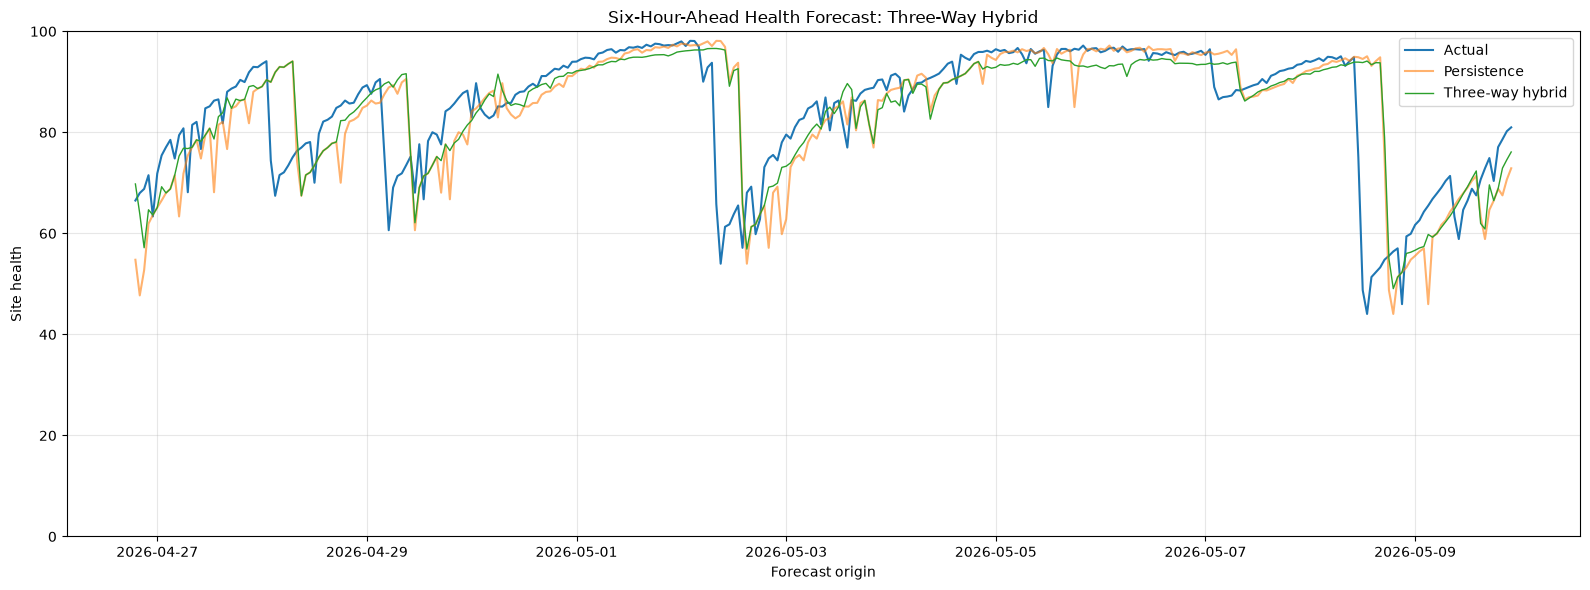

In [161]:
# The final forecasts plotted against the actual series.
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

plt.plot(
    perr_test.index,
    actual_future_health_test,
    label="Actual",
    linewidth=1.5
)

plt.plot(
    perr_test.index,
    persistence_predicted_health,
    label="Persistence",
    alpha=0.6
)

plt.plot(
    perr_test.index,
    three_way_hybrid_test_prediction,
    label="Three-way hybrid",
    linewidth=1
)

plt.title(
    "Six-Hour-Ahead Health Forecast: "
    "Three-Way Hybrid"
)

plt.xlabel("Forecast origin")
plt.ylabel("Site health")
plt.ylim(0, 100)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [162]:
#XGBOOST 
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

required_objects = [
    "X_train_expanded",
    "X_validation_expanded",
    "X_test_expanded",
    "y_train_expanded",
    "y_validation_expanded",
    "y_test_expanded",
    "expanded_validation_data",
    "expanded_test_data"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        "Missing required notebook objects: "
        + ", ".join(missing_objects)
    )

print("[OK] Required forecasting objects exist.")

[OK] Required forecasting objects exist.


In [163]:
# Evaluation helper for this section. NOTE: this redefines
# evaluate_delta_forecast with a DIFFERENT argument order from the
# earlier version - running cells out of order will silently mis-evaluate.
def evaluate_delta_forecast(
    model_name,
    actual_future_health,
    current_health,
    predicted_delta
):
    actual_future_health = np.asarray(
        actual_future_health,
        dtype=float
    )

    current_health = np.asarray(
        current_health,
        dtype=float
    )

    predicted_delta = np.asarray(
        predicted_delta,
        dtype=float
    )

    predicted_future_health = np.clip(
        current_health + predicted_delta,
        0,
        100
    )

    actual_delta = (
        actual_future_health
        - current_health
    )

    return {
        "model": model_name,

        "MAE": mean_absolute_error(
            actual_future_health,
            predicted_future_health
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                actual_future_health,
                predicted_future_health
            )
        ),

        "R2": r2_score(
            actual_future_health,
            predicted_future_health
        ),

        "delta_MAE": mean_absolute_error(
            actual_delta,
            predicted_delta
        ),

        "predicted_health":
            predicted_future_health,

        "predicted_delta":
            predicted_delta
    }

# Remove duplicate feature names
X_train_xgb = X_train_expanded.loc[
    :,
    ~X_train_expanded.columns.duplicated()
].copy()

X_validation_xgb = X_validation_expanded[
    X_train_xgb.columns
].copy()

X_test_xgb = X_test_expanded[
    X_train_xgb.columns
].copy()

# Replace infinity
for frame in [
    X_train_xgb,
    X_validation_xgb,
    X_test_xgb
]:
    frame.replace(
        [np.inf, -np.inf],
        np.nan,
        inplace=True
    )

# Training medians only
xgb_training_medians = (
    X_train_xgb
    .median(numeric_only=True)
)

valid_xgb_features = (
    xgb_training_medians[
        xgb_training_medians.notna()
    ]
    .index
    .tolist()
)

X_train_xgb = (
    X_train_xgb[
        valid_xgb_features
    ]
    .fillna(
        xgb_training_medians[
            valid_xgb_features
        ]
    )
)

X_validation_xgb = (
    X_validation_xgb[
        valid_xgb_features
    ]
    .fillna(
        xgb_training_medians[
            valid_xgb_features
        ]
    )
)

X_test_xgb = (
    X_test_xgb[
        valid_xgb_features
    ]
    .fillna(
        xgb_training_medians[
            valid_xgb_features
        ]
    )
)

print("Training shape:", X_train_xgb.shape)
print("Validation shape:", X_validation_xgb.shape)
print("Test shape:", X_test_xgb.shape)

assert X_train_xgb.isna().sum().sum() == 0
assert X_validation_xgb.isna().sum().sum() == 0
assert X_test_xgb.isna().sum().sum() == 0

Training shape: (1470, 1100)
Validation shape: (315, 1100)
Test shape: (316, 1100)


In [164]:
# XGBoost on the delta target. The hyperparameters are deliberately
# conservative (shallow trees, strong regularisation, heavy subsampling)
# because the dataset is small and the events of interest are rare.
xgb_delta_model = XGBRegressor(
    objective="reg:squarederror",

    n_estimators=2000,
    learning_rate=0.02,

    max_depth=4,
    min_child_weight=8,

    subsample=0.80,
    colsample_bytree=0.70,

    reg_alpha=1.0,
    reg_lambda=10.0,

    tree_method="hist",
    eval_metric="mae",
    early_stopping_rounds=100,

    random_state=42,
    n_jobs=-1
)

xgb_delta_model.fit(
    X_train_xgb,
    y_train_expanded,

    eval_set=[
        (
            X_validation_xgb,
            y_validation_expanded
        )
    ],

    verbose=False
)

print(
    "Best iteration:",
    xgb_delta_model.best_iteration
)

print(
    "Best validation score:",
    xgb_delta_model.best_score
)
xgb_validation_delta = (
    xgb_delta_model.predict(
        X_validation_xgb
    )
)

xgb_test_delta = (
    xgb_delta_model.predict(
        X_test_xgb
    )
)

xgb_validation_result = evaluate_delta_forecast(
    model_name="XGBoost delta",
    actual_future_health=expanded_validation_data[
        "target_health_6h"
    ],
    current_health=expanded_validation_data[
        "overall_site_health"
    ],
    predicted_delta=xgb_validation_delta
)

xgb_test_result = evaluate_delta_forecast(
    model_name="XGBoost delta",
    actual_future_health=expanded_test_data[
        "target_health_6h"
    ],
    current_health=expanded_test_data[
        "overall_site_health"
    ],
    predicted_delta=xgb_test_delta
)

display(
    pd.DataFrame([
        {
            key: value
            for key, value
            in xgb_validation_result.items()
            if key not in [
                "predicted_health",
                "predicted_delta"
            ]
        },
        {
            key: value
            for key, value
            in xgb_test_result.items()
            if key not in [
                "predicted_health",
                "predicted_delta"
            ]
        }
    ]).assign(
        split=[
            "validation",
            "test"
        ]
    )
)

Best iteration: 20
Best validation score: 6.376842022320581


,model,MAE,RMSE,R2,delta_MAE,split
0,XGBoost delta,6.376842,9.619798,0.585173,6.376842,validation
1,XGBoost delta,5.795466,9.720497,0.349659,5.795466,test


In [165]:
# Feature importances, then the same size sweep as before to find how
# many features XGBoost actually needs.
xgb_feature_importance = (
    pd.DataFrame({
        "feature": X_train_xgb.columns,
        "importance":
            xgb_delta_model.feature_importances_
    })
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    xgb_feature_importance.head(40)
)
XGB_FEATURE_COUNTS = [
    20,
    50,
    100,
    200
]

xgb_selected_models = {}
xgb_validation_rows = []

for feature_count in XGB_FEATURE_COUNTS:

    feature_count = min(
        feature_count,
        len(xgb_feature_importance)
    )

    selected_features = (
        xgb_feature_importance
        .head(feature_count)["feature"]
        .tolist()
    )

    model = XGBRegressor(
        objective="reg:squarederror",

        n_estimators=2000,
        learning_rate=0.02,

        max_depth=3,
        min_child_weight=8,

        subsample=0.80,
        colsample_bytree=0.80,

        reg_alpha=1.0,
        reg_lambda=10.0,

        tree_method="hist",
        eval_metric="mae",
        early_stopping_rounds=100,

        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_xgb[selected_features],
        y_train_expanded,

        eval_set=[
            (
                X_validation_xgb[
                    selected_features
                ],
                y_validation_expanded
            )
        ],

        verbose=False
    )

    validation_delta = model.predict(
        X_validation_xgb[
            selected_features
        ]
    )

    result = evaluate_delta_forecast(
        model_name=(
            f"XGBoost top {feature_count}"
        ),
        actual_future_health=(
            expanded_validation_data[
                "target_health_6h"
            ]
        ),
        current_health=(
            expanded_validation_data[
                "overall_site_health"
            ]
        ),
        predicted_delta=validation_delta
    )

    xgb_validation_rows.append({
        "model": result["model"],
        "feature_count": feature_count,
        "MAE": result["MAE"],
        "RMSE": result["RMSE"],
        "R2": result["R2"],
        "delta_MAE": result["delta_MAE"],
        "best_iteration":
            model.best_iteration
    })

    xgb_selected_models[
        feature_count
    ] = {
        "model": model,
        "features": selected_features
    }

xgb_validation_comparison = (
    pd.DataFrame(xgb_validation_rows)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(xgb_validation_comparison)

,feature,importance
0,energy_risk_score_rollmax_6h,0.019612
1,energy_risk_score_calibrated_lag_1h,0.019439
2,interaction_environmental_energy_risk,0.009786
3,battery_risk_score_lag_24h,0.009467
4,battery_anomaly_burden_slope_6h,0.008804
5,energy_risk_score_calibrated_rollmax_6h,0.008705
6,energy_anomaly_burden_lag_2h,0.008421
7,health_lag_48h,0.008140
8,environmental_base_risk_rollrange_24h,0.007531
9,energy_anomaly_burden_rollmean_12h,0.007498


,model,feature_count,MAE,RMSE,R2,delta_MAE,best_iteration
0,XGBoost top 20,20,5.790683,9.445273,0.600088,5.790683,390
1,XGBoost top 200,200,6.315020,9.579776,0.588617,6.315020,37
2,XGBoost top 100,100,6.358365,9.607620,0.586222,6.358365,22
3,XGBoost top 50,50,6.418438,9.606987,0.586277,6.418438,20


In [166]:
# Keep the best feature count from validation and evaluate it on test.
best_xgb_feature_count = int(
    xgb_validation_comparison
    .iloc[0]["feature_count"]
)

best_xgb_model = (
    xgb_selected_models[
        best_xgb_feature_count
    ]["model"]
)

best_xgb_features = (
    xgb_selected_models[
        best_xgb_feature_count
    ]["features"]
)

best_xgb_test_delta = (
    best_xgb_model.predict(
        X_test_xgb[
            best_xgb_features
        ]
    )
)

best_xgb_test_result = evaluate_delta_forecast(
    model_name=(
        f"XGBoost top "
        f"{best_xgb_feature_count}"
    ),
    actual_future_health=expanded_test_data[
        "target_health_6h"
    ],
    current_health=expanded_test_data[
        "overall_site_health"
    ],
    predicted_delta=best_xgb_test_delta
)

best_xgb_test_health = (
    best_xgb_test_result[
        "predicted_health"
    ]
)

display(
    pd.DataFrame([{
        key: value
        for key, value
        in best_xgb_test_result.items()
        if key not in [
            "predicted_health",
            "predicted_delta"
        ]
    }])
)

,model,MAE,RMSE,R2,delta_MAE
0,XGBoost top 20,5.032528,9.386943,0.393526,5.032528


In [167]:
#lightGBM
lightgbm_delta_model = LGBMRegressor(
    objective="regression_l1",

    n_estimators=800,
    learning_rate=0.02,

    num_leaves=15,
    max_depth=4,
    min_child_samples=20,

    subsample=0.80,
    colsample_bytree=0.70,

    reg_alpha=1.0,
    reg_lambda=10.0,

    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lightgbm_delta_model.fit(
    X_train_xgb[
        best_xgb_features
    ],
    y_train_expanded
)

,num_leaves,15
,max_depth,4
,learning_rate,0.02
,n_estimators,800
,objective,'regression_l1'
,subsample,0.8
,colsample_bytree,0.7
,reg_alpha,1.0
,reg_lambda,10.0
,random_state,42
,n_jobs,-1


In [168]:
# LightGBM on the same features, for comparison.
# regression_l1 optimises MAE directly, which matches the reported metric.
lightgbm_validation_delta = (
    lightgbm_delta_model.predict(
        X_validation_xgb[
            best_xgb_features
        ]
    )
)

lightgbm_test_delta = (
    lightgbm_delta_model.predict(
        X_test_xgb[
            best_xgb_features
        ]
    )
)

lightgbm_validation_result = (
    evaluate_delta_forecast(
        model_name="LightGBM delta",
        actual_future_health=(
            expanded_validation_data[
                "target_health_6h"
            ]
        ),
        current_health=(
            expanded_validation_data[
                "overall_site_health"
            ]
        ),
        predicted_delta=(
            lightgbm_validation_delta
        )
    )
)

lightgbm_test_result = (
    evaluate_delta_forecast(
        model_name="LightGBM delta",
        actual_future_health=(
            expanded_test_data[
                "target_health_6h"
            ]
        ),
        current_health=(
            expanded_test_data[
                "overall_site_health"
            ]
        ),
        predicted_delta=(
            lightgbm_test_delta
        )
    )
)

lightgbm_test_health = (
    lightgbm_test_result[
        "predicted_health"
    ]
)

display(
    pd.DataFrame([
        {
            "split": "validation",
            "model": "LightGBM delta",
            "MAE":
                lightgbm_validation_result["MAE"],
            "RMSE":
                lightgbm_validation_result["RMSE"],
            "R2":
                lightgbm_validation_result["R2"],
            "delta_MAE":
                lightgbm_validation_result[
                    "delta_MAE"
                ]
        },
        {
            "split": "test",
            "model": "LightGBM delta",
            "MAE":
                lightgbm_test_result["MAE"],
            "RMSE":
                lightgbm_test_result["RMSE"],
            "R2":
                lightgbm_test_result["R2"],
            "delta_MAE":
                lightgbm_test_result[
                    "delta_MAE"
                ]
        }
    ])
)

,split,model,MAE,RMSE,R2,delta_MAE
0,validation,LightGBM delta,5.835015,9.667342,0.581062,5.835015
1,test,LightGBM delta,5.025411,9.745828,0.346265,5.025411


In [169]:
# ============================================================
# 25. CLASSICAL TIME-SERIES BASELINE (AutoReg)
# ============================================================
# A pure autoregressive model on the score alone, with no engineered
# features: it answers whether all the feature work above buys anything
# over simply extrapolating the series. Forecasts are produced by rolling
# refit so no future point is ever used.
from statsmodels.tsa.ar_model import AutoReg
health_series = (
    forecast_data[
        "overall_site_health"
    ]
    .dropna()
    .astype(float)
    .sort_index()
)

print(
    "Health series:",
    health_series.shape
)

print(
    health_series.index.min(),
    "->",
    health_series.index.max()
)
def rolling_autoreg_forecast(
    full_series,
    test_indices,
    forecast_horizon=6,
    lags=48,
    minimum_training_rows=200
):
    predictions = []
    actual_values = []
    valid_indices = []

    for forecast_origin in test_indices:

        origin_position = (
            full_series.index.get_loc(
                forecast_origin
            )
        )

        target_position = (
            origin_position
            + forecast_horizon
        )

        if target_position >= len(full_series):
            continue

        training_series = (
            full_series.iloc[
                :origin_position + 1
            ]
        )

        if len(training_series) < (
            minimum_training_rows + lags
        ):
            continue

        try:
            model = AutoReg(
                training_series,
                lags=lags,
                trend="ct",
                old_names=False
            )

            fitted_model = model.fit()

            forecast = fitted_model.predict(
                start=len(training_series),
                end=(
                    len(training_series)
                    + forecast_horizon
                    - 1
                ),
                dynamic=False
            )

            predicted_value = float(
                forecast.iloc[-1]
            )

            actual_value = float(
                full_series.iloc[
                    target_position
                ]
            )

            predictions.append(
                np.clip(
                    predicted_value,
                    0,
                    100
                )
            )

            actual_values.append(
                actual_value
            )

            valid_indices.append(
                forecast_origin
            )

        except Exception as error:
            print(
                "Skipped",
                forecast_origin,
                "because:",
                error
            )

    return pd.DataFrame(
        {
            "actual_health":
                actual_values,
            "predicted_health":
                predictions
        },
        index=valid_indices
    )
AUTOREG_LAGS = [
    6,
    12,
    24,
    48,
    72
]

autoreg_results = {}
autoreg_comparison_rows = []

autoreg_validation_indices = (
    expanded_validation_data.index
)

for lag_count in AUTOREG_LAGS:

    result_frame = (
        rolling_autoreg_forecast(
            full_series=health_series,
            test_indices=(
                autoreg_validation_indices
            ),
            forecast_horizon=6,
            lags=lag_count
        )
    )

    mae = mean_absolute_error(
        result_frame["actual_health"],
        result_frame["predicted_health"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            result_frame["actual_health"],
            result_frame["predicted_health"]
        )
    )

    r2 = r2_score(
        result_frame["actual_health"],
        result_frame["predicted_health"]
    )

    autoreg_comparison_rows.append({
        "lags": lag_count,
        "validation_MAE": mae,
        "validation_RMSE": rmse,
        "validation_R2": r2,
        "rows": len(result_frame)
    })

    autoreg_results[
        lag_count
    ] = result_frame

autoreg_validation_comparison = (
    pd.DataFrame(
        autoreg_comparison_rows
    )
    .sort_values("validation_MAE")
    .reset_index(drop=True)
)

display(
    autoreg_validation_comparison
)

Health series: (2131,)
2026-02-10 10:00:00 -> 2026-05-10 04:00:00


,lags,validation_MAE,validation_RMSE,validation_R2,rows
0,72,6.161089,9.547731,0.591365,315
1,48,6.203367,9.550585,0.591120,315
2,24,6.299689,9.525923,0.593229,315
3,12,6.350324,9.521083,0.593642,315
4,6,6.398415,9.549357,0.591225,315


In [170]:
# Best lag order from validation, applied to the test period.
best_autoreg_lags = int(
    autoreg_validation_comparison
    .iloc[0]["lags"]
)

autoreg_test_frame = (
    rolling_autoreg_forecast(
        full_series=health_series,
        test_indices=(
            expanded_test_data.index
        ),
        forecast_horizon=6,
        lags=best_autoreg_lags
    )
)

autoreg_test_result = {
    "model":
        f"AutoReg({best_autoreg_lags})",

    "MAE": mean_absolute_error(
        autoreg_test_frame[
            "actual_health"
        ],
        autoreg_test_frame[
            "predicted_health"
        ]
    ),

    "RMSE": np.sqrt(
        mean_squared_error(
            autoreg_test_frame[
                "actual_health"
            ],
            autoreg_test_frame[
                "predicted_health"
            ]
        )
    ),

    "R2": r2_score(
        autoreg_test_frame[
            "actual_health"
        ],
        autoreg_test_frame[
            "predicted_health"
        ]
    )
}

display(
    pd.DataFrame([
        autoreg_test_result
    ])
)

,model,MAE,RMSE,R2
0,AutoReg(72),5.358463,9.081367,0.432368


In [171]:
# Common ground for the final comparison: the same actual values, the
# same current values, the same persistence baseline for every model.
test_actual_health = (
    expanded_test_data[
        "target_health_6h"
    ].to_numpy()
)

test_current_health = (
    expanded_test_data[
        "overall_site_health"
    ].to_numpy()
)

persistence_test_result = {
    "model": "Persistence",

    "MAE": mean_absolute_error(
        test_actual_health,
        test_current_health
    ),

    "RMSE": np.sqrt(
        mean_squared_error(
            test_actual_health,
            test_current_health
        )
    ),

    "R2": r2_score(
        test_actual_health,
        test_current_health
    )
}
model_comparison_rows = [
    persistence_test_result,

    {
        "model":
            best_xgb_test_result["model"],
        "MAE":
            best_xgb_test_result["MAE"],
        "RMSE":
            best_xgb_test_result["RMSE"],
        "R2":
            best_xgb_test_result["R2"]
    },

    {
        "model": "LightGBM delta",
        "MAE":
            lightgbm_test_result["MAE"],
        "RMSE":
            lightgbm_test_result["RMSE"],
        "R2":
            lightgbm_test_result["R2"]
    },

    autoreg_test_result
]

time_series_model_comparison = (
    pd.DataFrame(
        model_comparison_rows
    )
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(time_series_model_comparison)

,model,MAE,RMSE,R2
0,LightGBM delta,5.025411,9.745828,0.346265
1,XGBoost top 20,5.032528,9.386943,0.393526
2,AutoReg(72),5.358463,9.081367,0.432368
3,Persistence,6.004433,10.028986,0.307726


In [172]:
# Conditional MAE: overall, and restricted to the major- and severe-drop
# hours. A model can win overall and still be useless where it counts.
actual_test_change = (
    test_actual_health
    - test_current_health
)

major_drop_mask = (
    actual_test_change <= -10
)

severe_drop_mask = (
    actual_test_change <= -20
)
def conditional_mae(
    actual,
    predicted,
    mask
):
    if mask.sum() == 0:
        return np.nan

    return mean_absolute_error(
        np.asarray(actual)[mask],
        np.asarray(predicted)[mask]
    )
drop_model_predictions = {
    "Persistence":
        test_current_health,

    best_xgb_test_result["model"]:
        best_xgb_test_health,

    "LightGBM delta":
        lightgbm_test_health
}

drop_performance_rows = []

for model_name, predictions in (
    drop_model_predictions.items()
):

    drop_performance_rows.append({
        "model": model_name,

        "overall_MAE":
            mean_absolute_error(
                test_actual_health,
                predictions
            ),

        "major_drop_MAE":
            conditional_mae(
                test_actual_health,
                predictions,
                major_drop_mask
            ),

        "severe_drop_MAE":
            conditional_mae(
                test_actual_health,
                predictions,
                severe_drop_mask
            ),

        "major_drop_count":
            int(major_drop_mask.sum()),

        "severe_drop_count":
            int(severe_drop_mask.sum())
    })

drop_performance_comparison = (
    pd.DataFrame(
        drop_performance_rows
    )
    .sort_values("overall_MAE")
)

display(
    drop_performance_comparison
)

,model,overall_MAE,major_drop_MAE,severe_drop_MAE,major_drop_count,severe_drop_count
2,LightGBM delta,5.025411,28.680253,33.454348,26,18
1,XGBoost top 20,5.032528,27.284373,31.843022,26,18
0,Persistence,6.004433,27.039293,31.948606,26,18


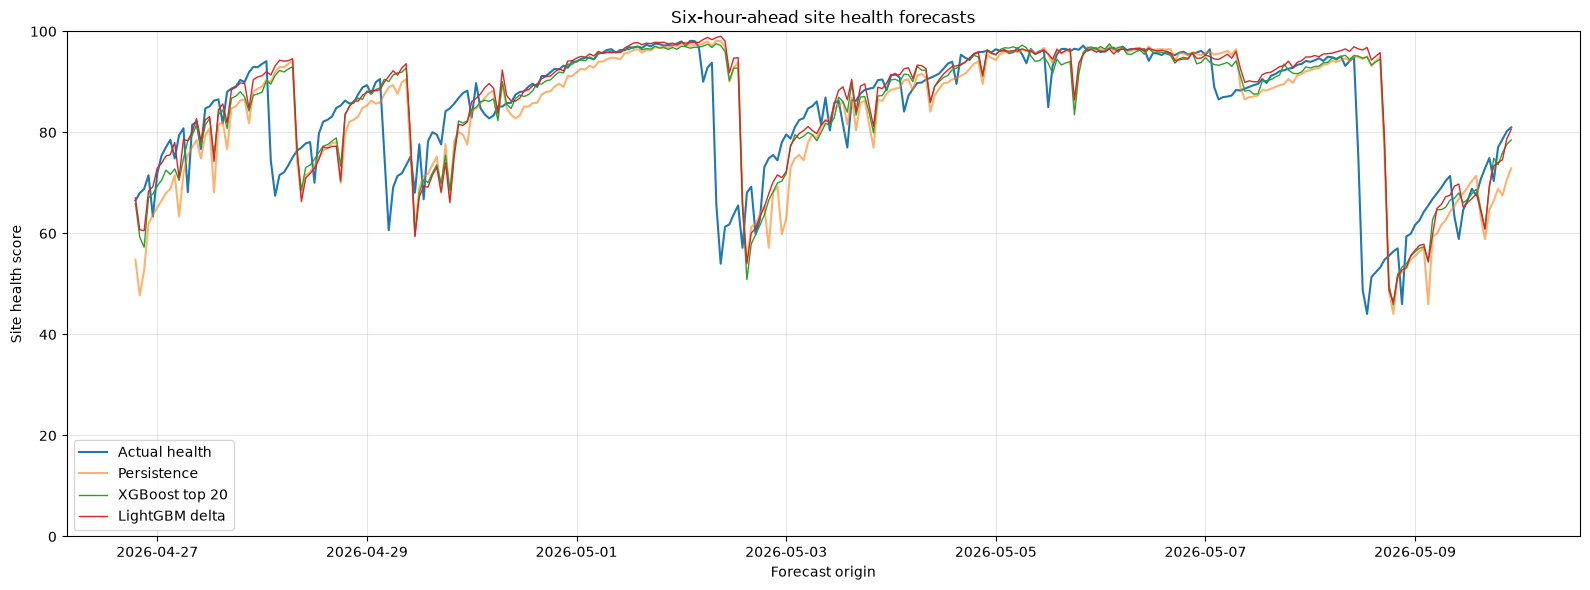

In [173]:
# Actual vs each model over the test period.
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

plt.plot(
    expanded_test_data.index,
    test_actual_health,
    label="Actual health",
    linewidth=1.5
)

plt.plot(
    expanded_test_data.index,
    test_current_health,
    label="Persistence",
    alpha=0.6
)

plt.plot(
    expanded_test_data.index,
    best_xgb_test_health,
    label=best_xgb_test_result["model"],
    linewidth=1
)

plt.plot(
    expanded_test_data.index,
    lightgbm_test_health,
    label="LightGBM delta",
    linewidth=1
)

plt.title(
    "Six-hour-ahead site health forecasts"
)

plt.xlabel("Forecast origin")
plt.ylabel("Site health score")
plt.ylim(0, 100)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [174]:
# Cost-sensitive training: weight the training rows so the ones preceding
# a large drop count for more. The model gives up a little average
# accuracy in exchange for being better on the rare events.
train_actual_delta = np.asarray(
    y_train_expanded,
    dtype=float
)

validation_actual_delta = np.asarray(
    y_validation_expanded,
    dtype=float
)

xgb_sample_weights = np.ones(
    len(train_actual_delta),
    dtype=float
)

# Moderate deterioration
xgb_sample_weights[
    train_actual_delta <= -5
] = 2.0

# Major deterioration
xgb_sample_weights[
    train_actual_delta <= -10
] = 4.0

# Severe deterioration
xgb_sample_weights[
    train_actual_delta <= -20
] = 7.0

print(
    pd.Series(
        xgb_sample_weights
    ).value_counts().sort_index()
)
weighted_xgb_model = XGBRegressor(
    objective="reg:squarederror",

    n_estimators=2000,
    learning_rate=0.02,

    max_depth=3,
    min_child_weight=6,

    subsample=0.80,
    colsample_bytree=0.80,

    reg_alpha=1.0,
    reg_lambda=10.0,

    tree_method="hist",
    eval_metric="mae",
    early_stopping_rounds=100,

    random_state=42,
    n_jobs=-1
)

weighted_xgb_model.fit(
    X_train_xgb[
        best_xgb_features
    ],
    y_train_expanded,

    sample_weight=xgb_sample_weights,

    eval_set=[
        (
            X_validation_xgb[
                best_xgb_features
            ],
            y_validation_expanded
        )
    ],

    verbose=False
)

print(
    "Best iteration:",
    weighted_xgb_model.best_iteration
)

print(
    "Best validation score:",
    weighted_xgb_model.best_score
)
weighted_xgb_test_delta = (
    weighted_xgb_model.predict(
        X_test_xgb[
            best_xgb_features
        ]
    )
)

weighted_xgb_test_result = (
    evaluate_delta_forecast(
        model_name="Weighted XGBoost top 20",

        actual_future_health=(
            expanded_test_data[
                "target_health_6h"
            ]
        ),

        current_health=(
            expanded_test_data[
                "overall_site_health"
            ]
        ),

        predicted_delta=(
            weighted_xgb_test_delta
        )
    )
)

weighted_xgb_test_health = (
    weighted_xgb_test_result[
        "predicted_health"
    ]
)

display(
    pd.DataFrame([{
        key: value
        for key, value
        in weighted_xgb_test_result.items()
        if key not in [
            "predicted_health",
            "predicted_delta"
        ]
    }])
)

1.0    1242
2.0     119
4.0      70
7.0      39
Name: count, dtype: int64
Best iteration: 908
Best validation score: 5.906946348103266


,model,MAE,RMSE,R2,delta_MAE
0,Weighted XGBoost top 20,5.626396,9.638729,0.360554,5.626396


In [175]:
# Did the weighting pay off? Compared overall and per segment.
weighted_xgb_comparison = pd.DataFrame([
    {
        "model": "Persistence",

        "overall_MAE": mean_absolute_error(
            test_actual_health,
            test_current_health
        ),

        "major_drop_MAE": conditional_mae(
            test_actual_health,
            test_current_health,
            major_drop_mask
        ),

        "severe_drop_MAE": conditional_mae(
            test_actual_health,
            test_current_health,
            severe_drop_mask
        )
    },

    {
        "model": "XGBoost top 20",

        "overall_MAE": mean_absolute_error(
            test_actual_health,
            best_xgb_test_health
        ),

        "major_drop_MAE": conditional_mae(
            test_actual_health,
            best_xgb_test_health,
            major_drop_mask
        ),

        "severe_drop_MAE": conditional_mae(
            test_actual_health,
            best_xgb_test_health,
            severe_drop_mask
        )
    },

    {
        "model": "Weighted XGBoost top 20",

        "overall_MAE": mean_absolute_error(
            test_actual_health,
            weighted_xgb_test_health
        ),

        "major_drop_MAE": conditional_mae(
            test_actual_health,
            weighted_xgb_test_health,
            major_drop_mask
        ),

        "severe_drop_MAE": conditional_mae(
            test_actual_health,
            weighted_xgb_test_health,
            severe_drop_mask
        )
    }
]).sort_values(
    "overall_MAE"
)

display(weighted_xgb_comparison)

,model,overall_MAE,major_drop_MAE,severe_drop_MAE
1,XGBoost top 20,5.032528,27.284373,31.843022
2,Weighted XGBoost top 20,5.626396,26.550079,31.015012
0,Persistence,6.004433,27.039293,31.948606


In [176]:
# Control experiment: predict the absolute level directly instead of the
# delta, everything else unchanged, to isolate the effect of the delta
# framing itself.
y_train_direct = (
    expanded_train_data[
        "target_health_6h"
    ].to_numpy()
)

y_validation_direct = (
    expanded_validation_data[
        "target_health_6h"
    ].to_numpy()
)

y_test_direct = (
    expanded_test_data[
        "target_health_6h"
    ].to_numpy()
)

print(
    len(y_train_direct),
    len(y_validation_direct),
    len(y_test_direct)
)

assert len(y_train_direct) == len(X_train_xgb)
assert len(y_validation_direct) == len(X_validation_xgb)
assert len(y_test_direct) == len(X_test_xgb)

direct_xgb_model = XGBRegressor(
    objective="reg:squarederror",

    n_estimators=2000,
    learning_rate=0.02,

    max_depth=3,
    min_child_weight=8,

    subsample=0.80,
    colsample_bytree=0.80,

    reg_alpha=1.0,
    reg_lambda=10.0,

    tree_method="hist",
    eval_metric="mae",
    early_stopping_rounds=100,

    random_state=42,
    n_jobs=-1
)

direct_xgb_model.fit(
    X_train_xgb[
        best_xgb_features
    ],
    y_train_direct,

    eval_set=[
        (
            X_validation_xgb[
                best_xgb_features
            ],
            y_validation_direct
        )
    ],

    verbose=False
)

print(
    "Best iteration:",
    direct_xgb_model.best_iteration
)

print(
    "Best validation score:",
    direct_xgb_model.best_score
)

direct_xgb_test_health = np.clip(
    direct_xgb_model.predict(
        X_test_xgb[
            best_xgb_features
        ]
    ),
    0,
    100
)

direct_xgb_result = {
    "model": "Direct XGBoost top 20",

    "overall_MAE": mean_absolute_error(
        test_actual_health,
        direct_xgb_test_health
    ),

    "RMSE": np.sqrt(
        mean_squared_error(
            test_actual_health,
            direct_xgb_test_health
        )
    ),

    "R2": r2_score(
        test_actual_health,
        direct_xgb_test_health
    ),

    "major_drop_MAE": conditional_mae(
        test_actual_health,
        direct_xgb_test_health,
        major_drop_mask
    ),

    "severe_drop_MAE": conditional_mae(
        test_actual_health,
        direct_xgb_test_health,
        severe_drop_mask
    )
}

display(
    pd.DataFrame([
        direct_xgb_result
    ])
)

1470 315 316
Best iteration: 518
Best validation score: 5.759305851043217


,model,overall_MAE,RMSE,R2,major_drop_MAE,severe_drop_MAE
0,Direct XGBoost top 20,6.459268,10.594401,0.227467,27.130702,31.435246


In [177]:
# Softer weighting scheme (1.25 / 1.75 / ... instead of a hard cut), to
# see whether the gain came from the weighting or just from its severity.
soft_xgb_weights = np.ones(
    len(y_train_expanded),
    dtype=float
)

soft_xgb_weights[
    np.asarray(y_train_expanded) <= -5
] = 1.25

soft_xgb_weights[
    np.asarray(y_train_expanded) <= -10
] = 1.75

soft_xgb_weights[
    np.asarray(y_train_expanded) <= -20
] = 2.50

print(
    pd.Series(
        soft_xgb_weights
    ).value_counts().sort_index()
)

soft_weighted_xgb_model = XGBRegressor(
    objective="reg:squarederror",

    n_estimators=2000,
    learning_rate=0.02,

    max_depth=3,
    min_child_weight=8,

    subsample=0.80,
    colsample_bytree=0.80,

    reg_alpha=1.0,
    reg_lambda=10.0,

    tree_method="hist",
    eval_metric="mae",
    early_stopping_rounds=100,

    random_state=42,
    n_jobs=-1
)

soft_weighted_xgb_model.fit(
    X_train_xgb[
        best_xgb_features
    ],
    y_train_expanded,

    sample_weight=soft_xgb_weights,

    eval_set=[
        (
            X_validation_xgb[
                best_xgb_features
            ],
            y_validation_expanded
        )
    ],

    verbose=False
)
soft_weighted_xgb_delta = (
    soft_weighted_xgb_model.predict(
        X_test_xgb[
            best_xgb_features
        ]
    )
)

soft_weighted_xgb_health = np.clip(
    test_current_health
    + soft_weighted_xgb_delta,
    0,
    100
)

soft_weighted_result = {
    "model": "Soft-weighted XGBoost",

    "overall_MAE": mean_absolute_error(
        test_actual_health,
        soft_weighted_xgb_health
    ),

    "RMSE": np.sqrt(
        mean_squared_error(
            test_actual_health,
            soft_weighted_xgb_health
        )
    ),

    "R2": r2_score(
        test_actual_health,
        soft_weighted_xgb_health
    ),

    "major_drop_MAE": conditional_mae(
        test_actual_health,
        soft_weighted_xgb_health,
        major_drop_mask
    ),

    "severe_drop_MAE": conditional_mae(
        test_actual_health,
        soft_weighted_xgb_health,
        severe_drop_mask
    )
}

1.00    1242
1.25     119
1.75      70
2.50      39
Name: count, dtype: int64


In [178]:
# Results of that variant against the same baselines.
next_xgb_comparison = pd.DataFrame([
    {
        "model": "Persistence",
        "overall_MAE": mean_absolute_error(
            test_actual_health,
            test_current_health
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                test_actual_health,
                test_current_health
            )
        ),
        "R2": r2_score(
            test_actual_health,
            test_current_health
        ),
        "major_drop_MAE": conditional_mae(
            test_actual_health,
            test_current_health,
            major_drop_mask
        ),
        "severe_drop_MAE": conditional_mae(
            test_actual_health,
            test_current_health,
            severe_drop_mask
        )
    },

    {
        "model": "XGBoost top 20",
        "overall_MAE": mean_absolute_error(
            test_actual_health,
            best_xgb_test_health
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                test_actual_health,
                best_xgb_test_health
            )
        ),
        "R2": r2_score(
            test_actual_health,
            best_xgb_test_health
        ),
        "major_drop_MAE": conditional_mae(
            test_actual_health,
            best_xgb_test_health,
            major_drop_mask
        ),
        "severe_drop_MAE": conditional_mae(
            test_actual_health,
            best_xgb_test_health,
            severe_drop_mask
        )
    },

    direct_xgb_result,
    soft_weighted_result

]).sort_values(
    "overall_MAE"
).reset_index(drop=True)

display(next_xgb_comparison)

,model,overall_MAE,RMSE,R2,major_drop_MAE,severe_drop_MAE
0,XGBoost top 20,5.032528,9.386943,0.393526,27.284373,31.843022
1,Soft-weighted XGBoost,5.281674,9.409921,0.390553,26.775315,31.322008
2,Persistence,6.004433,10.028986,0.307726,27.039293,31.948606
3,Direct XGBoost top 20,6.459268,10.594401,0.227467,27.130702,31.435246


In [179]:
#models tried Linear Regression
# Linear Regression HistGradientBoosting Random Forest LightGBM XGBoost AutoReg weighted XGBoost direct XGBoost

In [180]:
# ============================================================
# 26. VERSION 2: REBUILDING THE FEATURE SET FROM SCRATCH
# The expanded set grew to hundreds of mostly redundant columns. V2
# starts again from a deliberately small, hand-picked set.
# ============================================================
# Lags, changes and rolling statistics of the overall score only.
HEALTH_LAGS = [
    1,
    2,
    3,
    6,
    12,
    24
]

for lag in HEALTH_LAGS:

    forecast_data[
        f"health_lag_{lag}"
    ] = (
        forecast_data["overall_site_health"]
        .shift(lag)
    )
forecast_data["health_change_1h"] = (
    forecast_data["overall_site_health"]
    - forecast_data["health_lag_1"]
)

forecast_data["health_change_3h"] = (
    forecast_data["overall_site_health"]
    - forecast_data["health_lag_3"]
)

forecast_data["health_change_6h"] = (
    forecast_data["overall_site_health"]
    - forecast_data["health_lag_6"]
)

forecast_data["health_change_12h"] = (
    forecast_data["overall_site_health"]
    - forecast_data["health_lag_12"]
)

forecast_data["health_change_24h"] = (
    forecast_data["overall_site_health"]
    - forecast_data["health_lag_24"]
)

forecast_data["health_std_6h"] = (
    forecast_data["overall_site_health"]
    .rolling(6)
    .std()
)

forecast_data["health_std_12h"] = (
    forecast_data["overall_site_health"]
    .rolling(12)
    .std()
)

forecast_data["health_std_24h"] = (
    forecast_data["overall_site_health"]
    .rolling(24)
    .std()
)

forecast_data["health_mean_6h"] = (
    forecast_data["overall_site_health"]
    .rolling(6)
    .mean()
)

forecast_data["health_mean_12h"] = (
    forecast_data["overall_site_health"]
    .rolling(12)
    .mean()
)

forecast_data["health_mean_24h"] = (
    forecast_data["overall_site_health"]
    .rolling(24)
    .mean()
)

forecast_data["health_min_24h"] = (
    forecast_data["overall_site_health"]
    .rolling(24)
    .min()
)

forecast_data["health_max_24h"] = (
    forecast_data["overall_site_health"]
    .rolling(24)
    .max()
)

forecast_data["health_range_24h"] = (
    forecast_data["health_max_24h"]
    - forecast_data["health_min_24h"]
)

forecast_data["health_slope_6h"] = (
    forecast_data["health_change_6h"] / 6
)

forecast_data["health_slope_12h"] = (
    forecast_data["health_change_12h"] / 12
)

forecast_data["health_slope_24h"] = (
    forecast_data["health_change_24h"] / 24
)

health_history_features = [
    c
    for c in forecast_data.columns
    if c.startswith("health_")
]

expanded_feature_columns = list(
    dict.fromkeys(
        expanded_feature_columns
        + health_history_features
    )
)

print(
    "Added",
    len(health_history_features),
    "health history features."
)

Added 41 health history features.


In [181]:
# ==========================================================
# Remove previous dynamic engineered features
# ==========================================================

REMOVE_PREFIXES = [
    "lag_",
    "rolling_",
    "expanding_",
    "ewm_",
    "diff_",
    "pct_change_",
    "interaction_",
    "poly_",
    "dynamic_",
    "trend_",
    "window_"
]

REMOVE_CONTAINS = [
    "_lag",
    "_rolling",
    "_expanding",
    "_interaction",
    "_poly"
]

columns_to_remove = []

for col in forecast_data.columns:

    if any(col.startswith(p) for p in REMOVE_PREFIXES):
        columns_to_remove.append(col)
        continue

    if any(x in col for x in REMOVE_CONTAINS):
        columns_to_remove.append(col)

columns_to_remove = sorted(set(columns_to_remove))

forecast_data = forecast_data.drop(
    columns=columns_to_remove,
    errors="ignore"
)

print(f"Removed {len(columns_to_remove)} old engineered features.")

Removed 189 old engineered features.


In [182]:
# Rebuild the V2 features on the cleaned frame (the cell above ran
# before the old engineered columns were removed).
HEALTH_LAGS = [1,2,3,6,12,24]

for lag in HEALTH_LAGS:

    forecast_data[f"health_lag_{lag}"] = (
        forecast_data["overall_site_health"]
        .shift(lag)
    )

forecast_data["health_change_1h"] = (
    forecast_data["overall_site_health"]
    - forecast_data["health_lag_1"]
)

forecast_data["health_change_3h"] = (
    forecast_data["overall_site_health"]
    - forecast_data["health_lag_3"]
)

forecast_data["health_change_6h"] = (
    forecast_data["overall_site_health"]
    - forecast_data["health_lag_6"]
)

forecast_data["health_change_12h"] = (
    forecast_data["overall_site_health"]
    - forecast_data["health_lag_12"]
)

forecast_data["health_change_24h"] = (
    forecast_data["overall_site_health"]
    - forecast_data["health_lag_24"]
)

for window in [6,12,24]:

    forecast_data[f"health_mean_{window}h"] = (
        forecast_data["overall_site_health"]
        .rolling(window)
        .mean()
    )

    forecast_data[f"health_std_{window}h"] = (
        forecast_data["overall_site_health"]
        .rolling(window)
        .std()
    )

    forecast_data[f"health_min_{window}h"] = (
        forecast_data["overall_site_health"]
        .rolling(window)
        .min()
    )

    forecast_data[f"health_max_{window}h"] = (
        forecast_data["overall_site_health"]
        .rolling(window)
        .max()
    )

forecast_data["health_range_24h"] = (
    forecast_data["health_max_24h"]
    - forecast_data["health_min_24h"]
)

forecast_data["health_slope_6h"] = (
    forecast_data["health_change_6h"]/6
)

forecast_data["health_slope_12h"] = (
    forecast_data["health_change_12h"]/12
)

forecast_data["health_slope_24h"] = (
    forecast_data["health_change_24h"]/24
)
# ==========================================================
# Version 2 feature set
# ==========================================================

exclude_columns = {

    "target_health_6h",
    "target_health_change_6h",

    "date",
    "timestamp",
    "datetime"
}

feature_columns_v2 = [

    c
    for c in forecast_data.columns

    if c not in exclude_columns
    and forecast_data[c].dtype != "O"
]

print("Number of V2 features:", len(feature_columns_v2))

Number of V2 features: 1008


In [183]:
# The V2 feature set: current subsystem values plus the freshly built
# dynamics, listed explicitly rather than collected by pattern.
BASE_FEATURES = [
    # Environmental
    "environmental_health_score",
    "environmental_risk_score",
    "environmental_base_risk",
    "environmental_anomaly_burden",
    "environmental_pm_risk",

    # Energy
    "energy_health_score",
    "energy_risk_score",
    "energy_base_risk",
    "energy_anomaly_burden",
    "energy_pm_risk",

    # Battery
    "battery_health_score",
    "battery_risk_score",
    "battery_base_risk",
    "battery_anomaly_burden",
    "battery_pm_risk",

    # Overall
    "overall_site_health",
    "overall_site_risk",

    # Explainability
    "environmental_contribution",
    "energy_contribution",
    "battery_contribution",

    # Calendar
    "hour",
    "day",
    "month"
]

TEMPORAL_FEATURES = [
    "health_lag_1",
    "health_lag_2",
    "health_lag_3",
    "health_lag_6",
    "health_lag_12",
    "health_lag_24",

    "health_change_1h",
    "health_change_3h",
    "health_change_6h",
    "health_change_12h",
    "health_change_24h",

    "health_mean_6h",
    "health_mean_12h",
    "health_mean_24h",

    "health_std_6h",
    "health_std_12h",
    "health_std_24h",

    "health_min_6h",
    "health_min_12h",
    "health_min_24h",

    "health_max_6h",
    "health_max_12h",
    "health_max_24h",

    "health_range_24h",

    "health_slope_6h",
    "health_slope_12h",
    "health_slope_24h"
]
feature_columns_v2 = [
    c
    for c in BASE_FEATURES + TEMPORAL_FEATURES
    if c in forecast_data.columns
]

print(f"Number of V2 features: {len(feature_columns_v2)}")
print(feature_columns_v2)

forecast_model_data = (
    forecast_data[
        feature_columns_v2
        + [
            "target_health_6h",
            "target_health_change_6h"
        ]
    ]
    .dropna()
    .copy()
)

print(forecast_model_data.shape)

Number of V2 features: 49
['environmental_health_score', 'environmental_risk_score', 'environmental_base_risk', 'environmental_anomaly_burden', 'environmental_pm_risk', 'energy_health_score', 'energy_risk_score', 'energy_base_risk', 'energy_anomaly_burden', 'energy_pm_risk', 'battery_health_score', 'battery_risk_score', 'battery_base_risk', 'battery_anomaly_burden', 'battery_pm_risk', 'overall_site_health', 'overall_site_risk', 'environmental_contribution', 'energy_contribution', 'battery_contribution', 'hour', 'month', 'health_lag_1', 'health_lag_2', 'health_lag_3', 'health_lag_6', 'health_lag_12', 'health_lag_24', 'health_change_1h', 'health_change_3h', 'health_change_6h', 'health_change_12h', 'health_change_24h', 'health_mean_6h', 'health_mean_12h', 'health_mean_24h', 'health_std_6h', 'health_std_12h', 'health_std_24h', 'health_min_6h', 'health_min_12h', 'health_min_24h', 'health_max_6h', 'health_max_12h', 'health_max_24h', 'health_range_24h', 'health_slope_6h', 'health_slope_12h', 

In [184]:
# ============================================================
# Build clean Version 2 modelling dataset
# ============================================================

TARGET_COL = "target_health_change_6h"
CURRENT_HEALTH_COL = "overall_site_health"

required_columns = list(
    dict.fromkeys(
        feature_columns_v2
        + [TARGET_COL, "target_health_6h", CURRENT_HEALTH_COL]
    )
)

missing_columns = [
    col for col in required_columns
    if col not in forecast_data.columns
]

if missing_columns:
    raise KeyError(
        f"Missing required columns: {missing_columns}"
    )

forecast_model_data_v2 = (
    forecast_data[required_columns]
    .replace([np.inf, -np.inf], np.nan)
    .copy()
)

# Remove rows where the target is unavailable.
# Feature NaNs will be handled using training-set medians.
forecast_model_data_v2 = (
    forecast_model_data_v2
    .dropna(subset=[TARGET_COL, "target_health_6h"])
    .reset_index(drop=True)
)

print("Dataset shape:", forecast_model_data_v2.shape)
print("Number of features:", len(feature_columns_v2))

Dataset shape: (2125, 51)
Number of features: 49


In [185]:
# ============================================================
# Chronological split
# ============================================================

n_rows = len(forecast_model_data_v2)

train_end = int(n_rows * 0.70)
validation_end = int(n_rows * 0.85)

train_data_v2 = forecast_model_data_v2.iloc[:train_end].copy()

validation_data_v2 = forecast_model_data_v2.iloc[
    train_end:validation_end
].copy()

test_data_v2 = forecast_model_data_v2.iloc[
    validation_end:
].copy()

print("Train shape:", train_data_v2.shape)
print("Validation shape:", validation_data_v2.shape)
print("Test shape:", test_data_v2.shape)

print("\nSplit percentages:")
print(f"Train:      {len(train_data_v2) / n_rows:.1%}")
print(f"Validation: {len(validation_data_v2) / n_rows:.1%}")
print(f"Test:       {len(test_data_v2) / n_rows:.1%}")

Train shape: (1487, 51)
Validation shape: (319, 51)
Test shape: (319, 51)

Split percentages:
Train:      70.0%
Validation: 15.0%
Test:       15.0%


In [186]:
# ============================================================
# Create feature matrices and delta targets
# ============================================================

X_train_v2 = train_data_v2[feature_columns_v2].copy()
X_validation_v2 = validation_data_v2[feature_columns_v2].copy()
X_test_v2 = test_data_v2[feature_columns_v2].copy()

y_train_v2 = train_data_v2[TARGET_COL].copy()
y_validation_v2 = validation_data_v2[TARGET_COL].copy()
y_test_v2 = test_data_v2[TARGET_COL].copy()

# Remove duplicate columns, if any.
X_train_v2 = X_train_v2.loc[
    :, ~X_train_v2.columns.duplicated()
]

X_validation_v2 = X_validation_v2[
    X_train_v2.columns
]

X_test_v2 = X_test_v2[
    X_train_v2.columns
]

print("X train:", X_train_v2.shape)
print("X validation:", X_validation_v2.shape)
print("X test:", X_test_v2.shape)

print("\nTarget summary:")
print(y_train_v2.describe())

X train: (1487, 49)
X validation: (319, 49)
X test: (319, 49)

Target summary:
count    1487.000000
mean       -0.079674
std         8.076227
min       -53.933327
25%        -1.508473
50%         0.598268
75%         3.071331
max        29.522245
Name: target_health_change_6h, dtype: float64


In [187]:
# ============================================================
# Training-only median imputation
# ============================================================

train_medians_v2 = X_train_v2.median(numeric_only=True)

valid_features_v2 = [
    column
    for column in train_medians_v2.index
    if pd.notna(train_medians_v2.loc[column])
]

X_train_v2 = X_train_v2[valid_features_v2].copy()
X_validation_v2 = X_validation_v2[valid_features_v2].copy()
X_test_v2 = X_test_v2[valid_features_v2].copy()

X_train_v2 = X_train_v2.fillna(train_medians_v2[valid_features_v2])
X_validation_v2 = X_validation_v2.fillna(
    train_medians_v2[valid_features_v2]
)
X_test_v2 = X_test_v2.fillna(
    train_medians_v2[valid_features_v2]
)

print("Final number of usable features:", len(valid_features_v2))

print("Remaining train NaNs:", X_train_v2.isna().sum().sum())
print(
    "Remaining validation NaNs:",
    X_validation_v2.isna().sum().sum()
)
print("Remaining test NaNs:", X_test_v2.isna().sum().sum())

Final number of usable features: 49
Remaining train NaNs: 0
Remaining validation NaNs: 0
Remaining test NaNs: 0


In [188]:
# ============================================================
# Initial XGBoost model: all V2 features
# ============================================================

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

xgb_v2_all = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=1.00,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb_v2_all.fit(
    X_train_v2,
    y_train_v2,
    eval_set=[
        (X_validation_v2, y_validation_v2)
    ],
    verbose=False
)

print("Best iteration:", xgb_v2_all.best_iteration)

Best iteration: 5


In [189]:
# ============================================================
# Validation evaluation
# ============================================================

validation_delta_pred_v2 = xgb_v2_all.predict(
    X_validation_v2
)

validation_current_health_v2 = validation_data_v2[
    CURRENT_HEALTH_COL
].to_numpy()

validation_actual_health_v2 = validation_data_v2[
    "target_health_6h"
].to_numpy()

validation_health_pred_v2 = (
    validation_current_health_v2
    + validation_delta_pred_v2
)

# Health scores must remain between 0 and 100.
validation_health_pred_v2 = np.clip(
    validation_health_pred_v2,
    0,
    100
)

validation_mae_v2 = mean_absolute_error(
    validation_actual_health_v2,
    validation_health_pred_v2
)

validation_rmse_v2 = np.sqrt(
    mean_squared_error(
        validation_actual_health_v2,
        validation_health_pred_v2
    )
)

validation_r2_v2 = r2_score(
    validation_actual_health_v2,
    validation_health_pred_v2
)

print("All-feature V2 validation results")
print(f"MAE:  {validation_mae_v2:.6f}")
print(f"RMSE: {validation_rmse_v2:.6f}")
print(f"R²:   {validation_r2_v2:.6f}")

All-feature V2 validation results
MAE:  7.003560
RMSE: 9.590937
R²:   0.593544


In [190]:
# ============================================================
# Extract top 30 features
# ============================================================

feature_importance_v2 = pd.DataFrame({
    "feature": X_train_v2.columns,
    "importance": xgb_v2_all.feature_importances_
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

TOP_N = min(30, len(feature_importance_v2))

top_features_v2 = (
    feature_importance_v2
    .head(TOP_N)["feature"]
    .tolist()
)

print(f"Top {TOP_N} selected features:\n")

display(
    feature_importance_v2.head(TOP_N)
)

Top 30 selected features:



,feature,importance
0,energy_health_score,0.047174
1,environmental_contribution,0.045382
2,health_mean_24h,0.044048
3,environmental_anomaly_burden,0.043222
4,environmental_pm_risk,0.042683
5,energy_risk_score,0.040431
6,health_change_24h,0.039605
7,environmental_health_score,0.038627
8,energy_base_risk,0.036846
9,health_min_12h,0.032988


In [191]:
# ============================================================
# Top-30 feature matrices
# ============================================================

X_train_top_v2 = X_train_v2[top_features_v2].copy()

X_validation_top_v2 = X_validation_v2[
    top_features_v2
].copy()

X_test_top_v2 = X_test_v2[top_features_v2].copy()

print("Train:", X_train_top_v2.shape)
print("Validation:", X_validation_top_v2.shape)
print("Test:", X_test_top_v2.shape)

Train: (1487, 30)
Validation: (319, 30)
Test: (319, 30)


In [192]:
# ============================================================
# Final candidate: XGBoost using top 30 V2 features
# ============================================================

xgb_v2_top30 = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=1.00,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb_v2_top30.fit(
    X_train_top_v2,
    y_train_v2,
    eval_set=[
        (X_validation_top_v2, y_validation_v2)
    ],
    verbose=False
)

print("Best iteration:", xgb_v2_top30.best_iteration)

Best iteration: 5


In [193]:
# ============================================================
# Final test evaluation
# ============================================================

test_delta_pred_v2 = xgb_v2_top30.predict(
    X_test_top_v2
)

test_current_health_v2 = test_data_v2[
    CURRENT_HEALTH_COL
].to_numpy()

test_actual_health_v2 = test_data_v2[
    "target_health_6h"
].to_numpy()

test_health_pred_v2 = (
    test_current_health_v2
    + test_delta_pred_v2
)

test_health_pred_v2 = np.clip(
    test_health_pred_v2,
    0,
    100
)

test_mae_v2 = mean_absolute_error(
    test_actual_health_v2,
    test_health_pred_v2
)

test_rmse_v2 = np.sqrt(
    mean_squared_error(
        test_actual_health_v2,
        test_health_pred_v2
    )
)

test_r2_v2 = r2_score(
    test_actual_health_v2,
    test_health_pred_v2
)

print("XGBoost V2 top-30 test results")
print(f"MAE:  {test_mae_v2:.6f}")
print(f"RMSE: {test_rmse_v2:.6f}")
print(f"R²:   {test_r2_v2:.6f}")

XGBoost V2 top-30 test results
MAE:  6.906935
RMSE: 9.879713
R²:   0.341083


In [194]:
# ============================================================
# Deterioration-event evaluation
# ============================================================

actual_test_delta_v2 = y_test_v2.to_numpy()

major_drop_mask_v2 = actual_test_delta_v2 <= -10
severe_drop_mask_v2 = actual_test_delta_v2 <= -20

major_drop_count_v2 = major_drop_mask_v2.sum()
severe_drop_count_v2 = severe_drop_mask_v2.sum()

major_drop_mae_v2 = (
    mean_absolute_error(
        test_actual_health_v2[major_drop_mask_v2],
        test_health_pred_v2[major_drop_mask_v2]
    )
    if major_drop_count_v2 > 0
    else np.nan
)

severe_drop_mae_v2 = (
    mean_absolute_error(
        test_actual_health_v2[severe_drop_mask_v2],
        test_health_pred_v2[severe_drop_mask_v2]
    )
    if severe_drop_count_v2 > 0
    else np.nan
)

print("Deterioration performance")
print(f"Major-drop observations:  {major_drop_count_v2}")
print(f"Major-drop MAE:           {major_drop_mae_v2:.6f}")
print(f"Severe-drop observations: {severe_drop_count_v2}")
print(f"Severe-drop MAE:          {severe_drop_mae_v2:.6f}")

Deterioration performance
Major-drop observations:  26
Major-drop MAE:           24.821998
Severe-drop observations: 18
Severe-drop MAE:          29.595160


In [195]:
# ============================================================
# Experiment comparison
# ============================================================

v2_result = pd.DataFrame({
    "model": ["XGBoost V2 top 30"],
    "overall_MAE": [test_mae_v2],
    "RMSE": [test_rmse_v2],
    "R2": [test_r2_v2],
    "major_drop_MAE": [major_drop_mae_v2],
    "severe_drop_MAE": [severe_drop_mae_v2]
})

previous_results = pd.DataFrame({
    "model": [
        "XGBoost top 20",
        "Soft-weighted XGBoost",
        "Persistence",
        "Direct XGBoost top 20"
    ],
    "overall_MAE": [
        5.032528,
        5.281674,
        6.004433,
        6.459268
    ],
    "RMSE": [
        9.386943,
        9.409921,
        10.028986,
        10.594401
    ],
    "R2": [
        0.393526,
        0.390553,
        0.307726,
        0.227467
    ],
    "major_drop_MAE": [
        27.284373,
        26.775315,
        27.039293,
        27.130702
    ],
    "severe_drop_MAE": [
        31.843022,
        31.322008,
        31.948606,
        31.435246
    ]
})

comparison_v2 = (
    pd.concat(
        [previous_results, v2_result],
        ignore_index=True
    )
    .sort_values("overall_MAE")
    .reset_index(drop=True)
)

display(comparison_v2)

,model,overall_MAE,RMSE,R2,major_drop_MAE,severe_drop_MAE
0,XGBoost top 20,5.032528,9.386943,0.393526,27.284373,31.843022
1,Soft-weighted XGBoost,5.281674,9.409921,0.390553,26.775315,31.322008
2,Persistence,6.004433,10.028986,0.307726,27.039293,31.948606
3,Direct XGBoost top 20,6.459268,10.594401,0.227467,27.130702,31.435246
4,XGBoost V2 top 30,6.906935,9.879713,0.341083,24.821998,29.595160


In [196]:
# ============================================================
# Test the all-feature V2 XGBoost model
# ============================================================

all_v2_test_delta_pred = xgb_v2_all.predict(X_test_v2)

all_v2_test_health_pred = (
    test_current_health_v2
    + all_v2_test_delta_pred
)

all_v2_test_health_pred = np.clip(
    all_v2_test_health_pred,
    0,
    100
)

all_v2_mae = mean_absolute_error(
    test_actual_health_v2,
    all_v2_test_health_pred
)

all_v2_rmse = np.sqrt(
    mean_squared_error(
        test_actual_health_v2,
        all_v2_test_health_pred
    )
)

all_v2_r2 = r2_score(
    test_actual_health_v2,
    all_v2_test_health_pred
)

all_v2_major_mae = (
    mean_absolute_error(
        test_actual_health_v2[major_drop_mask_v2],
        all_v2_test_health_pred[major_drop_mask_v2]
    )
    if major_drop_mask_v2.sum() > 0
    else np.nan
)

all_v2_severe_mae = (
    mean_absolute_error(
        test_actual_health_v2[severe_drop_mask_v2],
        all_v2_test_health_pred[severe_drop_mask_v2]
    )
    if severe_drop_mask_v2.sum() > 0
    else np.nan
)

print("XGBoost V2 — all features")
print(f"Overall MAE:     {all_v2_mae:.6f}")
print(f"RMSE:            {all_v2_rmse:.6f}")
print(f"R²:              {all_v2_r2:.6f}")
print(f"Major-drop MAE:  {all_v2_major_mae:.6f}")
print(f"Severe-drop MAE: {all_v2_severe_mae:.6f}")

all_v2_result = pd.DataFrame({
    "model": ["XGBoost V2 all features"],
    "overall_MAE": [all_v2_mae],
    "RMSE": [all_v2_rmse],
    "R2": [all_v2_r2],
    "major_drop_MAE": [all_v2_major_mae],
    "severe_drop_MAE": [all_v2_severe_mae]
})

comparison_v2 = (
    pd.concat(
        [comparison_v2, all_v2_result],
        ignore_index=True
    )
    .drop_duplicates(
        subset="model",
        keep="last"
    )
    .sort_values("overall_MAE")
    .reset_index(drop=True)
)

display(comparison_v2)

XGBoost V2 — all features
Overall MAE:     6.931657
RMSE:            9.701591
R²:              0.364628
Major-drop MAE:  24.266779
Severe-drop MAE: 28.888537


,model,overall_MAE,RMSE,R2,major_drop_MAE,severe_drop_MAE
0,XGBoost top 20,5.032528,9.386943,0.393526,27.284373,31.843022
1,Soft-weighted XGBoost,5.281674,9.409921,0.390553,26.775315,31.322008
2,Persistence,6.004433,10.028986,0.307726,27.039293,31.948606
3,Direct XGBoost top 20,6.459268,10.594401,0.227467,27.130702,31.435246
4,XGBoost V2 top 30,6.906935,9.879713,0.341083,24.821998,29.595160
5,XGBoost V2 all features,6.931657,9.701591,0.364628,24.266779,28.888537


In [197]:
# Add the all-feature V2 model to the comparison table.
all_v2_result = pd.DataFrame({
    "model": ["XGBoost V2 all features"],
    "overall_MAE": [all_v2_mae],
    "RMSE": [all_v2_rmse],
    "R2": [all_v2_r2],
    "major_drop_MAE": [all_v2_major_mae],
    "severe_drop_MAE": [all_v2_severe_mae]
})

comparison_v2 = (
    pd.concat(
        [comparison_v2, all_v2_result],
        ignore_index=True
    )
    .drop_duplicates(
        subset="model",
        keep="last"
    )
    .sort_values("overall_MAE")
    .reset_index(drop=True)
)

display(comparison_v2)

,model,overall_MAE,RMSE,R2,major_drop_MAE,severe_drop_MAE
0,XGBoost top 20,5.032528,9.386943,0.393526,27.284373,31.843022
1,Soft-weighted XGBoost,5.281674,9.409921,0.390553,26.775315,31.322008
2,Persistence,6.004433,10.028986,0.307726,27.039293,31.948606
3,Direct XGBoost top 20,6.459268,10.594401,0.227467,27.130702,31.435246
4,XGBoost V2 top 30,6.906935,9.879713,0.341083,24.821998,29.595160
5,XGBoost V2 all features,6.931657,9.701591,0.364628,24.266779,28.888537


In [199]:
# ============================================================
# 27. ROBUSTNESS AND OPERATIONAL DIAGNOSTICS
# ============================================================
# A single train/test split on ~2000 rows can be luck. Walk-forward
# validation refits on an expanding window and reports each fold
# separately, including how few drop events some folds contain.
def walk_forward_evaluate(
    data, feature_cols, target_col, current_health_col,
    model_builder, n_splits=5, min_train_frac=0.4
):
    """Expanding-window walk-forward validation. Returns one row per fold
    with overall / major-drop / severe-drop MAE, plus event counts so you
    can see how thin the drop-event sample is in any given fold."""
    n = len(data)
    min_train = int(n * min_train_frac)
    fold_size = (n - min_train) // n_splits
    rows = []

    for fold in range(n_splits):
        train_end = min_train + fold * fold_size
        test_end = min_train + (fold + 1) * fold_size if fold < n_splits - 1 else n
        train_fold = data.iloc[:train_end]
        test_fold = data.iloc[train_end:test_end]
        if len(test_fold) == 0:
            continue

        X_train = train_fold[feature_cols].copy()
        y_train = train_fold[target_col].copy()
        X_test = test_fold[feature_cols].copy()

        medians = X_train.median(numeric_only=True)
        X_train = X_train.fillna(medians)
        X_test = X_test.fillna(medians)

        model = model_builder()
        model.fit(X_train, y_train)
        pred_delta = model.predict(X_test)

        current_health = test_fold[current_health_col].to_numpy()
        actual_health = test_fold["target_health_6h"].to_numpy()
        pred_health = np.clip(current_health + pred_delta, 0, 100)
        actual_delta = actual_health - current_health
        major_mask = actual_delta <= -10
        severe_mask = actual_delta <= -20

        rows.append({
            "fold": fold,
            "test_start": test_fold.index.min(),
            "test_end": test_fold.index.max(),
            "n_test": len(test_fold),
            "n_major_drop": int(major_mask.sum()),
            "n_severe_drop": int(severe_mask.sum()),
            "MAE": mean_absolute_error(actual_health, pred_health),
            "MAE_major_drop": mean_absolute_error(actual_health[major_mask], pred_health[major_mask]) if major_mask.sum() else np.nan,
            "MAE_severe_drop": mean_absolute_error(actual_health[severe_mask], pred_health[severe_mask]) if severe_mask.sum() else np.nan,
        })

    return pd.DataFrame(rows)


walk_forward_results = walk_forward_evaluate(
    forecast_model_data_v2,
    top_features_v2,
    TARGET_COL,
    CURRENT_HEALTH_COL,
    model_builder=lambda: XGBRegressor(
        objective="reg:squarederror", n_estimators=1000, learning_rate=0.03,
        max_depth=4, min_child_weight=5, subsample=0.80, colsample_bytree=0.80,
        reg_alpha=0.10, reg_lambda=1.00, random_state=42, n_jobs=-1
    ),
    n_splits=5
)

display(walk_forward_results)
print("\nMean MAE across folds:", walk_forward_results["MAE"].mean())
print("Std MAE across folds:", walk_forward_results["MAE"].std())
print("Mean major-drop MAE across folds:", walk_forward_results["MAE_major_drop"].mean())
print("Min n_major_drop in any fold:", walk_forward_results["n_major_drop"].min())

,fold,test_start,test_end,n_test,n_major_drop,n_severe_drop,MAE,MAE_major_drop,MAE_severe_drop
0,0,850,1104,255,4,0,9.894904,19.983239,NaN
1,1,1105,1359,255,8,0,4.907841,9.916851,NaN
2,2,1360,1614,255,28,18,7.380470,26.440004,33.437538
3,3,1615,1869,255,32,14,11.327075,16.740912,19.950362
4,4,1870,2124,255,16,12,17.596653,10.768219,10.769632



Mean MAE across folds: 10.221388718565361
Std MAE across folds: 4.796568115378035
Mean major-drop MAE across folds: 16.76984499032655
Min n_major_drop in any fold: 4


In [200]:
# The operational question a metric cannot answer: how much WARNING does
# the classifier give? Lead time is measured in hours before each event.
def compute_alert_lead_times(true_labels, predicted_probabilities, threshold, lookback_hours=24):
    """For each contiguous run of true_labels==1 (a major-drop event),
    find how many hours before onset the classifier first crossed
    `threshold`. NaN = the event was missed entirely within the lookback."""
    true_labels = np.asarray(true_labels)
    alerts = (np.asarray(predicted_probabilities) >= threshold)

    lead_times = []
    in_run = False
    run_start = None

    for i in range(len(true_labels)):
        if true_labels[i] == 1 and not in_run:
            in_run = True
            run_start = i
        elif true_labels[i] == 0 and in_run:
            in_run = False
            lookback_start = max(0, run_start - lookback_hours)
            window_alerts = alerts[lookback_start:run_start + 1]
            if window_alerts.any():
                first_alert_offset = np.argmax(window_alerts)
                lead_times.append(run_start - (lookback_start + first_alert_offset))
            else:
                lead_times.append(np.nan)

    return pd.Series(lead_times, name="lead_time_hours")


lead_times = compute_alert_lead_times(
    y_test_drop.to_numpy(),
    drop_test_probability,
    selected_drop_threshold
)

print(f"Major-drop events in test: {len(lead_times)}")
print(f"Events missed entirely (no alert in prior 24h): {lead_times.isna().sum()}")
print(f"Median lead time on detected events (hours): {lead_times.dropna().median()}")
display(lead_times.describe())

Major-drop events in test: 5
Events missed entirely (no alert in prior 24h): 0
Median lead time on detected events (hours): 24.0


count     5.000000
mean     23.800000
std       0.447214
min      23.000000
25%      24.000000
50%      24.000000
75%      24.000000
max      24.000000
Name: lead_time_hours, dtype: float64

In [202]:
# Full threshold sweep so you can see the alert-rate cost of each recall level
threshold_sweep_diagnostic = drop_validation_threshold_table.copy()
threshold_sweep_diagnostic["alert_rate"] = threshold_sweep_diagnostic["threshold"].apply(
    lambda t: (drop_validation_probability >= t).mean()
)
display(
    threshold_sweep_diagnostic[
        ["feature_count", "threshold", "precision", "recall", "f1", "alert_rate"]
    ].sort_values("threshold")
)

,feature_count,threshold,precision,recall,f1,alert_rate
0,20,0.05,0.138393,0.939394,0.241245,1.000000
19,50,0.05,0.103448,1.000000,0.187500,1.000000
38,100,0.05,0.103448,1.000000,0.187500,1.000000
20,50,0.10,0.104101,1.000000,0.188571,0.993730
39,100,0.10,0.104101,1.000000,0.188571,0.993730
1,20,0.10,0.125000,0.515152,0.201183,0.993730
2,20,0.15,0.153846,0.484848,0.233577,0.927900
21,50,0.15,0.108108,0.969697,0.194529,0.927900
40,100,0.15,0.104918,0.969697,0.189349,0.927900
41,100,0.20,0.128000,0.969697,0.226148,0.611285


In [207]:
# When do severe drops actually occur? If they cluster in a few days,
# the effective sample size is far smaller than the row count suggests.
severe_drop_times = all_labeled.loc[all_labeled["severe_drop"] == 1].index
print("Severe-drop events by month:")
print(severe_drop_times.to_series().dt.to_period("M").value_counts().sort_index())

print("\nSevere-drop events by day (sorted):")
display(severe_drop_times.to_series().dt.date.value_counts().sort_index())

Severe-drop events by month:
timestamp
2026-02    10
2026-03    17
2026-04    32
2026-05    12
Freq: M, Name: count, dtype: int64

Severe-drop events by day (sorted):


timestamp
2026-02-14    1
2026-02-19    1
2026-02-26    8
2026-03-05    6
2026-03-06    4
2026-03-09    7
2026-04-08    6
2026-04-13    6
2026-04-17    6
2026-04-22    1
2026-04-25    6
2026-04-26    1
2026-04-28    4
2026-04-29    2
2026-05-02    6
2026-05-08    6
Name: count, dtype: int64

In [210]:
# --- New cell: parse CLIM eventlog into hourly alarm features ---
clim_events = pd.read_csv(
    "../data/eventlog clim blida_synthetic.csv", sep=";", encoding="utf-8"
)
clim_events["dt"] = pd.to_datetime(
    clim_events["Date"] + " " + clim_events["Time"], errors="coerce"
)
clim_events = clim_events.dropna(subset=["dt"]).sort_values("dt")

clim_alarm_set = (
    clim_events[clim_events["Evènements"] == "Alarm set"]
    .set_index("dt")
    .resample("1h")
    .size()
    .rename("clim_alarm_count")
)

CLIM_HALFLIFE_HOURS = 8  # same convention as your energy/battery decay
clim_hourly = clim_alarm_set.to_frame()
clim_hourly["clim_alarm_load"] = decayed_sum(clim_hourly["clim_alarm_count"], CLIM_HALFLIFE_HOURS)
clim_hourly["clim_alarm_term"] = saturating_ratio(clim_hourly["clim_alarm_load"])
clim_hourly.index.name = "timestamp"

print("CLIM hourly features built:", clim_hourly.shape)
print("Range:", clim_hourly.index.min(), "->", clim_hourly.index.max())
# --- New cell: join onto health_scores as additive columns (no existing column touched) ---
health_scores = health_scores.join(clim_hourly, how="left")
health_scores[["clim_alarm_count", "clim_alarm_load", "clim_alarm_term"]] = (
    health_scores[["clim_alarm_count", "clim_alarm_load", "clim_alarm_term"]].fillna(0)
)
print("New columns added:", ["clim_alarm_count", "clim_alarm_load", "clim_alarm_term"])
print(health_scores.shape)

CLIM hourly features built: (190511, 3)
Range: 2004-10-27 11:00:00 -> 2026-07-22 09:00:00
New columns added: ['clim_alarm_count', 'clim_alarm_load', 'clim_alarm_term']
(2137, 93)


In [214]:
# --- New cell: load and categorize 2022 alarms using your EXISTING keyword lists ---
alarms_2022 = pd.read_csv("../data/msc10_from_alarmes_synthetic.csv")
alarms_2022["dt"] = pd.to_datetime(alarms_2022["time"], errors="coerce")
alarms_2022["message"] = alarms_2022["message"].fillna("").astype(str)
alarms_2022 = alarms_2022.dropna(subset=["dt"]).sort_values("dt").reset_index(drop=True)

# Reuse the exact same keyword lists already defined earlier in this notebook
alarms_2022["is_outage"] = keyword_flag(alarms_2022["message"], OUTAGE_KEYWORDS)
alarms_2022["is_supply_event"] = keyword_flag(alarms_2022["message"], SUPPLY_KEYWORDS)
alarms_2022["is_generator_event"] = keyword_flag(alarms_2022["message"], GENERATOR_KEYWORDS)
alarms_2022["is_backup_transfer"] = keyword_flag(alarms_2022["message"], TRANSFER_KEYWORDS)
alarms_2022["is_check_battery"] = keyword_flag(alarms_2022["message"], CHECK_BATTERY_KEYWORDS)
alarms_2022["is_battery_discharge"] = keyword_flag(alarms_2022["message"], DISCHARGE_KEYWORDS)
alarms_2022["is_low_battery"] = keyword_flag(alarms_2022["message"], LOW_BATTERY_KEYWORDS)
alarms_2022["is_battery_chatter"] = keyword_flag(alarms_2022["message"], BATTERY_CHATTER_KEYWORDS)

print(alarms_2022[[c for c in alarms_2022.columns if c.startswith("is_")]].sum())

# --- New cell: build energy_hourly_2022 and battery_hourly_2022 (mirrors your existing cells 10-11, 13, 22) ---
energy_hourly_2022 = (
    alarms_2022.set_index("dt")[["is_outage", "is_supply_event", "is_generator_event", "is_backup_transfer"]]
    .resample("1h").sum()
    .rename(columns={
        "is_outage": "outage_count", "is_supply_event": "supply_event_count",
        "is_generator_event": "generator_event_count", "is_backup_transfer": "backup_transfer_count"
    })
)
energy_hourly_2022["outage_load"] = decayed_sum(energy_hourly_2022["outage_count"], ENERGY_HALFLIFE_HOURS)
energy_hourly_2022["supply_load"] = decayed_sum(energy_hourly_2022["supply_event_count"], ENERGY_HALFLIFE_HOURS)
energy_hourly_2022["generator_load"] = decayed_sum(energy_hourly_2022["generator_event_count"], ENERGY_HALFLIFE_HOURS)
energy_hourly_2022["transfer_load"] = decayed_sum(energy_hourly_2022["backup_transfer_count"], ENERGY_HALFLIFE_HOURS)
energy_hourly_2022["outage_active_hour"] = (energy_hourly_2022["outage_count"] > 0).astype(int)
energy_hourly_2022["outage_duration_hours"] = consecutive_run_length(energy_hourly_2022["outage_active_hour"])

energy_hourly_2022["outage_term"] = saturating_ratio(energy_hourly_2022["outage_load"])
energy_hourly_2022["supply_term"] = saturating_ratio(energy_hourly_2022["supply_load"])
energy_hourly_2022["generator_term"] = saturating_ratio(energy_hourly_2022["generator_load"])
energy_hourly_2022["transfer_term"] = saturating_ratio(energy_hourly_2022["transfer_load"])
energy_hourly_2022["persistence_term"] = saturating_ratio(energy_hourly_2022["outage_duration_hours"], scale=ENERGY_DURATION_SCALE_HOURS)

energy_hourly_2022["energy_base_risk"], _ = calculate_energy_base_risk(energy_hourly_2022, WEIGHTS["energy"])

battery_hourly_2022 = (
    alarms_2022.set_index("dt")[["is_check_battery", "is_battery_discharge", "is_low_battery", "is_battery_chatter"]]
    .resample("1h").sum()
    .rename(columns={
        "is_check_battery": "check_battery_count", "is_battery_discharge": "battery_discharge_count",
        "is_low_battery": "low_battery_count", "is_battery_chatter": "battery_chatter_count"
    })
)
# --- 2022-specific battery keywords (different UPS vocabulary than 2026) ---
BATTERY_ROOM_TEMP_KEYWORDS_2022 = [
    "temperature haute salle batterie"
]
UPS_FAILURE_KEYWORDS_2022 = [
    "failur"  # catches "FAILUR" typo as it appears in the source
]

alarms_2022["is_battery_room_temp"] = keyword_flag(alarms_2022["message"], BATTERY_ROOM_TEMP_KEYWORDS_2022)
alarms_2022["is_ups_failure"] = keyword_flag(alarms_2022["message"], UPS_FAILURE_KEYWORDS_2022)

print(alarms_2022[["is_battery_room_temp", "is_ups_failure"]].sum())

battery_hourly_2022 = (
    alarms_2022.set_index("dt")[["is_battery_room_temp", "is_ups_failure"]]
    .resample("1h").sum()
    .rename(columns={
        "is_battery_room_temp": "battery_room_temp_count",
        "is_ups_failure": "ups_failure_count"
    })
)
battery_hourly_2022["battery_alarm_active"] = (
    battery_hourly_2022[["battery_room_temp_count", "ups_failure_count"]].sum(axis=1) > 0
).astype(int)
battery_hourly_2022["battery_room_temp_load"] = decayed_sum(battery_hourly_2022["battery_room_temp_count"], BATTERY_HALFLIFE_HOURS)
battery_hourly_2022["ups_failure_load"] = decayed_sum(battery_hourly_2022["ups_failure_count"], BATTERY_HALFLIFE_HOURS)
battery_hourly_2022["recurrence_load"] = decayed_sum(battery_hourly_2022["battery_alarm_active"], BATTERY_HALFLIFE_HOURS)
battery_hourly_2022["battery_alarm_duration_hours"] = consecutive_run_length(battery_hourly_2022["battery_alarm_active"])

battery_hourly_2022["battery_room_temp_component"] = saturating_ratio(battery_hourly_2022["battery_room_temp_load"])
battery_hourly_2022["ups_failure_component"] = saturating_ratio(battery_hourly_2022["ups_failure_load"])
battery_hourly_2022["recurrence_component"] = saturating_ratio(battery_hourly_2022["recurrence_load"])
battery_hourly_2022["persistence_component"] = saturating_ratio(battery_hourly_2022["battery_alarm_duration_hours"], scale=BATTERY_DURATION_SCALE_HOURS)

# Simple equal-weighted battery risk for 2022 (can't reuse WEIGHTS["battery"] --
# its term names don't match this era's available signals)
battery_hourly_2022["battery_base_risk"] = (
    25 * battery_hourly_2022["battery_room_temp_component"]
    + 25 * battery_hourly_2022["ups_failure_component"]
    + 25 * battery_hourly_2022["recurrence_component"]
    + 25 * battery_hourly_2022["persistence_component"]
).clip(0, 100)

print("2022 battery_hourly:", battery_hourly_2022.shape)
print("Battery alarm-active hours:", battery_hourly_2022["battery_alarm_active"].sum())


# --- New cell: energy+battery-only site health for 2022 (renormalized weights, no environmental term) ---
health_2022 = energy_hourly_2022.join(battery_hourly_2022, how="inner", rsuffix="_battery")

health_2022["overall_site_risk_2022"] = (
    0.5 * health_2022["energy_base_risk"] + 0.5 * health_2022["battery_base_risk"]
).clip(0, 100)
health_2022["overall_site_health_2022"] = 100 - health_2022["overall_site_risk_2022"]

severe_drops_2022 = (health_2022["overall_site_health_2022"].shift(-6) - health_2022["overall_site_health_2022"] <= -20).sum()
print("2022 dataset severe-drop count (energy+battery only, unweighted by env):", severe_drops_2022)
print("2022 rows:", len(health_2022), "| range:", health_2022.index.min(), "->", health_2022.index.max())

# --- New cell: check how many DISTINCT incidents the 219 severe-drop hours represent ---
health_2022["health_change_6h_2022"] = (
    health_2022["overall_site_health_2022"].shift(-6) - health_2022["overall_site_health_2022"]
)
severe_drop_mask_2022 = health_2022["health_change_6h_2022"] <= -20
severe_drop_times_2022 = health_2022.loc[severe_drop_mask_2022].index

print("Severe-drop hours:", severe_drop_mask_2022.sum())
print("\nBy month:")
print(severe_drop_times_2022.to_series().dt.to_period("M").value_counts().sort_index())
print("\nBy distinct day:")
by_day = severe_drop_times_2022.to_series().dt.date.value_counts().sort_index()
print(by_day)
print("\nDistinct days with a severe drop:", len(by_day))

# Cluster consecutive days into "incidents" (gap of >1 day = new incident)
day_series = pd.Series(sorted(by_day.index))
day_diffs = day_series.diff().apply(lambda x: x.days if pd.notna(x) else 99)
n_incidents = (day_diffs > 1).sum() + 1
print("Estimated distinct incidents (gap-based clustering):", n_incidents)

is_outage                216
is_supply_event         1113
is_generator_event       327
is_backup_transfer         0
is_check_battery           0
is_battery_discharge       0
is_low_battery             0
is_battery_chatter         0
dtype: int64
energy: no signal in this log, weight redistributed -> ['transfer_term']
is_battery_room_temp    39
is_ups_failure           3
dtype: int64
2022 battery_hourly: (7605, 12)
Battery alarm-active hours: 7
2022 dataset severe-drop count (energy+battery only, unweighted by env): 219
2022 rows: 7605 | range: 2022-02-21 14:00:00 -> 2023-01-04 10:00:00
Severe-drop hours: 219

By month:
dt
2022-04    36
2022-05    33
2022-06    16
2022-07    48
2022-08    18
2022-09    16
2022-10    24
2022-11     6
2022-12    22
Freq: M, Name: count, dtype: int64

By distinct day:
dt
2022-04-13    6
2022-04-14    6
2022-04-19    6
2022-04-23    6
2022-04-27    6
2022-04-28    2
2022-04-29    4
2022-05-03    2
2022-05-04    4
2022-05-05    4
2022-05-11    6
2022-05-12   

In [215]:
# --- New cell: build an energy+battery-only health score for 2026,
#     using the SAME formula as health_2022, so both years are comparable ---
health_2026_eb = energy_hourly.join(battery_hourly, how="inner", rsuffix="_battery")

health_2026_eb["overall_site_risk_eb"] = (
    0.5 * health_2026_eb["energy_base_risk"] + 0.5 * health_2026_eb["battery_base_risk"]
).clip(0, 100)
health_2026_eb["overall_site_health_eb"] = 100 - health_2026_eb["overall_site_risk_eb"]

print("2026 energy+battery-only dataset:", health_2026_eb.shape)
print(health_2026_eb.index.min(), "->", health_2026_eb.index.max())

# --- New cell: shared feature set -- only columns that exist identically in both years ---
SHARED_ENERGY_FEATURES = [
    "outage_term", "supply_term", "generator_term", "transfer_term",
    "persistence_term", "energy_base_risk", "outage_duration_hours"
]
SHARED_BATTERY_FEATURES = [
    "battery_base_risk", "persistence_component", "recurrence_component",
    "battery_alarm_duration_hours"
]
SHARED_FEATURES_BASE = SHARED_ENERGY_FEATURES + SHARED_BATTERY_FEATURES


def add_shared_lags(df, base_cols, lags=(1, 3, 6)):
    """Add a few lags/rolling means on the shared base columns -- identical
    treatment for both years so nothing is engineered asymmetrically."""
    df = df.copy()
    for col in base_cols:
        for lag in lags:
            df[f"{col}_lag_{lag}h"] = df[col].shift(lag)
        df[f"{col}_rollmean_6h"] = df[col].rolling(6, min_periods=6).mean()
    return df


def build_labeled_dataset(df, health_col, horizon=6):
    """Add target_health_change_Nh, major_drop, severe_drop labels."""
    df = df.copy()
    df["target_health_change_6h"] = df[health_col].shift(-horizon) - df[health_col]
    df["major_drop_6h"] = (df["target_health_change_6h"] <= -10).astype("Int64")
    df["severe_drop_6h"] = (df["target_health_change_6h"] <= -20).astype("Int64")
    return df


data_2026 = build_labeled_dataset(
    add_shared_lags(health_2026_eb, SHARED_FEATURES_BASE), "overall_site_health_eb"
)
data_2022 = build_labeled_dataset(
    add_shared_lags(health_2022, SHARED_FEATURES_BASE), "overall_site_health_2022"
)

SHARED_FEATURE_COLUMNS = [
    c for c in data_2026.columns
    if c in data_2022.columns and (c in SHARED_FEATURES_BASE or "_lag_" in c or "_rollmean_" in c)
]
print("Shared feature columns used for cross-period test:", len(SHARED_FEATURE_COLUMNS))
print(SHARED_FEATURE_COLUMNS)

2026 energy+battery-only dataset: (2137, 48)
2026-02-10 10:00:00 -> 2026-05-10 10:00:00
Shared feature columns used for cross-period test: 55
['outage_duration_hours', 'outage_term', 'supply_term', 'generator_term', 'transfer_term', 'persistence_term', 'energy_base_risk', 'battery_alarm_duration_hours', 'recurrence_component', 'persistence_component', 'battery_base_risk', 'outage_term_lag_1h', 'outage_term_lag_3h', 'outage_term_lag_6h', 'outage_term_rollmean_6h', 'supply_term_lag_1h', 'supply_term_lag_3h', 'supply_term_lag_6h', 'supply_term_rollmean_6h', 'generator_term_lag_1h', 'generator_term_lag_3h', 'generator_term_lag_6h', 'generator_term_rollmean_6h', 'transfer_term_lag_1h', 'transfer_term_lag_3h', 'transfer_term_lag_6h', 'transfer_term_rollmean_6h', 'persistence_term_lag_1h', 'persistence_term_lag_3h', 'persistence_term_lag_6h', 'persistence_term_rollmean_6h', 'energy_base_risk_lag_1h', 'energy_base_risk_lag_3h', 'energy_base_risk_lag_6h', 'energy_base_risk_rollmean_6h', 'outage

In [216]:
# --- New cell: cross-period train/evaluate ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def prep_xy(df, feature_cols, target_col="major_drop_6h"):
    d = df.dropna(subset=feature_cols + [target_col]).copy()
    X = d[feature_cols]
    y = d[target_col].astype(int)
    return X, y


def cross_period_test(train_df, test_df, feature_cols, train_label, test_label):
    X_train, y_train = prep_xy(train_df, feature_cols)
    X_test, y_test = prep_xy(test_df, feature_cols)

    scaler = StandardScaler().fit(X_train)
    X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

    clf = LogisticRegression(class_weight="balanced", max_iter=2000, C=0.1, random_state=42)
    clf.fit(X_train_s, y_train)
    proba = clf.predict_proba(X_test_s)[:, 1]

    rf = RandomForestClassifier(
        n_estimators=500, max_depth=6, min_samples_leaf=5, max_features="sqrt",
        class_weight="balanced_subsample", random_state=42, n_jobs=-1
    )
    rf.fit(X_train, y_train)
    proba_rf = rf.predict_proba(X_test)[:, 1]

    rows = []
    for name, p in [("Logistic Regression", proba), ("Random Forest", proba_rf)]:
        pred = (p >= 0.5).astype(int)
        rows.append({
            "train_on": train_label, "test_on": test_label, "model": name,
            "n_train": len(y_train), "n_test": len(y_test),
            "n_positive_train": int(y_train.sum()), "n_positive_test": int(y_test.sum()),
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred, zero_division=0),
            "f1": f1_score(y_test, pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, p) if y_test.nunique() > 1 else float("nan"),
        })
    return pd.DataFrame(rows)


results_train2026_test2022 = cross_period_test(
    data_2026, data_2022, SHARED_FEATURE_COLUMNS, "2026", "2022"
)
results_train2022_test2026 = cross_period_test(
    data_2022, data_2026, SHARED_FEATURE_COLUMNS, "2022", "2026"
)

cross_period_comparison = pd.concat(
    [results_train2026_test2022, results_train2022_test2026], ignore_index=True
)
display(cross_period_comparison)

,train_on,test_on,model,n_train,n_test,n_positive_train,n_positive_test,precision,recall,f1,roc_auc
0,2026,2022,Logistic Regression,2131,7599,152,264,0.036480,0.799242,0.069775,0.513650
1,2026,2022,Random Forest,2131,7599,152,264,0.027239,0.196970,0.047860,0.443176
2,2022,2026,Logistic Regression,7599,2131,264,152,0.074353,0.453947,0.127778,0.533922
3,2022,2026,Random Forest,7599,2131,264,152,0.069307,0.092105,0.079096,0.581602


In [218]:
# ============================================================
# 28. HYPERPARAMETER SEARCH (Optuna)
# ============================================================
# Everything so far used hand-set hyperparameters. Optuna searches them
# systematically, scoring every trial on VALIDATION only.
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
# --- New cell: self-contained reconstruction/eval helpers (avoids relying on
#     any of the several evaluate_delta_forecast versions already in this notebook) ---
def optuna_reconstruct_health(current_health, predicted_delta):
    return np.clip(np.asarray(current_health) + np.asarray(predicted_delta), 0, 100)


def optuna_health_mae(current_health, actual_future_health, predicted_delta):
    predicted_health = optuna_reconstruct_health(current_health, predicted_delta)
    return mean_absolute_error(actual_future_health, predicted_health)


# Fixed data for the study -- top-20 features, same split as your existing
# "XGBoost top 20" model
X_train_opt = X_train_xgb[best_xgb_features]
X_validation_opt = X_validation_xgb[best_xgb_features]
X_test_opt = X_test_xgb[best_xgb_features]

# --- New cell: Optuna objective -- optimizes VALIDATION overall health MAE
#     (the metric that actually matters), not just delta MAE ---
def objective(trial):
    params = {
        "objective": "reg:squarederror",
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 20, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-3, 5.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "early_stopping_rounds": 50,
    }

    model = XGBRegressor(**params)
    model.fit(
        X_train_opt, y_train_expanded,
        eval_set=[(X_validation_opt, y_validation_expanded)],
        verbose=False
    )

    validation_delta_pred = model.predict(X_validation_opt)
    val_mae = optuna_health_mae(
        expanded_validation_data["overall_site_health"],
        expanded_validation_data["target_health_6h"],
        validation_delta_pred
    )
    return val_mae


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Best validation MAE:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# --- New cell: retrain final model on best params, evaluate on test ---
best_params = dict(study.best_params)
best_params.update({
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1,
    "early_stopping_rounds": 50,
})

final_optuna_model = XGBRegressor(**best_params)
final_optuna_model.fit(
    X_train_opt, y_train_expanded,
    eval_set=[(X_validation_opt, y_validation_expanded)],
    verbose=False
)

test_delta_pred_optuna = final_optuna_model.predict(X_test_opt)
test_health_pred_optuna = optuna_reconstruct_health(
    expanded_test_data["overall_site_health"], test_delta_pred_optuna
)

actual_test_health = expanded_test_data["target_health_6h"].to_numpy()
actual_test_delta = actual_test_health - expanded_test_data["overall_site_health"].to_numpy()
major_mask = actual_test_delta <= -10
severe_mask = actual_test_delta <= -20

optuna_test_results = {
    "model": "XGBoost top 20 (Optuna-tuned)",
    "MAE": mean_absolute_error(actual_test_health, test_health_pred_optuna),
    "RMSE": np.sqrt(mean_squared_error(actual_test_health, test_health_pred_optuna)),
    "R2": r2_score(actual_test_health, test_health_pred_optuna),
    "major_drop_MAE": mean_absolute_error(actual_test_health[major_mask], test_health_pred_optuna[major_mask]),
    "severe_drop_MAE": mean_absolute_error(actual_test_health[severe_mask], test_health_pred_optuna[severe_mask]),
}

comparison_optuna = pd.DataFrame([
    {"model": "XGBoost top 20 (original params)", "MAE": 5.032528, "RMSE": 9.386943, "R2": 0.393526,
     "major_drop_MAE": 27.284373, "severe_drop_MAE": 31.843022},
    optuna_test_results
])
display(comparison_optuna)

  0%|          | 0/100 [00:00<?, ?it/s]

Best validation MAE: 5.464936625323052
Best params:
  n_estimators: 461
  learning_rate: 0.14510778240499958
  max_depth: 3
  min_child_weight: 4.035562994397019
  subsample: 0.6813727503289732
  colsample_bytree: 0.8147260612338179
  reg_alpha: 0.0017505537242894222
  reg_lambda: 0.0033601701357409298
  gamma: 0.04838461976652213


,model,MAE,RMSE,R2,major_drop_MAE,severe_drop_MAE
0,XGBoost top 20 (original params),5.032528,9.386943,0.393526,27.284373,31.843022
1,XGBoost top 20 (Optuna-tuned),5.196480,9.581900,0.368072,27.491400,31.949599


In [219]:
# --- New cell: Random Forest objective ---
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_float("max_features", 0.2, 1.0),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "random_state": 42,
        "n_jobs": -1,
    }
    model = RandomForestRegressor(**params)
    model.fit(X_train_opt, y_train_expanded)
    pred = model.predict(X_validation_opt)
    return optuna_health_mae(
        expanded_validation_data["overall_site_health"],
        expanded_validation_data["target_health_6h"],
        pred
    )

study_rf = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=60, show_progress_bar=True)
print("RF best validation MAE:", study_rf.best_value)
print("RF best params:", study_rf.best_params)

# --- New cell: HistGradientBoosting objective ---
def objective_hgb(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "max_iter": trial.suggest_int("max_iter", 100, 800),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 7, 63),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 50),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-3, 10.0, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "random_state": 42,
        "early_stopping": True,
        "validation_fraction": 0.15,
        "n_iter_no_change": 30,
    }
    model = HistGradientBoostingRegressor(**params)
    model.fit(X_train_opt, y_train_expanded)
    pred = model.predict(X_validation_opt)
    return optuna_health_mae(
        expanded_validation_data["overall_site_health"],
        expanded_validation_data["target_health_6h"],
        pred
    )

study_hgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_hgb.optimize(objective_hgb, n_trials=60, show_progress_bar=True)
print("HGB best validation MAE:", study_hgb.best_value)
print("HGB best params:", study_hgb.best_params)

  0%|          | 0/60 [00:00<?, ?it/s]

RF best validation MAE: 5.499530132819507
RF best params: {'n_estimators': 221, 'max_depth': 14, 'min_samples_leaf': 2, 'max_features': 0.9481113639218391, 'min_samples_split': 3}


  0%|          | 0/60 [00:00<?, ?it/s]

HGB best validation MAE: 5.531726067890637
HGB best params: {'learning_rate': 0.03294218985398182, 'max_iter': 268, 'max_leaf_nodes': 19, 'min_samples_leaf': 11, 'l2_regularization': 0.005359782419438456, 'max_depth': 2}


In [220]:
# --- New cell: LightGBM objective ---
from lightgbm import LGBMRegressor

def objective_lgbm(trial):
    params = {
        "objective": "regression_l1",
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 7, 63),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train_opt, y_train_expanded)
    pred = model.predict(X_validation_opt)
    return optuna_health_mae(
        expanded_validation_data["overall_site_health"],
        expanded_validation_data["target_health_6h"],
        pred
    )

study_lgbm = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_lgbm.optimize(objective_lgbm, n_trials=60, show_progress_bar=True)
print("LightGBM best validation MAE:", study_lgbm.best_value)
print("LightGBM best params:", study_lgbm.best_params)


  0%|          | 0/60 [00:00<?, ?it/s]

LightGBM best validation MAE: 5.348415195267683
LightGBM best params: {'n_estimators': 916, 'learning_rate': 0.017298212756800782, 'num_leaves': 21, 'max_depth': 3, 'min_child_samples': 49, 'subsample': 0.9989238096674508, 'colsample_bytree': 0.9780774222600113, 'reg_alpha': 0.003990552995508124, 'reg_lambda': 0.0022861593504787266}


In [224]:
# --- New cell: retrain all four tuned models on best params, evaluate on TEST ---
actual_test_health = expanded_test_data["target_health_6h"].to_numpy()
actual_test_delta = actual_test_health - expanded_test_data["overall_site_health"].to_numpy()
major_mask = actual_test_delta <= -10
severe_mask = actual_test_delta <= -20

def evaluate_tuned_model(model, model_name):
    model.fit(X_train_opt, y_train_expanded)
    test_delta_pred = model.predict(X_test_opt)
    test_health_pred = optuna_reconstruct_health(
        expanded_test_data["overall_site_health"], test_delta_pred
    )
    return {
        "model": model_name,
        "MAE": mean_absolute_error(actual_test_health, test_health_pred),
        "RMSE": np.sqrt(mean_squared_error(actual_test_health, test_health_pred)),
        "R2": r2_score(actual_test_health, test_health_pred),
        "major_drop_MAE": mean_absolute_error(actual_test_health[major_mask], test_health_pred[major_mask]),
        "severe_drop_MAE": mean_absolute_error(actual_test_health[severe_mask], test_health_pred[severe_mask]),
    }

tuned_rf = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
tuned_hgb = HistGradientBoostingRegressor(
    **study_hgb.best_params, random_state=42, early_stopping=True,
    validation_fraction=0.15, n_iter_no_change=30
)
tuned_lgbm = LGBMRegressor(
    **study_lgbm.best_params, objective="regression_l1", random_state=42, n_jobs=-1, verbosity=-1
)
tuned_xgb = XGBRegressor(
    **{k: v for k, v in best_params.items() if k not in ("early_stopping_rounds", "random_state", "n_jobs")},
    random_state=42, n_jobs=-1
)

all_tuned_comparison = pd.DataFrame([
    {"model": "XGBoost top 20 (original)", "MAE": 5.032528, "RMSE": 9.386943, "R2": 0.393526,
     "major_drop_MAE": 27.284373, "severe_drop_MAE": 31.843022},
    evaluate_tuned_model(tuned_xgb, "XGBoost (Optuna)"),
    evaluate_tuned_model(tuned_rf, "Random Forest (Optuna)"),
    evaluate_tuned_model(tuned_hgb, "HistGradientBoosting (Optuna)"),
    evaluate_tuned_model(tuned_lgbm, "LightGBM (Optuna)"),
]).sort_values("MAE").reset_index(drop=True)

display(all_tuned_comparison)

,model,MAE,RMSE,R2,major_drop_MAE,severe_drop_MAE
0,XGBoost top 20 (original),5.032528,9.386943,0.393526,27.284373,31.843022
1,LightGBM (Optuna),5.061326,9.745836,0.346264,28.518111,33.249304
2,HistGradientBoosting (Optuna),5.140658,9.384370,0.393858,27.215790,31.840624
3,Random Forest (Optuna),5.620282,9.810303,0.337587,27.624098,32.272746
4,XGBoost (Optuna),5.888837,10.195558,0.284539,28.605317,33.290363
